# 04. Section 3: Direct and Renormalized Fitting

Public minimal version, aligned with 02.ipynb and 03.ipynb for reproducing the Section III results used in the paper.

This notebook keeps only the computations and outputs needed for:

- Fig. 5: direct-fitting covariance share and per-block ELPD gain
- Fig. 6: renormalized-fitting covariance share and per-block ELPD gain
- Fig. 12: renormalized residual-dependence parameters
- Table III and Table IV

Exploratory figures, path-inference diagnostics, and unused CSV exports were removed.


## Minimal output policy

The notebook saves the paper-facing figures and the two paper-facing summary tables only. Intermediate files are saved under ./pdata, and paper figures are saved under ./figures.


File-name policy: posterior files generated by this notebook use `direct_` or `renorm_` prefixes. The OU--Binomial k=1 posterior from `03.ipynb` (`./pdata/idata_ou_binom_k1.nc`) is reused but never overwritten.


## A. Direct Fitting: individual-k OU-Binomial / OU-Davis--Lo / OU-Vasicek

In [2]:
# ============================================================
# 04. Setup and data preparation
#
# This cell follows the data-loading convention of 03.ipynb.
# Input file:
#   ./pdata/SP_monthly_ALL_kmonth.csv
# produced by 02.ipynb.
# ============================================================

SEED = 123

import random
random.seed(SEED)

from pathlib import Path
import warnings

import numpy as np
np.random.seed(SEED)

import pandas as pd

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt

from scipy.special import gammaln
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

print("pymc:", pm.__version__)
print("arviz:", az.__version__)
print("pytensor cxx:", pytensor.config.cxx)

# ------------------------------------------------------------
# Paths and settings, aligned with 03.ipynb
# ------------------------------------------------------------

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
FIG_DIR = Path("./fig")

PDATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

K_LIST = [1, 2, 3, 4, 6, 12]
TARGET_SOURCE = "SP"
TARGET_SECTOR = "ALL"

KMONTH_PATH = PDATA_DIR / "SP_monthly_ALL_kmonth.csv"

P_MIN = 1e-10
P_MAX = 1.0 - 1e-10
EPS = 1e-12

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def clip_prob(p, p_min=P_MIN, p_max=P_MAX):
    return np.clip(np.asarray(p, dtype=float), p_min, p_max)


def probit(p):
    return norm.ppf(clip_prob(p))


def check_required_columns(df, required, df_name="df"):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing columns: {missing}")
    return True

# ------------------------------------------------------------
# Load k-month aggregated data exactly as in 03.ipynb, then
# add only the additional columns needed by 04.
# ------------------------------------------------------------

if not KMONTH_PATH.exists():
    raise FileNotFoundError(
        f"{KMONTH_PATH} が見つかりません。"
        "先に 02.ipynb を実行して、SP_monthly_ALL_kmonth.csv を ./pdata に保存してください。"
    )

# --- copied from 03.ipynb ---
df_kmonth = pd.read_csv(KMONTH_PATH)

rename_map = {}
if "defaults" in df_kmonth.columns and "L" not in df_kmonth.columns:
    rename_map["defaults"] = "L"
if "default_count" in df_kmonth.columns and "L" not in df_kmonth.columns:
    rename_map["default_count"] = "L"
if "bonds" in df_kmonth.columns and "n" not in df_kmonth.columns:
    rename_map["bonds"] = "n"
if "N" in df_kmonth.columns and "n" not in df_kmonth.columns:
    rename_map["N"] = "n"

df_kmonth = df_kmonth.rename(columns=rename_map).copy()
check_required_columns(df_kmonth, ["k_month", "n", "L"], df_name="df_kmonth")

date_col = None
for c in ["date", "start_date", "block_start", "month"]:
    if c in df_kmonth.columns:
        date_col = c
        break

# ------------------------------------------------------------
# Minimal 04-specific standardization.
# Do not apply pd.to_datetime to the whole dataframe.
# This avoids pandas-version-dependent failures and keeps 03 compatibility.
# ------------------------------------------------------------

if "source" not in df_kmonth.columns:
    df_kmonth["source"] = TARGET_SOURCE
if "sector" not in df_kmonth.columns:
    df_kmonth["sector"] = TARGET_SECTOR

if "start_date" not in df_kmonth.columns:
    if date_col is not None:
        df_kmonth["start_date"] = df_kmonth[date_col]
    else:
        df_kmonth["start_date"] = np.arange(len(df_kmonth)).astype(str)

if "end_date" not in df_kmonth.columns:
    df_kmonth["end_date"] = df_kmonth["start_date"]

# Numerical columns.
df_kmonth["k_month"] = pd.to_numeric(df_kmonth["k_month"], errors="raise").astype(int)
df_kmonth["n"] = pd.to_numeric(df_kmonth["n"], errors="raise")
df_kmonth["L"] = pd.to_numeric(df_kmonth["L"], errors="raise")

if "default_rate" not in df_kmonth.columns:
    df_kmonth["default_rate"] = df_kmonth["L"] / df_kmonth["n"]
if "annualized_default_rate" not in df_kmonth.columns:
    df_kmonth["annualized_default_rate"] = (12.0 / df_kmonth["k_month"]) * df_kmonth["default_rate"]
if "n_months" not in df_kmonth.columns:
    df_kmonth["n_months"] = df_kmonth["k_month"]

# Full target dataframe for direct fitting.
df_target = df_kmonth[df_kmonth["k_month"].isin(K_LIST)].copy()
if "source" in df_target.columns and TARGET_SOURCE in set(df_target["source"].astype(str)):
    df_target = df_target[df_target["source"].astype(str) == TARGET_SOURCE].copy()
if "sector" in df_target.columns:
    df_target = df_target[df_target["sector"].astype(str) == TARGET_SECTOR].copy()

df_target = (
    df_target
    .sort_values(["k_month", "start_date"])
    .reset_index(drop=True)
)

if len(df_target) == 0:
    raise ValueError(f"TARGET_SECTOR={TARGET_SECTOR} のデータがありません。")

df_target["n_int"] = np.round(df_target["n"]).astype(int)
df_target["L_int"] = np.round(df_target["L"]).astype(int)

# k=1 data prepared in the same spirit as 03.ipynb.
df_k1 = df_target[df_target["k_month"] == 1].copy()
if len(df_k1) == 0:
    raise ValueError("k=1 の月次データがありません。")

# Use pandas datetime only for the k=1 date column, exactly as 03.ipynb does.
# If this fails for a nonstandard public sample, keep the original ordering.
if date_col is not None and date_col in df_k1.columns:
    try:
        df_k1[date_col] = pd.to_datetime(df_k1[date_col])
        df_k1 = df_k1.sort_values(date_col).reset_index(drop=True)
    except Exception:
        df_k1 = df_k1.sort_values("start_date").reset_index(drop=True)
else:
    df_k1 = df_k1.reset_index(drop=True)

df_k1["n"] = df_k1["n"].astype(int)
df_k1["L"] = df_k1["L"].astype(int)
df_k1 = df_k1[(df_k1["n"] > 0) & (df_k1["L"] >= 0) & (df_k1["L"] <= df_k1["n"])].reset_index(drop=True)
df_k1["default_rate"] = df_k1["L"] / df_k1["n"]

T = len(df_k1)
n_obs = df_k1["n"].to_numpy(dtype=int)
L_obs = df_k1["L"].to_numpy(dtype=int)
r_obs = df_k1["default_rate"].to_numpy(dtype=float)

mean_rate = float(np.clip(np.sum(L_obs) / np.sum(n_obs), P_MIN, P_MAX))
mu_init = float(norm.ppf(mean_rate))

summary_k = (
    df_target
    .groupby("k_month")["annualized_default_rate"]
    .agg(T="count", mean="mean", var="var", std="std", min="min", median="median", max="max")
    .reset_index()
)

print("Loaded:", KMONTH_PATH)
print("df_target:", df_target.shape)
print("T =", T)
print("mean monthly default rate =", mean_rate)
print("initial mu on probit scale =", mu_init)
print(summary_k)
display(df_k1.head())



pymc: 5.28.5
arviz: 0.23.4
pytensor cxx: /usr/bin/clang++
Loaded: pdata/SP_monthly_ALL_kmonth.csv
df_target: (1139, 22)
T = 489
mean monthly default rate = 0.0012811867835468645
initial mu on probit scale = -3.0158767907288597
   k_month    T      mean       var       std       min    median       max
0        1  489  0.014768  0.000194  0.013938  0.000000  0.011592  0.096579
1        2  244  0.014810  0.000152  0.012323  0.000000  0.011462  0.071885
2        3  163  0.014786  0.000140  0.011814  0.000000  0.010838  0.074849
3        4  122  0.014837  0.000128  0.011299  0.000000  0.010950  0.055647
4        6   81  0.014864  0.000118  0.010866  0.001452  0.011576  0.055391
5       12   40  0.014962  0.000102  0.010089  0.001490  0.011808  0.042532


,k_month,block_id,start_date,end_date,start_year,start_month,end_year,end_month,n_months,n,L,default_rate,L_per_month,default_rate_per_month,annualized_default_rate,n_end,n_mean_in_block,n_sum_in_block,source,sector,n_int,L_int
0,1,0,1981-01-31,1981-01-31,1981,1,1981,1,1,1342,0,0.000000,0.0,0.000000,0.000000,1342.0,1342.0,1342.0,SP,ALL,1342,0
1,1,1,1981-02-28,1981-02-28,1981,2,1981,2,1,1353,1,0.000739,1.0,0.000739,0.008869,1353.0,1353.0,1353.0,SP,ALL,1353,1
2,1,2,1981-03-31,1981-03-31,1981,3,1981,3,1,1359,0,0.000000,0.0,0.000000,0.000000,1359.0,1359.0,1359.0,SP,ALL,1359,0
3,1,3,1981-04-30,1981-04-30,1981,4,1981,4,1,1367,0,0.000000,0.0,0.000000,0.000000,1367.0,1367.0,1367.0,SP,ALL,1367,0
4,1,4,1981-05-31,1981-05-31,1981,5,1981,5,1,1370,0,0.000000,0.0,0.000000,0.000000,1370.0,1370.0,1370.0,SP,ALL,1370,0


In [3]:
# ============================================================
# Common likelihoods and OU latent-state utility
#
# These definitions are copied from OU_INFECTION_20260518
# and are not replaced by alternative formulations.
# ============================================================

def safe_logcomb_array(N, K):
    """
    Vectorized log binomial coefficient.
    Invalid entries are set to -inf.
    """
    N = np.asarray(N)
    K = np.asarray(K)

    out = np.full(np.broadcast_shapes(N.shape, K.shape), -np.inf, dtype=float)
    Nb = np.broadcast_to(N, out.shape)
    Kb = np.broadcast_to(K, out.shape)

    mask = (Nb >= 0) & (Kb >= 0) & (Kb <= Nb)

    out[mask] = (
        gammaln(Nb[mask] + 1.0)
        - gammaln(Kb[mask] + 1.0)
        - gammaln(Nb[mask] - Kb[mask] + 1.0)
    )
    return out


# ------------------------------------------------------------
# 3. Precompute matrices for Davis-Lo likelihood
# ------------------------------------------------------------

def make_ld_precalc(n_obs, L_obs):
    """
    Precompute all constants needed for vectorized LD likelihood.

    LD:
      K ~ Bin(n,p)
      L | K=k = k + Bin(n-k, r_k)
      r_k = 1 - (1-q)^k

    For each observation t, sum over k=0,...,L_t.
    """
    n_obs = np.asarray(n_obs, dtype=int)
    L_obs = np.asarray(L_obs, dtype=int)

    T = len(n_obs)
    Kmax = int(np.max(L_obs))
    K = np.arange(Kmax + 1, dtype=int)

    K_mat = np.broadcast_to(K[None, :], (T, Kmax + 1))
    n_mat = n_obs[:, None]
    L_mat = L_obs[:, None]

    t_mat = L_mat - K_mat
    nk_mat = n_mat - K_mat

    # Valid support:
    # k <= L_t, 0 <= L_t-k <= n_t-k.
    valid = (
        (K_mat >= 0)
        & (K_mat <= L_mat)
        & (t_mat >= 0)
        & (nk_mat >= 0)
        & (t_mat <= nk_mat)
    )

    # k=0 のとき r_0=0 なので、L_t-k=0 の場合だけ有効
    valid = valid & ((K_mat > 0) | (t_mat == 0))

    logC_K = safe_logcomb_array(n_mat, K_mat)
    logC_cond = safe_logcomb_array(nk_mat, t_mat)

    logC_K = np.where(valid, logC_K, -np.inf)
    logC_cond = np.where(valid, logC_cond, -np.inf)

    return {
        "Kmax": Kmax,
        "K": K.astype(float),
        "K_mat": K_mat.astype(float),
        "n_mat": n_mat.astype(float),
        "L_mat": L_mat.astype(float),
        "t_mat": t_mat.astype(float),
        "nk_mat": nk_mat.astype(float),
        "valid": valid,
        "logC_K": logC_K,
        "logC_cond": logC_cond,
    }

def ld_loglik_vectorized(p_vec, q, pc):
    """
    Vectorized PyTensor log likelihood for Davis-Lo observations.
    p_vec: shape (T,)
    q: scalar
    """
    eps = 1e-12

    p_vec = pt.clip(p_vec, eps, 1.0 - eps)
    q = pt.clip(q, eps, 1.0 - eps)

    K = pt.as_tensor_variable(pc["K"])                       # (Kmax+1,)
    K_mat = pt.as_tensor_variable(pc["K_mat"])               # (T,Kmax+1)
    n_mat = pt.as_tensor_variable(pc["n_mat"])               # (T,1)
    t_mat = pt.as_tensor_variable(pc["t_mat"])               # (T,Kmax+1)
    nk_mat = pt.as_tensor_variable(pc["nk_mat"])             # (T,Kmax+1)
    valid = pt.as_tensor_variable(pc["valid"])
    logC_K = pt.as_tensor_variable(pc["logC_K"])
    logC_cond = pt.as_tensor_variable(pc["logC_cond"])

    logp = pt.log(p_vec)[:, None]
    log1mp = pt.log1p(-p_vec)[:, None]

    # log P(K=k)
    log_PK = logC_K + K_mat * logp + (n_mat - K_mat) * log1mp

    # r_k = 1 - (1-q)^k
    # log(1-r_k) = k log(1-q)
    log1mq = pt.log1p(-q)
    r_k = 1.0 - pt.exp(K * log1mq)
    r_k = pt.clip(r_k, eps, 1.0 - eps)

    log_r = pt.log(r_k)[None, :]
    log_1mr = (K * log1mq)[None, :]

    # Conditional binomial part
    log_cond_general = (
        logC_cond
        + t_mat * log_r
        + (nk_mat - t_mat) * log_1mr
    )

    # k=0, t=0 の場合は conditional probability = 1
    is_k0 = pt.eq(K_mat, 0.0)
    is_t0 = pt.eq(t_mat, 0.0)
    log_cond = pt.where(is_k0 & is_t0, 0.0, log_cond_general)

    log_terms = log_PK + log_cond
    log_terms = pt.where(valid, log_terms, -np.inf)

    # sum over k for each t, then sum over t
    logp_t = pt.logsumexp(log_terms, axis=1)

    return pt.sum(logp_t)



# ------------------------------------------------------------
# 6. Shared OU latent state
# ------------------------------------------------------------

def add_ou_state(name_prefix, mu_init, phi_init, sigma_eta_init):
    mu = pm.Normal(
        f"{name_prefix}_mu",
        mu=mu_init,
        sigma=1.0,
    )

    phi = pm.Beta(
        f"{name_prefix}_phi",
        alpha=30.0,
        beta=2.0,
        initval=phi_init,
    )

    sigma_eta = pm.HalfNormal(
        f"{name_prefix}_sigma_eta",
        sigma=0.20,
        initval=sigma_eta_init,
    )

    sigma_x = pm.Deterministic(
        f"{name_prefix}_sigma_x",
        sigma_eta / pt.sqrt(1.0 - phi**2),
    )

    x_init = pm.Normal.dist(
        mu=0.0,
        sigma=sigma_eta / pt.sqrt(1.0 - phi**2),
    )

    x = pm.AR(
        f"{name_prefix}_x",
        rho=phi,
        sigma=sigma_eta,
        init_dist=x_init,
        constant=False,
        dims="time",
    )

    latent_z = pm.Deterministic(
        f"{name_prefix}_latent_z",
        mu + x,
        dims="time",
    )

    p_t = pm.Deterministic(
        f"{name_prefix}_p",
        0.5 * (1.0 + pt.erf(latent_z / np.sqrt(2.0))),
        dims="time",
    )

    kappa_per_month = pm.Deterministic(
        f"{name_prefix}_kappa_per_month",
        -pt.log(phi),
    )

    half_life_months = pm.Deterministic(
        f"{name_prefix}_half_life_months",
        pt.log(0.5) / pt.log(phi),
    )

    return {
        "mu": mu,
        "phi": phi,
        "sigma_eta": sigma_eta,
        "sigma_x": sigma_x,
        "x": x,
        "latent_z": latent_z,
        "p": p_t,
        "kappa_per_month": kappa_per_month,
        "half_life_months": half_life_months,
    }

def normal_cdf_pt(x):
    return 0.5 * (1.0 + pt.erf(x / pt.sqrt(2.0)))


# ------------------------------------------------------------
# Vasicek pointwise log PMF
# ------------------------------------------------------------

def vasicek_logpmf_pointwise_pt(
    h_obs,
    n_obs,
    a_t,
    rho_A,
    gh_x_np,
    gh_w_np,
):
    """
    Pointwise log PMF for Vasicek loss distribution.

    Parameters
    ----------
    h_obs : array, shape (T,)
        observed default counts
    n_obs : array, shape (T,)
        number of obligors
    a_t : tensor, shape (T,)
        time-varying default threshold
    rho_A : scalar tensor
        asset correlation
    gh_x_np, gh_w_np : arrays
        Gauss-Hermite nodes and weights

    Returns
    -------
    logp_t : tensor, shape (T,)
        pointwise log likelihood
    """

    h = pt.as_tensor_variable(h_obs.astype("float64"))
    n = pt.as_tensor_variable(n_obs.astype("float64"))

    gh_x = pt.as_tensor_variable(gh_x_np.astype("float64"))
    gh_w = pt.as_tensor_variable(gh_w_np.astype("float64"))

    # Standard normal expectation:
    # E[f(F)] = 1/sqrt(pi) sum_j w_j f(sqrt(2) x_j)
    y = pt.sqrt(2.0) * gh_x
    log_w = pt.log(gh_w) - 0.5 * np.log(np.pi)

    rho = pt.clip(rho_A, 1e-8, 1.0 - 1e-8)

    sqrt_rho = pt.sqrt(rho)
    sqrt_one_minus_rho = pt.sqrt(1.0 - rho)

    # Conditional default probability given common factor F=y_j:
    # p_t(F) = Phi((a_t - sqrt(rho_A) F) / sqrt(1-rho_A))
    z = (a_t[:, None] - sqrt_rho * y[None, :]) / sqrt_one_minus_rho
    p_cond = normal_cdf_pt(z)
    p_cond = pt.clip(p_cond, 1e-12, 1.0 - 1e-12)

    # log binomial coefficient
    logC = (
        pt.gammaln(n + 1.0)
        - pt.gammaln(h + 1.0)
        - pt.gammaln(n - h + 1.0)
    )

    log_bin = (
        logC[:, None]
        + h[:, None] * pt.log(p_cond)
        + (n - h)[:, None] * pt.log1p(-p_cond)
    )

    log_terms = log_w[None, :] + log_bin

    logp_t = pt.logsumexp(log_terms, axis=1)

    return logp_t

In [4]:
# ============================================================
# Data helpers, posterior extraction, and diagnostics
# ============================================================

def prepare_bayes_data_for_k(df_target, k):
    d = (
        df_target[df_target["k_month"] == k]
        .sort_values("start_date")
        .copy()
        .reset_index(drop=True)
    )

    if len(d) == 0:
        raise ValueError(f"k={k}: データが空です。")

    if "n_int" not in d.columns:
        d["n_int"] = np.round(d["n"]).astype(int)

    if "L_int" not in d.columns:
        d["L_int"] = np.round(d["L"]).astype(int)

    if (d["n_int"] <= 0).any():
        raise ValueError(f"k={k}: n_t <= 0 のブロックがあります。")

    if (d["L_int"] < 0).any():
        raise ValueError(f"k={k}: L_t < 0 のブロックがあります。")

    if (d["L_int"] > d["n_int"]).any():
        raise ValueError(f"k={k}: L_t > n_t のブロックがあります。")

    n_obs = d["n_int"].to_numpy(dtype=int)
    L_obs = d["L_int"].to_numpy(dtype=int)

    return d, n_obs, L_obs


def initial_values_for_k(n_obs, L_obs):
    """
    OU_INFECTION_20260518 の方針に合わせる。
    k が変わると時系列間隔も変わるので、phi は控えめな初期値にする。
    """
    m_hat = np.sum(L_obs) / np.sum(n_obs)
    mu0 = float(norm.ppf(np.clip(m_hat, 1e-6, 1.0 - 1e-6)))

    phi0 = 0.90
    sigma_eta0 = 0.07

    return mu0, phi0, sigma_eta0


def extract_time_samples(idata, var_name):
    return (
        idata.posterior[var_name]
        .stack(sample=("chain", "draw"))
        .transpose("time", "sample")
        .values
    )


def extract_scalar_samples(idata, var_name):
    return (
        idata.posterior[var_name]
        .stack(sample=("chain", "draw"))
        .values
    )


def summarize_diagnostics(idata, model_label, k):
    div = int(idata.sample_stats["diverging"].sum().values)

    summ = az.summary(idata, hdi_prob=0.95)

    max_rhat = float(np.nanmax(summ["r_hat"].values))
    min_ess_bulk = float(np.nanmin(summ["ess_bulk"].values))
    min_ess_tail = float(np.nanmin(summ["ess_tail"].values))

    return {
        "k_month": k,
        "model": model_label,
        "diverging": div,
        "max_rhat": max_rhat,
        "min_ess_bulk": min_ess_bulk,
        "min_ess_tail": min_ess_tail,
    }

def summarize_if_present(idata, var_names, round_to=8):
    present = [v for v in var_names if v in idata.posterior]
    if len(present) == 0:
        return pd.DataFrame()
    return az.summary(
        idata,
        var_names=present,
        hdi_prob=0.95,
        round_to=round_to,
    )

def model_label_prefix(model_name, k):
    if model_name == "binomial":
        return f"binom_k{k}"
    if model_name == "ld":
        return f"ld_k{k}"
    if model_name == "vasicek":
        return f"vas_k{k}"
    raise ValueError(model_name)


In [5]:
# ============================================================
# Model builders for one k
# ============================================================

def build_ou_binomial_model_for_k(k, n_obs, L_obs, mu0, phi0, sigma_eta0):
    coords = {"time": np.arange(len(n_obs))}

    with pm.Model(coords=coords) as model:
        st = add_ou_state(
            name_prefix=f"binom_k{k}",
            mu_init=mu0,
            phi_init=phi0,
            sigma_eta_init=sigma_eta0,
        )

        p_clip = pt.clip(st["p"], 1e-12, 1.0 - 1e-12)

        pm.Binomial(
            f"binom_k{k}_L_obs",
            n=n_obs,
            p=p_clip,
            observed=L_obs,
            dims="time",
        )

    return model


def build_ou_ld_model_for_k(k, n_obs, L_obs, mu0, phi0, sigma_eta0):
    coords = {"time": np.arange(len(n_obs))}
    ld_pc = make_ld_precalc(n_obs, L_obs)

    with pm.Model(coords=coords) as model:
        st = add_ou_state(
            name_prefix=f"ld_k{k}",
            mu_init=mu0,
            phi_init=phi0,
            sigma_eta_init=sigma_eta0,
        )

        q = pm.Beta(
            f"ld_k{k}_q",
            alpha=2.0,
            beta=50.0,
            initval=0.01,
        )

        pm.Potential(
            f"ld_k{k}_likelihood",
            ld_loglik_vectorized(st["p"], q, ld_pc),
        )

    return model



def build_ou_vasicek_model_for_k(
    k,
    n_obs,
    L_obs,
    mu0,
    phi0,
    sigma_eta0,
    GH_N=80,
):
    """
    OU-Vasicek model from OU_INFECTION_20260518.

    a_t follows the same OU latent-state construction.
    p_t = Phi(a_t).
    L_t | a_t, rho_A follows the Vasicek loss distribution.
    """
    T = len(n_obs)
    coords = {"time": np.arange(T)}
    gh_x_np, gh_w_np = hermgauss(GH_N)

    with pm.Model(coords=coords) as model:
        st = add_ou_state(
            name_prefix=f"vas_k{k}",
            mu_init=mu0,
            phi_init=phi0,
            sigma_eta_init=sigma_eta0,
        )

        rho_A = pm.Beta(
            f"vas_k{k}_rho_A",
            alpha=2.0,
            beta=8.0,
            initval=0.05,
        )

        logp_t = vasicek_logpmf_pointwise_pt(
            h_obs=L_obs,
            n_obs=n_obs,
            a_t=st["latent_z"],
            rho_A=rho_A,
            gh_x_np=gh_x_np,
            gh_w_np=gh_w_np,
        )

        pm.Deterministic(
            f"vas_k{k}_loglik",
            logp_t,
            dims="time",
        )

        pm.Potential(
            f"vas_k{k}_likelihood",
            pt.sum(logp_t),
        )

    return model


In [6]:

# ============================================================
# Run or load Bayesian estimation for each individual k
# ============================================================

# 重い場合は、まず K_LIST_BAYES = [1]、または MODEL_LIST を絞って動作確認する。
K_LIST_BAYES = [1, 2, 3, 4, 6, 12]
MODEL_LIST = ["binomial", "ld", "vasicek"]

OUT_DIR = PDATA_DIR
FIG_DIR = Path("./figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_KWARGS_MULTI = dict(
    draws=2000,
    tune=2000,
    chains=4,
    target_accept=0.95,
    random_seed=SEED,
    return_inferencedata=True,
)

GH_N_VAS = 100


def build_model_for_k(model_name, k, n_obs_k, L_obs_k, mu0, phi0, sigma_eta0):
    if model_name == "binomial":
        return build_ou_binomial_model_for_k(
            k=k, n_obs=n_obs_k, L_obs=L_obs_k,
            mu0=mu0, phi0=phi0, sigma_eta0=sigma_eta0,
        )
    if model_name == "ld":
        return build_ou_ld_model_for_k(
            k=k, n_obs=n_obs_k, L_obs=L_obs_k,
            mu0=mu0, phi0=phi0, sigma_eta0=sigma_eta0,
        )
    if model_name == "vasicek":
        return build_ou_vasicek_model_for_k(
            k=k, n_obs=n_obs_k, L_obs=L_obs_k,
            mu0=mu0, phi0=phi0, sigma_eta0=sigma_eta0,
            GH_N=GH_N_VAS,
        )
    raise ValueError(model_name)


def fit_or_load_individual_k_model(model_name, k, n_obs_k, L_obs_k, mu0, phi0, sigma_eta0):
    nc_path = OUT_DIR / f"direct_idata_k{k}_{model_name}.nc"
    if nc_path.exists():
        print("Loading existing posterior:", nc_path)
        return az.from_netcdf(nc_path)

    print(f"Sampling {model_name} for k = {k}")
    model = build_model_for_k(model_name, k, n_obs_k, L_obs_k, mu0, phi0, sigma_eta0)
    with model:
        idata = pm.sample(**SAMPLE_KWARGS_MULTI)
    idata.to_netcdf(nc_path)
    print("Saved:", nc_path)
    return idata


idata_by_k_model = {}
summary_by_k_model = {}
df_model_posterior_by_k = {}
diag_rows = []

for k in K_LIST_BAYES:
    print("=" * 80)
    print(f"Start individual-k Bayesian estimation: k = {k}")
    print("=" * 80)

    d_k, n_obs_k, L_obs_k = prepare_bayes_data_for_k(df_target, k)
    mu0, phi0, sigma_eta0 = initial_values_for_k(n_obs_k, L_obs_k)

    print("T =", len(d_k))
    print("sum L =", int(L_obs_k.sum()))
    print("mean n =", float(n_obs_k.mean()))
    print("mean default rate =", float(np.sum(L_obs_k) / np.sum(n_obs_k)))
    print("mu_init =", mu0)
    print("phi_init =", phi0)
    print("sigma_eta_init =", sigma_eta0)

    d_out = d_k.copy()

    for model_name in MODEL_LIST:
        print("-" * 80)
        idata = fit_or_load_individual_k_model(
            model_name=model_name,
            k=k,
            n_obs_k=n_obs_k,
            L_obs_k=L_obs_k,
            mu0=mu0,
            phi0=phi0,
            sigma_eta0=sigma_eta0,
        )

        idata_by_k_model[(k, model_name)] = idata
        diag_rows.append(summarize_diagnostics(idata, model_name, k))

        prefix = model_label_prefix(model_name, k)
        var_names = [
            f"{prefix}_mu",
            f"{prefix}_phi",
            f"{prefix}_kappa_per_month",
            f"{prefix}_half_life_months",
            f"{prefix}_sigma_eta",
            f"{prefix}_sigma_x",
            f"{prefix}_q",
            f"{prefix}_u",
            f"{prefix}_v",
            f"{prefix}_rho_A",
        ]

        summ = summarize_if_present(idata, var_names)
        summary_by_k_model[(k, model_name)] = summ

        print(f"Posterior summary: {model_name}, k = {k}")
        pass  # Display suppressed in public minimal version.
        p_name = f"{prefix}_p"
        if p_name in idata.posterior:
            p_samples = extract_time_samples(idata, p_name)
            d_out[f"p_{model_name}_mean"] = p_samples.mean(axis=1)
            d_out[f"p_{model_name}_q025"] = np.quantile(p_samples, 0.025, axis=1)
            d_out[f"p_{model_name}_q975"] = np.quantile(p_samples, 0.975, axis=1)

    df_model_posterior_by_k[k] = d_out

df_diag_bayes = pd.DataFrame(diag_rows)
pass  # Display suppressed in public minimal version.

Start individual-k Bayesian estimation: k = 1
T = 489
sum L = 2451
mean n = 3912.2085889570553
mean default rate = 0.0012811867835468645
mu_init = -3.0158767907288597
phi_init = 0.9
sigma_eta_init = 0.07
--------------------------------------------------------------------------------
Sampling binomial for k = 1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [binom_k1_mu, binom_k1_phi, binom_k1_sigma_eta, binom_k1_x]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 14 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved: pdata/direct_idata_k1_binomial.nc
Posterior summary: binomial, k = 1
--------------------------------------------------------------------------------
Sampling ld for k = 1


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ld_k1_mu, ld_k1_phi, ld_k1_sigma_eta, ld_k1_x, ld_k1_q]


...

Initializing NUTS using jitter+adapt_diag...


Posterior summary: ld, k = 12
--------------------------------------------------------------------------------
Sampling vasicek for k = 12


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [vas_k12_mu, vas_k12_phi, vas_k12_sigma_eta, vas_k12_x, vas_k12_rho_A]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 35 seconds.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved: pdata/direct_idata_k12_vasicek.nc
Posterior summary: vasicek, k = 12


In [7]:
# ============================================================
# Variance decomposition by individual k
#
# Var(L_t/n_t)
#   = iid binomial component
#   + contagion / within-period correlation component
#   + time-varying p_t component
# ============================================================

def qsummary(x, prefix):
    x = np.asarray(x, dtype=float)
    return {
        f"{prefix}_mean": np.mean(x),
        f"{prefix}_median": np.median(x),
        f"{prefix}_q025": np.quantile(x, 0.025),
        f"{prefix}_q975": np.quantile(x, 0.975),
    }


def ld_m_cov_array(n_obs, p_ts, q_s):
    """
    Davis-Lo final default probability m_t and pairwise covariance.
    """
    n = np.asarray(n_obs, dtype=float)[:, None]
    p = np.asarray(p_ts, dtype=float)
    q = np.asarray(q_s, dtype=float)[None, :]

    eps = 1e-15
    p = np.clip(p, eps, 1.0 - eps)
    q = np.clip(q, eps, 1.0 - eps)

    base_m = np.clip(1.0 - p * q, eps, 1.0)
    m = 1.0 - (1.0 - p) * base_m ** (n - 1.0)

    base_a = np.clip(1.0 - 2.0 * p * q + p * q**2, eps, 1.0)
    base_b = np.clip(1.0 - p * q, eps, 1.0)

    exp_a = np.maximum(n - 2.0, 0.0)
    term_a = base_a ** exp_a
    term_b = base_b ** (2.0 * (n - 1.0))

    cov = (1.0 - p)**2 * (term_a - term_b)
    cov = np.where(n >= 2.0, cov, 0.0)
    cov = np.maximum(cov, 0.0)

    return m, cov


def vasicek_m_cov_array(a_ts, rho_s, GH_N=80):
    """
    Vasicek final default probability m_t and pairwise covariance.

    m_t = Phi(a_t)
    cov_t = E_F[p_t(F)^2] - m_t^2
    """
    a_ts = np.asarray(a_ts, dtype=float)
    rho_s = np.asarray(rho_s, dtype=float)

    T, S = a_ts.shape
    gh_x, gh_w = hermgauss(GH_N)
    F = np.sqrt(2.0) * gh_x
    w = gh_w / np.sqrt(np.pi)

    m = norm.cdf(a_ts)
    q2 = np.empty_like(m)

    for s in range(S):
        rho = float(np.clip(rho_s[s], 1e-10, 1.0 - 1e-10))
        z = (a_ts[:, [s]] - np.sqrt(rho) * F[None, :]) / np.sqrt(1.0 - rho)
        p_cond = norm.cdf(z)
        q2[:, s] = np.sum(w[None, :] * p_cond**2, axis=1)

    cov = np.maximum(q2 - m**2, 0.0)
    return m, cov


def variance_decomp_rate(n_obs, L_obs, m_ts, cov_ts):
    """
    For each posterior sample s:

      iid_s  = mean_t m_t(1-m_t)/n_t
      cont_s = mean_t ((n_t-1)/n_t) cov_t
      pt_s   = Var_t(m_t)

    all components are for R_t = L_t/n_t.
    """
    n = np.asarray(n_obs, dtype=float)[:, None]
    L_obs = np.asarray(L_obs, dtype=float)
    m = np.asarray(m_ts, dtype=float)
    cov = np.asarray(cov_ts, dtype=float)

    R_obs = L_obs / n[:, 0]
    var_data = np.var(R_obs, ddof=0)

    iid = np.mean(m * (1.0 - m) / n, axis=0)
    contagion = np.mean(((n - 1.0) / n) * cov, axis=0)
    pt_var = np.var(m, axis=0, ddof=0)

    total_model = iid + contagion + pt_var

    eps = 1e-30

    return {
        "iid": iid,
        "contagion": contagion,
        "pt": pt_var,
        "total_model": total_model,
        "var_data": var_data,
        "iid_over_data": iid / max(var_data, eps),
        "contagion_over_data": contagion / max(var_data, eps),
        "pt_over_data": pt_var / max(var_data, eps),
        "total_over_data": total_model / max(var_data, eps),
        "iid_share_model": iid / np.maximum(total_model, eps),
        "contagion_share_model": contagion / np.maximum(total_model, eps),
        "pt_share_model": pt_var / np.maximum(total_model, eps),
    }


rows = []

for k in K_LIST_BAYES:
    d, n_obs, L_obs = prepare_bayes_data_for_k(df_target, k)
    var_data_rate = np.var(L_obs / n_obs, ddof=0)

    for model_name in MODEL_LIST:
        idata = idata_by_k_model[(k, model_name)]
        prefix = model_label_prefix(model_name, k)

        if model_name == "binomial":
            p = extract_time_samples(idata, f"{prefix}_p")
            m = p
            cov = np.zeros_like(p)

        elif model_name == "ld":
            p = extract_time_samples(idata, f"{prefix}_p")
            q = extract_scalar_samples(idata, f"{prefix}_q")
            m, cov = ld_m_cov_array(n_obs, p, q)


        elif model_name == "vasicek":
            a = extract_time_samples(idata, f"{prefix}_latent_z")
            rho_A = extract_scalar_samples(idata, f"{prefix}_rho_A")
            m, cov = vasicek_m_cov_array(a, rho_A, GH_N=GH_N_VAS)

        else:
            raise ValueError(model_name)

        dec = variance_decomp_rate(
            n_obs=n_obs,
            L_obs=L_obs,
            m_ts=m,
            cov_ts=cov,
        )

        row = {
            "k_month": k,
            "T": len(d),
            "model": model_name,
            "var_data_rate": var_data_rate,
        }

        for key in [
            "iid_over_data",
            "contagion_over_data",
            "pt_over_data",
            "total_over_data",
            "iid_share_model",
            "contagion_share_model",
            "pt_share_model",
        ]:
            row.update(qsummary(dec[key], key))

        rows.append(row)

df_var_decomp_by_k = pd.DataFrame(rows)
pass  # Display suppressed in public minimal version.

In [8]:

# ------------------------------------------------------------
# Backward-compatible alias for direct-fitting variance-share plots
# ------------------------------------------------------------

df_var_share_k = df_var_decomp_by_k.copy()

# Old plotting/table cell expects this column.
df_var_share_k["share_sum_median"] = (
    df_var_share_k["iid_share_model_median"]
    + df_var_share_k["contagion_share_model_median"]
    + df_var_share_k["pt_share_model_median"]
)

pass  # Display suppressed in public minimal version.

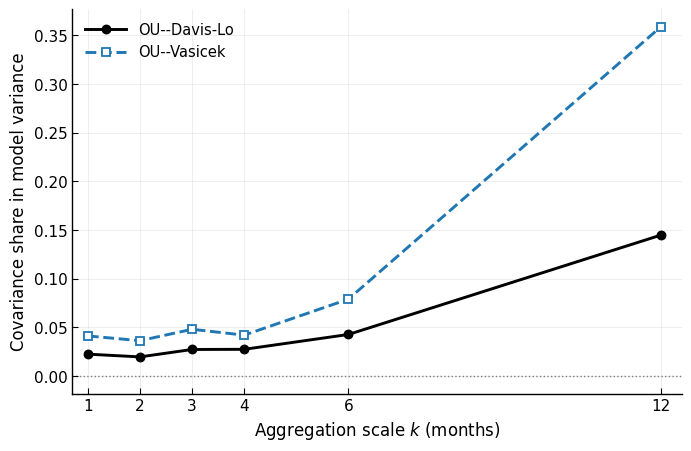

Saved: figures/fig5a_direct_fitting_covariance_share_k_month_ld_vasicek.png
Saved: figures/fig5a_direct_fitting_covariance_share_k_month_ld_vasicek.pdf


In [9]:
# ============================================================
# Fig. 5a:
# Direct-fitting covariance share
# k-month aggregation only
# OU--Lo--Davis and OU--Vasicek
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Save table for k-month direct-fitting results only
# ------------------------------------------------------------
df_compare_k = df_var_share_k.copy()
df_compare_k["scale"] = "k-month"
df_compare_k["source"] = TARGET_SECTOR

common_cols = [
    "scale", "source", "k_month", "T", "model", "var_data_rate",
    "iid_share_model_median",
    "contagion_share_model_median",
    "pt_share_model_median",
    "share_sum_median",
]

df_variance_decomp_k_comparison = df_compare_k[common_cols].copy()

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

# ------------------------------------------------------------
# Plot setting
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,   # changed
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

model_styles = {
    "ld": {
        "label": "OU--Davis-Lo",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
    },
    "vasicek": {
        "label": "OU--Vasicek",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(6.8, 4.4),
    constrained_layout=True,
)

for model_name in ["ld", "vasicek"]:

    st = model_styles[model_name]

    gk = (
        df_var_share_k[df_var_share_k["model"] == model_name]
        .sort_values("k_month")
        .copy()
    )

    if len(gk) == 0:
        continue
    
    ax.plot(
        gk["k_month"],
        gk["contagion_share_model_median"],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        label=st["label"],
        zorder=3,
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Covariance share in model variance")

ax.set_xticks([1, 2, 3, 4, 6, 12])
ax.set_xlim(0.7, 12.4)

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
    color="0.45",
    zorder=0,
)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=10.5,
    handlelength=2.8,
)


# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
fig_path_png = FIG_DIR / "fig5a_direct_fitting_covariance_share_k_month_ld_vasicek.png"
fig_path_pdf = FIG_DIR / "fig5a_direct_fitting_covariance_share_k_month_ld_vasicek.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)

## B. Direct Fitting: WAIC comparison

In [10]:
# ============================================================
# Direct Fitting: WAIC by individual aggregation scale
#
# Models: OU-Binomial, OU-Davis--Lo, OU-Vasicek only.
# Tail/PPC diagnostics are intentionally omitted.
# ============================================================

from scipy.special import logsumexp

OUT_DIR = PDATA_DIR
FIG_DIR = Path("./figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

WAIC_MAX_SAMPLES = 4000
rng_waic = np.random.default_rng(SEED + 20260520)


def _flatten_time_var(idata, var_name):
    arr = np.asarray(idata.posterior[var_name].values)
    if arr.ndim != 3:
        raise ValueError(f"{var_name}: expected ndim=3, got shape={arr.shape}")
    c, d, t = arr.shape
    return arr.reshape(c * d, t)


def _flatten_scalar_var(idata, var_name):
    arr = np.asarray(idata.posterior[var_name].values)
    if arr.ndim != 2:
        raise ValueError(f"{var_name}: expected ndim=2, got shape={arr.shape}")
    c, d = arr.shape
    return arr.reshape(c * d)


def _select_samples(*arrays, max_samples=None, rng=None):
    s = arrays[0].shape[0]
    if max_samples is None or s <= max_samples:
        return arrays
    if rng is None:
        rng = np.random.default_rng(SEED)
    idx = rng.choice(s, size=max_samples, replace=False)
    idx.sort()
    return tuple(a[idx] for a in arrays)


def _safe_logcomb_scalar(n, h):
    return gammaln(n + 1.0) - gammaln(h + 1.0) - gammaln(n - h + 1.0)


def _binomial_pointwise_loglik(n_obs, L_obs, p_s_t):
    eps = 1e-12
    p = np.clip(p_s_t, eps, 1.0 - eps)
    n = np.asarray(n_obs, dtype=float)[None, :]
    h = np.asarray(L_obs, dtype=float)[None, :]
    logC = gammaln(n + 1.0) - gammaln(h + 1.0) - gammaln(n - h + 1.0)
    return logC + h * np.log(p) + (n - h) * np.log1p(-p)


def _ld_pointwise_loglik(n_obs, L_obs, p_s_t, q_s):
    eps = 1e-12
    n_obs = np.asarray(n_obs, dtype=int)
    L_obs = np.asarray(L_obs, dtype=int)
    p_s_t = np.clip(np.asarray(p_s_t, dtype=float), eps, 1.0 - eps)
    q_s = np.clip(np.asarray(q_s, dtype=float), eps, 1.0 - eps)

    S, T = p_s_t.shape
    out = np.full((S, T), -np.inf, dtype=float)
    log_q1_s = np.log1p(-q_s)

    for t in range(T):
        n = int(n_obs[t])
        h = int(L_obs[t])
        p_s = p_s_t[:, t]
        logp_s = np.log(p_s)
        log1mp_s = np.log1p(-p_s)
        terms = []

        for k_seed in range(h + 1):
            if k_seed > n:
                continue
            rem_h = h - k_seed
            rem_n = n - k_seed
            if rem_h < 0 or rem_h > rem_n:
                continue

            log_PK = (
                _safe_logcomb_scalar(n, k_seed)
                + k_seed * logp_s
                + (n - k_seed) * log1mp_s
            )

            if k_seed == 0:
                log_cond = np.zeros(S) if rem_h == 0 else np.full(S, -np.inf)
            else:
                log_1mr = k_seed * log_q1_s
                r = np.clip(1.0 - np.exp(log_1mr), eps, 1.0 - eps)
                log_cond = (
                    _safe_logcomb_scalar(rem_n, rem_h)
                    + rem_h * np.log(r)
                    + (rem_n - rem_h) * np.log1p(-r)
                )
            terms.append(log_PK + log_cond)

        out[:, t] = logsumexp(np.vstack(terms), axis=0) if terms else -np.inf

    return out


def _vasicek_pointwise_loglik(n_obs, L_obs, a_s_t, rho_s, GH_N=60):
    eps = 1e-12
    n_obs = np.asarray(n_obs, dtype=float)
    L_obs = np.asarray(L_obs, dtype=float)
    a_s_t = np.asarray(a_s_t, dtype=float)
    rho_s = np.clip(np.asarray(rho_s, dtype=float), 1e-8, 1.0 - 1e-8)

    S, T = a_s_t.shape
    out = np.full((S, T), -np.inf, dtype=float)

    gh_x, gh_w = hermgauss(GH_N)
    y = np.sqrt(2.0) * gh_x
    log_w = np.log(gh_w) - 0.5 * np.log(np.pi)

    sqrt_rho = np.sqrt(rho_s)
    sqrt_1mrho = np.sqrt(1.0 - rho_s)

    for t in range(T):
        n = n_obs[t]
        h = L_obs[t]
        z = (a_s_t[:, t][:, None] - sqrt_rho[:, None] * y[None, :]) / sqrt_1mrho[:, None]
        p_cond = np.clip(norm.cdf(z), eps, 1.0 - eps)
        logC = _safe_logcomb_scalar(n, h)
        log_bin = logC + h * np.log(p_cond) + (n - h) * np.log1p(-p_cond)
        out[:, t] = logsumexp(log_w[None, :] + log_bin, axis=1)

    return out


def compute_pointwise_loglik_from_idata(idata, model_name, k, n_obs, L_obs, max_samples=None, rng=None, GH_N=60):
    prefix = model_label_prefix(model_name, k)

    if model_name == "binomial":
        p_s_t = _flatten_time_var(idata, f"{prefix}_p")
        p_s_t, = _select_samples(p_s_t, max_samples=max_samples, rng=rng)
        return _binomial_pointwise_loglik(n_obs, L_obs, p_s_t)

    if model_name == "ld":
        p_s_t = _flatten_time_var(idata, f"{prefix}_p")
        q_s = _flatten_scalar_var(idata, f"{prefix}_q")
        p_s_t, q_s = _select_samples(p_s_t, q_s, max_samples=max_samples, rng=rng)
        return _ld_pointwise_loglik(n_obs, L_obs, p_s_t, q_s)

    if model_name == "vasicek":
        a_s_t = _flatten_time_var(idata, f"{prefix}_latent_z")
        rho_s = _flatten_scalar_var(idata, f"{prefix}_rho_A")
        a_s_t, rho_s = _select_samples(a_s_t, rho_s, max_samples=max_samples, rng=rng)
        return _vasicek_pointwise_loglik(n_obs, L_obs, a_s_t, rho_s, GH_N=GH_N)

    raise ValueError(model_name)


def waic_from_pointwise_loglik(log_lik_s_t):
    ll = np.asarray(log_lik_s_t, dtype=float)
    S, T = ll.shape
    lppd_t = logsumexp(ll, axis=0) - np.log(S)
    p_waic_t = np.var(ll, axis=0, ddof=1)
    elpd_waic_t = lppd_t - p_waic_t
    elpd_waic = float(np.sum(elpd_waic_t))
    p_waic = float(np.sum(p_waic_t))
    waic = float(-2.0 * elpd_waic)
    waic_i = -2.0 * elpd_waic_t
    waic_se = float(np.sqrt(T * np.var(waic_i, ddof=1))) if T >= 2 else np.nan
    lppd = float(np.sum(lppd_t))
    return {
        "n_post_samples_used": int(S),
        "T": int(T),
        "lppd": lppd,
        "p_waic": p_waic,
        "elpd_waic": elpd_waic,
        "waic": waic,
        "waic_se": waic_se,
    }


def add_waic_delta_against_binomial(df, group_cols):
    df = df.copy()
    for col in ["waic", "elpd_waic", "lppd"]:
        base = (
            df[df["model"] == "binomial"]
            .set_index(group_cols)[col]
            .rename(f"{col}_binomial")
        )
        df = df.join(base, on=group_cols)
    df["delta_waic_vs_binomial"] = df["waic"] - df["waic_binomial"]
    df["delta_elpd_waic_vs_binomial"] = df["elpd_waic"] - df["elpd_waic_binomial"]
    df["delta_lppd_vs_binomial"] = df["lppd"] - df["lppd_binomial"]
    return df


waic_rows = []

for k in K_LIST_BAYES:
    print("=" * 80)
    print(f"WAIC for k = {k}")
    print("=" * 80)

    d_k, n_obs_k, L_obs_k = prepare_bayes_data_for_k(df_target, k)

    for model_name in MODEL_LIST:
        print(f"  computing: k={k}, model={model_name}")
        idata = idata_by_k_model[(k, model_name)]
        ll = compute_pointwise_loglik_from_idata(
            idata=idata,
            model_name=model_name,
            k=k,
            n_obs=n_obs_k,
            L_obs=L_obs_k,
            max_samples=WAIC_MAX_SAMPLES,
            rng=rng_waic,
            GH_N=60,
        )
        row = {"k_month": k, "model": model_name}
        row.update(waic_from_pointwise_loglik(ll))
        waic_rows.append(row)


df_waic_k = pd.DataFrame(waic_rows)
df_waic_k = add_waic_delta_against_binomial(df_waic_k, group_cols=["k_month"])

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

df_delta_waic_k_wide = df_waic_k.pivot(
    index="k_month",
    columns="model",
    values="delta_waic_vs_binomial",
).reset_index()

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


WAIC for k = 1
  computing: k=1, model=binomial
  computing: k=1, model=ld
  computing: k=1, model=vasicek
WAIC for k = 2
  computing: k=2, model=binomial
  computing: k=2, model=ld
  computing: k=2, model=vasicek
WAIC for k = 3
  computing: k=3, model=binomial
  computing: k=3, model=ld
  computing: k=3, model=vasicek
WAIC for k = 4
  computing: k=4, model=binomial
  computing: k=4, model=ld
  computing: k=4, model=vasicek
WAIC for k = 6
  computing: k=6, model=binomial
  computing: k=6, model=ld
  computing: k=6, model=vasicek
WAIC for k = 12
  computing: k=12, model=binomial
  computing: k=12, model=ld
  computing: k=12, model=vasicek


In [11]:
# ============================================================
# Direct fitting:
# Approximate standard errors for per-block ELPD differences
#
# This cell must be run after df_waic_k has been created.
#
# Uses:
#   elpd_waic = - waic / 2
#   elpd_waic_se = waic_se / 2
#
# For model differences, we use a conservative approximation
# that ignores covariance between model-wise elpd estimates:
#
#   se(delta elpd) = sqrt(se_model^2 + se_baseline^2)
#
# Baseline:
#   Direct OU-Binomial at the same aggregation scale k.
# ============================================================

import numpy as np
import pandas as pd

df_waic_k_with_se = df_waic_k.copy()

# ------------------------------------------------------------
# Ensure ELPD and ELPD SE columns exist
# ------------------------------------------------------------

if "elpd_waic" not in df_waic_k_with_se.columns:
    df_waic_k_with_se["elpd_waic"] = -0.5 * df_waic_k_with_se["waic"]

df_waic_k_with_se["elpd_waic_se"] = 0.5 * df_waic_k_with_se["waic_se"]

# ------------------------------------------------------------
# Merge direct OU-Binomial baseline at each k
# ------------------------------------------------------------

df_direct_binomial_base = (
    df_waic_k_with_se[df_waic_k_with_se["model"] == "binomial"]
    [["k_month", "elpd_waic", "elpd_waic_se"]]
    .rename(columns={
        "elpd_waic": "elpd_waic_direct_binomial",
        "elpd_waic_se": "elpd_waic_se_direct_binomial",
    })
)

df_waic_k_with_se = df_waic_k_with_se.merge(
    df_direct_binomial_base,
    on="k_month",
    how="left",
)

# ------------------------------------------------------------
# Delta ELPD and approximate SE
# ------------------------------------------------------------

df_waic_k_with_se["delta_elpd_vs_direct_binomial"] = (
    df_waic_k_with_se["elpd_waic"]
    - df_waic_k_with_se["elpd_waic_direct_binomial"]
)

df_waic_k_with_se["delta_elpd_vs_direct_binomial_se"] = np.sqrt(
    df_waic_k_with_se["elpd_waic_se"]**2
    + df_waic_k_with_se["elpd_waic_se_direct_binomial"]**2
)

df_waic_k_with_se["delta_elpd_per_block_vs_direct_binomial"] = (
    df_waic_k_with_se["delta_elpd_vs_direct_binomial"]
    / df_waic_k_with_se["T"]
)

df_waic_k_with_se["delta_elpd_per_block_vs_direct_binomial_se"] = (
    df_waic_k_with_se["delta_elpd_vs_direct_binomial_se"]
    / df_waic_k_with_se["T"]
)

# Baseline itself is exactly zero.
mask_base = df_waic_k_with_se["model"] == "binomial"

df_waic_k_with_se.loc[
    mask_base,
    "delta_elpd_vs_direct_binomial",
] = 0.0

df_waic_k_with_se.loc[
    mask_base,
    "delta_elpd_per_block_vs_direct_binomial",
] = 0.0

# For plotting the baseline, we usually do not need an error bar.
df_waic_k_with_se.loc[
    mask_base,
    "delta_elpd_per_block_vs_direct_binomial_se",
] = 0.0

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

print("Saved:")
pass  # Suppressed verbose file-output message.


Saved:


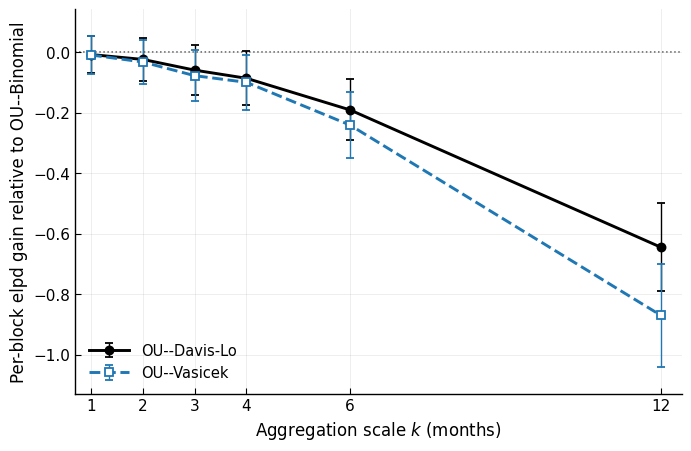

Saved: figures/fig5b_direct_fitting_per_block_elpd_gain_vs_ou_binomial_by_k.png
Saved: figures/fig5b_direct_fitting_per_block_elpd_gain_vs_ou_binomial_by_k.pdf


In [12]:
# ============================================================
# Fig. 5b:
# Per-block elpd gain relative to OU--Binomial
# Direct-fitted models by aggregation scale
#
# Error bars:
#   approximate standard errors of the WAIC-based per-block ELPD
#   difference, computed from waic_se and ignoring model-wise
#   covariance.
#
# Output file names are unchanged.
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
# Prefer the SE-augmented table if it has already been created.
# Otherwise, fall back to df_waic_k and construct the required columns here.
if "df_waic_k_with_se" in globals():
    df_plot = df_waic_k_with_se.copy()
else:
    df_plot = df_waic_k.copy()

# Use only non-binomial models
MODEL_LIST_FIG5B = ["ld", "vasicek"]

# ------------------------------------------------------------
# Ensure block counts
# ------------------------------------------------------------
if "T" not in df_plot.columns:
    # Fallback: infer number of non-overlapping blocks from k.
    block_count_by_k = {
        int(k): len(block_data_by_k[int(k)])
        for k in K_LIST_COARSE
    }
    block_count_by_k[1] = len(df_m1)
    df_plot["T"] = df_plot["k_month"].map(block_count_by_k)

# ------------------------------------------------------------
# Ensure ELPD and approximate SE columns
# ------------------------------------------------------------
# WAIC = -2 * elpd
# elpd_se = waic_se / 2
# ------------------------------------------------------------
if "elpd_waic" not in df_plot.columns:
    df_plot["elpd_waic"] = -0.5 * df_plot["waic"]

if "elpd_waic_se" not in df_plot.columns:
    if "waic_se" in df_plot.columns:
        df_plot["elpd_waic_se"] = 0.5 * df_plot["waic_se"]
    else:
        df_plot["elpd_waic_se"] = np.nan

# ------------------------------------------------------------
# Direct OU--Binomial baseline at each k
# ------------------------------------------------------------
if "elpd_waic_direct_binomial" not in df_plot.columns:

    df_direct_binomial_base = (
        df_plot[df_plot["model"] == "binomial"]
        [["k_month", "elpd_waic", "elpd_waic_se"]]
        .rename(columns={
            "elpd_waic": "elpd_waic_direct_binomial",
            "elpd_waic_se": "elpd_waic_se_direct_binomial",
        })
    )

    df_plot = df_plot.merge(
        df_direct_binomial_base,
        on="k_month",
        how="left",
    )

# ------------------------------------------------------------
# Compute per-block ELPD gain and approximate SE
# ------------------------------------------------------------
# If old columns exist, keep them consistent with the new naming.
# ------------------------------------------------------------

if "delta_elpd_vs_direct_binomial" not in df_plot.columns:
    df_plot["delta_elpd_vs_direct_binomial"] = (
        df_plot["elpd_waic"] - df_plot["elpd_waic_direct_binomial"]
    )

if "delta_elpd_vs_direct_binomial_se" not in df_plot.columns:
    df_plot["delta_elpd_vs_direct_binomial_se"] = np.sqrt(
        df_plot["elpd_waic_se"]**2
        + df_plot["elpd_waic_se_direct_binomial"]**2
    )

if "delta_elpd_per_block_vs_direct_binomial" not in df_plot.columns:
    df_plot["delta_elpd_per_block_vs_direct_binomial"] = (
        df_plot["delta_elpd_vs_direct_binomial"] / df_plot["T"]
    )

if "delta_elpd_per_block_vs_direct_binomial_se" not in df_plot.columns:
    df_plot["delta_elpd_per_block_vs_direct_binomial_se"] = (
        df_plot["delta_elpd_vs_direct_binomial_se"] / df_plot["T"]
    )

# Backward-compatible column names used in the original cell
df_plot["delta_elpd_vs_binomial"] = df_plot["delta_elpd_vs_direct_binomial"]
df_plot["delta_elpd_per_block_vs_binomial"] = (
    df_plot["delta_elpd_per_block_vs_direct_binomial"]
)
df_plot["delta_elpd_per_block_vs_binomial_se"] = (
    df_plot["delta_elpd_per_block_vs_direct_binomial_se"]
)

# Baseline itself is exactly zero.
mask_base = df_plot["model"] == "binomial"
df_plot.loc[mask_base, "delta_elpd_vs_binomial"] = 0.0
df_plot.loc[mask_base, "delta_elpd_per_block_vs_binomial"] = 0.0
df_plot.loc[mask_base, "delta_elpd_per_block_vs_binomial_se"] = 0.0

# ------------------------------------------------------------
# Save table
# ------------------------------------------------------------
cols_save = [
    "k_month",
    "T",
    "model",
    "waic",
    "waic_se",
    "elpd_waic",
    "elpd_waic_se",
    "delta_waic_vs_binomial",
    "delta_elpd_vs_binomial",
    "delta_elpd_per_block_vs_binomial",
    "delta_elpd_per_block_vs_binomial_se",
]
cols_save = [c for c in cols_save if c in df_plot.columns]

df_fig5b_direct_elpd = (
    df_plot[df_plot["model"].isin(MODEL_LIST_FIG5B)]
    .sort_values(["model", "k_month"])
    .copy()
)

pass  # Display suppressed in public minimal version.
# Output file name unchanged
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

# ------------------------------------------------------------
# Plot setting
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

model_styles = {
    "ld": {
        "label": "OU--Davis-Lo",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
    },
    "torri": {
        "label": "OU--Torri",
        "color": "0.45",
        "linestyle": "-.",
        "marker": "^",
        "markerfacecolor": "white",
    },
    "vasicek": {
        "label": "OU--Vasicek",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(6.8, 4.4),
    constrained_layout=True,
)

for model_name in MODEL_LIST_FIG5B:

    g = (
        df_plot[df_plot["model"] == model_name]
        .sort_values("k_month")
        .copy()
    )

    if len(g) == 0:
        continue

    st = model_styles[model_name]

    ax.errorbar(
        g["k_month"],
        g["delta_elpd_per_block_vs_binomial"],
        yerr=g["delta_elpd_per_block_vs_binomial_se"],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        ecolor=st["color"],
        elinewidth=1.0,
        capsize=3.0,
        capthick=1.0,
        label=st["label"],
        zorder=3,
    )

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.1,
    color="0.35",
    zorder=0,
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Per-block elpd gain relative to OU--Binomial")

ax.set_xticks([1, 2, 3, 4, 6, 12])
ax.set_xlim(0.7, 12.4)

# Positive means better than OU--Binomial
y_vals = df_plot.loc[
    df_plot["model"].isin(MODEL_LIST_FIG5B),
    "delta_elpd_per_block_vs_binomial",
].dropna()

y_err_vals = df_plot.loc[
    df_plot["model"].isin(MODEL_LIST_FIG5B),
    "delta_elpd_per_block_vs_binomial_se",
].dropna()

if len(y_vals) > 0:
    y_min_raw = float(y_vals.min())
    y_max_raw = float(y_vals.max())

    if len(y_err_vals) > 0:
        y_min_raw = min(
            y_min_raw,
            float(
                (
                    df_plot.loc[
                        df_plot["model"].isin(MODEL_LIST_FIG5B),
                        "delta_elpd_per_block_vs_binomial",
                    ]
                    - df_plot.loc[
                        df_plot["model"].isin(MODEL_LIST_FIG5B),
                        "delta_elpd_per_block_vs_binomial_se",
                    ]
                ).min()
            ),
        )
        y_max_raw = max(
            y_max_raw,
            float(
                (
                    df_plot.loc[
                        df_plot["model"].isin(MODEL_LIST_FIG5B),
                        "delta_elpd_per_block_vs_binomial",
                    ]
                    + df_plot.loc[
                        df_plot["model"].isin(MODEL_LIST_FIG5B),
                        "delta_elpd_per_block_vs_binomial_se",
                    ]
                ).max()
            ),
        )

    y_min = min(0.0, y_min_raw)
    y_max = max(0.0, y_max_raw)
    pad = 0.08 * (y_max - y_min) if y_max > y_min else 0.05
    ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="best",
    handlelength=2.8,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
# Output file names unchanged
fig_path_png = FIG_DIR / "fig5b_direct_fitting_per_block_elpd_gain_vs_ou_binomial_by_k.png"
fig_path_pdf = FIG_DIR / "fig5b_direct_fitting_per_block_elpd_gain_vs_ou_binomial_by_k.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)


In [13]:
# ============================================================
# Direct Fitting: estimation-result summary tables
#
# Summarizes:
#   1. posterior parameter estimates
#   2. variance decomposition
#   3. WAIC / elpd comparison against OU-Binomial
#
# Required objects:
#   summary_by_k_model
#   df_var_share_k
#   df_waic_k
#   OUT_DIR
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# Model labels
# ------------------------------------------------------------
MODEL_LABELS_DIRECT = {
    "binomial": "OU--Binomial",
    "ld": "OU--Davis-Lo",
    "vasicek": "OU--Vasicek",
    "torri": "OU--Torri",
}

MODEL_ORDER_DIRECT = ["binomial", "ld", "vasicek", "torri"]

PARAM_ORDER_DIRECT = [
    "mu",
    "phi",
    "kappa_per_month",
    "half_life_months",
    "sigma_eta",
    "sigma_x",
    "q",
    "rho_A",
    "u",
    "v",
]

# ------------------------------------------------------------
# Helper: robust column getter for ArviZ summary
# ------------------------------------------------------------
def _first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _strip_prefix_from_param(var_name, k_month, model_name):
    """
    Convert names such as
        ld_k1_q, vasicek_k12_rho_A
    into
        q, rho_A
    """
    candidates = []

    # Use existing function if defined in the notebook
    if "model_label_prefix" in globals():
        try:
            candidates.append(model_label_prefix(model_name, k_month))
        except Exception:
            pass

    # fallback candidates
    candidates += [
        f"{model_name}_k{k_month}",
        f"{model_name}{k_month}",
        f"k{k_month}_{model_name}",
        model_name,
    ]

    out = str(var_name)

    for pref in candidates:
        pref = str(pref)
        if out.startswith(pref + "_"):
            out = out[len(pref) + 1:]
            break

    return out


# ============================================================
# 1. Parameter posterior summaries
# ============================================================

param_rows = []

for key, summ in summary_by_k_model.items():

    if summ is None or len(summ) == 0:
        continue

    k_month, model_name = key

    mean_col = _first_existing_col(summ, ["mean"])
    sd_col = _first_existing_col(summ, ["sd"])
    hdi_low_col = _first_existing_col(
        summ,
        ["hdi_2.5%", "hdi_3%", "hdi_5%", "hdi_0.5%"]
    )
    hdi_high_col = _first_existing_col(
        summ,
        ["hdi_97.5%", "hdi_97%", "hdi_95%", "hdi_99.5%"]
    )
    ess_col = _first_existing_col(summ, ["ess_bulk"])
    rhat_col = _first_existing_col(summ, ["r_hat"])

    for var_name, row in summ.iterrows():

        param = _strip_prefix_from_param(
            var_name=var_name,
            k_month=k_month,
            model_name=model_name,
        )

        param_rows.append({
            "k_month": int(k_month),
            "model": model_name,
            "model_label": MODEL_LABELS_DIRECT.get(model_name, model_name),
            "parameter": param,
            "raw_parameter": var_name,
            "mean": float(row[mean_col]) if mean_col is not None else np.nan,
            "sd": float(row[sd_col]) if sd_col is not None else np.nan,
            "hdi_low": float(row[hdi_low_col]) if hdi_low_col is not None else np.nan,
            "hdi_high": float(row[hdi_high_col]) if hdi_high_col is not None else np.nan,
            "ess_bulk": float(row[ess_col]) if ess_col is not None else np.nan,
            "r_hat": float(row[rhat_col]) if rhat_col is not None else np.nan,
        })

df_direct_param_long = pd.DataFrame(param_rows)

if len(df_direct_param_long) > 0:

    df_direct_param_long["model_order"] = df_direct_param_long["model"].map(
        {m: i for i, m in enumerate(MODEL_ORDER_DIRECT)}
    )

    df_direct_param_long["param_order"] = df_direct_param_long["parameter"].map(
        {p: i for i, p in enumerate(PARAM_ORDER_DIRECT)}
    )

    df_direct_param_long = (
        df_direct_param_long
        .sort_values(["k_month", "model_order", "param_order", "parameter"])
        .drop(columns=["model_order", "param_order"])
        .reset_index(drop=True)
    )

display(df_direct_param_long)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 2. Compact parameter table
# ============================================================

def _fmt_estimate(mean, low, high, digits=4):
    if pd.isna(mean):
        return ""
    if pd.isna(low) or pd.isna(high):
        return f"{mean:.{digits}g}"
    return f"{mean:.{digits}g} [{low:.{digits}g}, {high:.{digits}g}]"


if len(df_direct_param_long) > 0:

    df_param_fmt = df_direct_param_long.copy()

    df_param_fmt["estimate"] = df_param_fmt.apply(
        lambda r: _fmt_estimate(
            r["mean"],
            r["hdi_low"],
            r["hdi_high"],
            digits=4,
        ),
        axis=1,
    )

    df_direct_param_compact = (
        df_param_fmt
        .pivot_table(
            index=["k_month", "model", "model_label"],
            columns="parameter",
            values="estimate",
            aggfunc="first",
        )
        .reset_index()
    )

    param_cols_existing = [
        p for p in PARAM_ORDER_DIRECT
        if p in df_direct_param_compact.columns
    ]

    df_direct_param_compact = df_direct_param_compact[
        ["k_month", "model", "model_label"] + param_cols_existing
    ]

    df_direct_param_compact["model_order"] = df_direct_param_compact["model"].map(
        {m: i for i, m in enumerate(MODEL_ORDER_DIRECT)}
    )

    df_direct_param_compact = (
        df_direct_param_compact
        .sort_values(["k_month", "model_order"])
        .drop(columns=["model_order"])
        .reset_index(drop=True)
    )

    display(df_direct_param_compact)

    pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 3. Variance-decomposition summary
# ============================================================

cols_vardecomp = [
    "k_month",
    "T",
    "model",
    "var_data_rate",
    "iid_over_data_median",
    "contagion_over_data_median",
    "pt_over_data_median",
    "total_over_data_median",
    "iid_share_model_median",
    "contagion_share_model_median",
    "pt_share_model_median",
    "share_sum_median",
]

cols_vardecomp = [c for c in cols_vardecomp if c in df_var_share_k.columns]

df_direct_vardecomp_summary = df_var_share_k[cols_vardecomp].copy()

df_direct_vardecomp_summary["model_label"] = df_direct_vardecomp_summary["model"].map(
    MODEL_LABELS_DIRECT
).fillna(df_direct_vardecomp_summary["model"])

df_direct_vardecomp_summary["model_order"] = df_direct_vardecomp_summary["model"].map(
    {m: i for i, m in enumerate(MODEL_ORDER_DIRECT)}
)

df_direct_vardecomp_summary = (
    df_direct_vardecomp_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_direct_vardecomp_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 4. WAIC / elpd summary
# ============================================================

cols_waic = [
    "k_month",
    "model",
    "T",
    "waic",
    "waic_se",
    "p_waic",
    "elpd_waic",
    "lppd",
    "delta_waic_vs_binomial",
    "delta_elpd_waic_vs_binomial",
]

cols_waic = [c for c in cols_waic if c in df_waic_k.columns]

df_direct_waic_summary = df_waic_k[cols_waic].copy()

df_direct_waic_summary["model_label"] = df_direct_waic_summary["model"].map(
    MODEL_LABELS_DIRECT
).fillna(df_direct_waic_summary["model"])

if "delta_elpd_waic_vs_binomial" in df_direct_waic_summary.columns:
    df_direct_waic_summary["delta_elpd_per_block_vs_binomial"] = (
        df_direct_waic_summary["delta_elpd_waic_vs_binomial"]
        / df_direct_waic_summary["T"]
    )

if "delta_waic_vs_binomial" in df_direct_waic_summary.columns:
    df_direct_waic_summary["delta_waic_per_block_vs_binomial"] = (
        df_direct_waic_summary["delta_waic_vs_binomial"]
        / df_direct_waic_summary["T"]
    )

df_direct_waic_summary["model_order"] = df_direct_waic_summary["model"].map(
    {m: i for i, m in enumerate(MODEL_ORDER_DIRECT)}
)

df_direct_waic_summary = (
    df_direct_waic_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_direct_waic_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 5. Integrated Direct Fitting summary
# ============================================================

# Parameter estimates in wide numerical format
if len(df_direct_param_long) > 0:

    df_param_mean_wide = (
        df_direct_param_long
        .pivot_table(
            index=["k_month", "model"],
            columns="parameter",
            values="mean",
            aggfunc="first",
        )
        .reset_index()
    )

else:
    df_param_mean_wide = pd.DataFrame(columns=["k_month", "model"])


# Variance + WAIC
merge_keys = ["k_month", "model"]

df_direct_integrated_summary = df_direct_vardecomp_summary.copy()

waic_cols_for_merge = [
    "k_month",
    "model",
    "waic",
    "waic_se",
    "p_waic",
    "elpd_waic",
    "delta_waic_vs_binomial",
    "delta_elpd_waic_vs_binomial",
    "delta_elpd_per_block_vs_binomial",
]

waic_cols_for_merge = [
    c for c in waic_cols_for_merge
    if c in df_direct_waic_summary.columns
]

df_direct_integrated_summary = df_direct_integrated_summary.merge(
    df_direct_waic_summary[waic_cols_for_merge],
    on=merge_keys,
    how="left",
)

df_direct_integrated_summary = df_direct_integrated_summary.merge(
    df_param_mean_wide,
    on=merge_keys,
    how="left",
)

# Reorder columns
front_cols = [
    "k_month",
    "T",
    "model",
    "model_label",
    "mu",
    "phi",
    "kappa_per_month",
    "half_life_months",
    "sigma_eta",
    "sigma_x",
    "q",
    "rho_A",
    "waic",
    "delta_waic_vs_binomial",
    "delta_elpd_per_block_vs_binomial",
    "var_data_rate",
    "iid_share_model_median",
    "contagion_share_model_median",
    "pt_share_model_median",
    "total_over_data_median",
]

front_cols = [
    c for c in front_cols
    if c in df_direct_integrated_summary.columns
]

remaining_cols = [
    c for c in df_direct_integrated_summary.columns
    if c not in front_cols
]

df_direct_integrated_summary = df_direct_integrated_summary[
    front_cols + remaining_cols
]

df_direct_integrated_summary["model_order"] = df_direct_integrated_summary["model"].map(
    {m: i for i, m in enumerate(MODEL_ORDER_DIRECT)}
)

df_direct_integrated_summary = (
    df_direct_integrated_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_direct_integrated_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 6. Paper-facing compact table for OU--Davis-Lo and OU--Vasicek
# ============================================================

PAPER_MODELS_DIRECT = ["ld", "vasicek"]

paper_cols = [
    "k_month",
    "model_label",
    "q",
    "rho_A",
    "contagion_share_model_median",
    "delta_waic_vs_binomial",
    "delta_elpd_per_block_vs_binomial",
    "total_over_data_median",
]

paper_cols = [
    c for c in paper_cols
    if c in df_direct_integrated_summary.columns
]

df_direct_paper_table = (
    df_direct_integrated_summary[
        df_direct_integrated_summary["model"].isin(PAPER_MODELS_DIRECT)
    ][paper_cols]
    .copy()
)

# Rename for readability
rename_paper_cols = {
    "k_month": "k",
    "model_label": "model",
    "q": "q",
    "rho_A": "rho_A",
    "contagion_share_model_median": "covariance_share",
    "delta_waic_vs_binomial": "Delta_WAIC_vs_OU_Binomial",
    "delta_elpd_per_block_vs_binomial": "Delta_elpd_per_block",
    "total_over_data_median": "model_variance_over_data",
}

df_direct_paper_table = df_direct_paper_table.rename(columns=rename_paper_cols)







display(df_direct_paper_table)

df_direct_paper_table.to_csv(
    OUT_DIR / "direct_fitting_paper_table.csv",
    index=False,
)


# ============================================================
# Safe Markdown writer without tabulate
# ============================================================

def dataframe_to_markdown_no_tabulate(df, float_digits=6):
    """
    pandas.to_markdown() を使わずに Markdown table を生成する。
    tabulate 未インストール環境用。
    """

    def fmt(x):
        if pd.isna(x):
            return ""
        if isinstance(x, float):
            return f"{x:.{float_digits}g}"
        return str(x)

    cols = list(df.columns)

    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join(["---"] * len(cols)) + " |"

    rows = []
    for _, r in df.iterrows():
        rows.append(
            "| " + " | ".join(fmt(r[c]) for c in cols) + " |"
        )

    return "\n".join([header, sep] + rows)

def dataframe_to_markdown_no_tabulate(df, float_digits=6):
    def fmt(x):
        if pd.isna(x):
            return ""
        if isinstance(x, float):
            return f"{x:.{float_digits}g}"
        return str(x)

    cols = list(df.columns)

    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join(["---"] * len(cols)) + " |"

    rows = []
    for _, r in df.iterrows():
        rows.append("| " + " | ".join(fmt(r[c]) for c in cols) + " |")

    return "\n".join([header, sep] + rows)


pass  # Markdown/TeX output suppressed for public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

pass  # Suppressed verbose file-output message.
print("Main table:")
print(" - direct_fitting_integrated_summary.csv")
print(" - direct_fitting_paper_table.csv")
print(" - direct_fitting_paper_table.md")
print(" - direct_fitting_paper_table.tex")


,k_month,model,model_label,parameter,raw_parameter,mean,sd,hdi_low,hdi_high,ess_bulk,r_hat
0,1,binomial,OU--Binomial,mu,binom_k1_mu,-3.088121,0.094718,-3.346094,-2.932569,38.295761,1.108480
1,1,binomial,OU--Binomial,phi,binom_k1_phi,0.946133,0.019424,0.907378,0.984413,110.618468,1.044248
2,1,binomial,OU--Binomial,kappa_per_month,binom_k1_kappa_per_month,0.055583,0.020566,0.015709,0.097196,110.618468,1.044248
3,1,binomial,OU--Binomial,half_life_months,binom_k1_half_life_months,15.564590,14.993699,5.536236,32.808433,110.618468,1.044248
4,1,binomial,OU--Binomial,sigma_eta,binom_k1_sigma_eta,0.073265,0.007101,0.059572,0.087040,740.780646,1.002056
...,...,...,...,...,...,...,...,...,...,...,...
115,12,vasicek,OU--Vasicek,kappa_per_month,vas_k12_kappa_per_month,0.084000,0.056068,0.001518,0.192507,340.665760,1.001286
116,12,vasicek,OU--Vasicek,half_life_months,vas_k12_half_life_months,15.842881,26.706902,2.032362,43.484388,340.665760,1.001225
117,12,vasicek,OU--Vasicek,sigma_eta,vas_k12_sigma_eta,0.163251,0.054747,0.026919,0.248692,223.837939,1.027068
118,12,vasicek,OU--Vasicek,sigma_x,vas_k12_sigma_x,0.496872,0.272785,0.041015,1.000685,180.358850,1.022335


parameter,k_month,model,model_label,mu,phi,kappa_per_month,half_life_months,sigma_eta,sigma_x,q,rho_A
0,1,binomial,OU--Binomial,"-3.088 [-3.346, -2.933]","0.9461 [0.9074, 0.9844]","0.05558 [0.01571, 0.0972]","15.56 [5.536, 32.81]","0.07327 [0.05957, 0.08704]","0.2404 [0.1627, 0.3542]",NaN,NaN
1,1,ld,OU--Davis-Lo,"-3.136 [-3.364, -2.965]","0.9502 [0.9153, 0.9864]","0.05124 [0.01344, 0.08825]","16.48 [5.676, 33.39]","0.06959 [0.05608, 0.08398]","0.2361 [0.1584, 0.3364]","1.339e-05 [6.5e-07, 2.841e-05]",NaN
2,1,vasicek,OU--Vasicek,"-3.113 [-3.299, -2.947]","0.9521 [0.9184, 0.9851]","0.04929 [0.01425, 0.0844]","16.81 [6.002, 32.48]","0.06812 [0.05429, 0.08172]","0.2341 [0.1607, 0.3246]",NaN,"0.002472 [0.0002553, 0.005102]"
3,2,binomial,OU--Binomial,"-2.914 [-3.107, -2.76]","0.9234 [0.8673, 0.9755]","0.08012 [0.02371, 0.1412]","10.59 [3.668, 20.99]","0.09473 [0.07771, 0.1116]","0.2619 [0.1719, 0.382]",NaN,NaN
4,2,ld,OU--Davis-Lo,"-2.925 [-3.116, -2.746]","0.9248 [0.8715, 0.9758]","0.07863 [0.02235, 0.1351]","10.55 [3.978, 20.6]","0.09155 [0.07442, 0.1097]","0.2535 [0.1689, 0.3604]","2.055e-05 [6.2e-07, 4.755e-05]",NaN
5,2,vasicek,OU--Vasicek,"-2.902 [-3.1, -2.727]","0.9282 [0.8746, 0.9771]","0.0749 [0.0188, 0.1294]","11.31 [4.167, 22.59]","0.09049 [0.07394, 0.1092]","0.2578 [0.1684, 0.3728]",NaN,"0.002113 [3.609e-05, 0.004532]"
6,3,binomial,OU--Binomial,"-2.779 [-3.021, -2.593]","0.9072 [0.8362, 0.9746]","0.09826 [0.02569, 0.1789]","8.779 [2.924, 18.28]","0.1171 [0.09594, 0.1375]","0.2971 [0.1938, 0.4397]",NaN,NaN
7,3,ld,OU--Davis-Lo,"-2.855 [-3.203, -2.612]","0.9135 [0.8453, 0.9866]","0.09134 [0.0135, 0.1681]","11.02 [2.927, 24.72]","0.1105 [0.08747, 0.1318]","0.3007 [0.1779, 0.482]","4.046e-05 [4.6e-07, 9.296e-05]",NaN
8,3,vasicek,OU--Vasicek,"-2.761 [-2.969, -2.509]","0.914 [0.8455, 0.9783]","0.09071 [0.02191, 0.1679]","9.767 [3.275, 20.99]","0.1099 [0.08814, 0.1325]","0.2912 [0.1768, 0.4389]",NaN,"0.002812 [0.0001533, 0.006083]"
9,4,binomial,OU--Binomial,"-2.683 [-2.972, -2.337]","0.9086 [0.8308, 0.9818]","0.09687 [0.01807, 0.1851]","9.855 [2.508, 22.35]","0.1261 [0.1043, 0.1491]","0.3315 [0.1959, 0.5342]",NaN,NaN


,k_month,T,model,var_data_rate,iid_over_data_median,contagion_over_data_median,pt_over_data_median,total_over_data_median,iid_share_model_median,contagion_share_model_median,pt_share_model_median,share_sum_median,model_label
0,1,489,binomial,0.000001,0.278129,0.000000,0.670801,0.949380,0.293158,0.000000,0.706842,1.000000,OU--Binomial
1,1,489,ld,0.000001,0.277324,0.021600,0.655036,0.956138,0.290020,0.022552,0.685805,0.998376,OU--Davis-Lo
2,1,489,vasicek,0.000001,0.277621,0.039475,0.643462,0.962751,0.288506,0.041250,0.668545,0.998301,OU--Vasicek
3,2,244,binomial,0.000004,0.178467,0.000000,0.809499,0.988199,0.180549,0.000000,0.819451,1.000000,OU--Binomial
4,2,244,ld,0.000004,0.178466,0.019623,0.792793,0.993316,0.179573,0.019748,0.799220,0.998541,OU--Davis-Lo
5,2,244,vasicek,0.000004,0.178660,0.036215,0.777113,0.994870,0.179470,0.036400,0.782945,0.998815,OU--Vasicek
6,3,163,binomial,0.000009,0.129371,0.000000,0.872185,1.001408,0.129142,0.000000,0.870858,1.000000,OU--Binomial
7,3,163,ld,0.000009,0.129563,0.027364,0.843393,1.002645,0.129140,0.027362,0.842460,0.998962,OU--Davis-Lo
8,3,163,vasicek,0.000009,0.129470,0.047490,0.817836,0.998000,0.129755,0.048096,0.822063,0.999914,OU--Vasicek
9,4,122,binomial,0.000014,0.106649,0.000000,0.892023,0.998882,0.106882,0.000000,0.893118,1.000000,OU--Binomial


,k_month,model,T,waic,waic_se,p_waic,elpd_waic,lppd,delta_waic_vs_binomial,delta_elpd_waic_vs_binomial,model_label,delta_elpd_per_block_vs_binomial,delta_waic_per_block_vs_binomial
0,1,binomial,489,2054.954495,43.116741,102.843157,-1027.477247,-924.634090,0.000000,0.000000,OU--Binomial,0.000000,0.000000
1,1,ld,489,2062.609760,42.460693,91.562652,-1031.304880,-939.742228,7.655266,-3.827633,OU--Davis-Lo,-0.007827,0.015655
2,1,vasicek,489,2063.969161,42.121538,86.260171,-1031.984581,-945.724409,9.014666,-4.507333,OU--Vasicek,-0.009217,0.018435
3,2,binomial,244,1223.239881,24.855566,69.669673,-611.619940,-541.950267,0.000000,0.000000,OU--Binomial,0.000000,0.000000
4,2,ld,244,1234.890864,24.706935,62.715561,-617.445432,-554.729871,11.650984,-5.825492,OU--Davis-Lo,-0.023875,0.047750
5,2,vasicek,244,1239.069272,25.166677,60.475380,-619.534636,-559.059256,15.829391,-7.914696,OU--Vasicek,-0.032437,0.064875
6,3,binomial,163,899.445412,18.482859,56.086055,-449.722706,-393.636651,0.000000,0.000000,OU--Binomial,0.000000,0.000000
7,3,ld,163,918.779914,19.296852,49.287792,-459.389957,-410.102165,19.334501,-9.667251,OU--Davis-Lo,-0.059308,0.118617
8,3,vasicek,163,924.737228,20.439136,48.521789,-462.368614,-413.846825,25.291815,-12.645908,OU--Vasicek,-0.077582,0.155165
9,4,binomial,122,713.468458,15.117807,44.327059,-356.734229,-312.407170,0.000000,0.000000,OU--Binomial,0.000000,0.000000


,k_month,T,model,model_label,mu,phi,kappa_per_month,half_life_months,sigma_eta,sigma_x,q,rho_A,waic,delta_waic_vs_binomial,delta_elpd_per_block_vs_binomial,var_data_rate,iid_share_model_median,contagion_share_model_median,pt_share_model_median,total_over_data_median,iid_over_data_median,contagion_over_data_median,pt_over_data_median,share_sum_median,waic_se,p_waic,elpd_waic,delta_elpd_waic_vs_binomial
0,1,489,binomial,OU--Binomial,-3.088121,0.946133,0.055583,15.564590,0.073265,0.240405,NaN,NaN,2054.954495,0.000000,0.000000,0.000001,0.293158,0.000000,0.706842,0.949380,0.278129,0.000000,0.670801,1.000000,43.116741,102.843157,-1027.477247,0.000000
1,1,489,ld,OU--Davis-Lo,-3.135863,0.950227,0.051244,16.484960,0.069589,0.236068,0.000013,NaN,2062.609760,7.655266,-0.007827,0.000001,0.290020,0.022552,0.685805,0.956138,0.277324,0.021600,0.655036,0.998376,42.460693,91.562652,-1031.304880,-3.827633
2,1,489,vasicek,OU--Vasicek,-3.112639,0.952060,0.049290,16.805405,0.068121,0.234083,NaN,0.002472,2063.969161,9.014666,-0.009217,0.000001,0.288506,0.041250,0.668545,0.962751,0.277621,0.039475,0.643462,0.998301,42.121538,86.260171,-1031.984581,-4.507333
3,2,244,binomial,OU--Binomial,-2.914273,0.923434,0.080125,10.593951,0.094734,0.261895,NaN,NaN,1223.239881,0.000000,0.000000,0.000004,0.180549,0.000000,0.819451,0.988199,0.178467,0.000000,0.809499,1.000000,24.855566,69.669673,-611.619940,0.000000
4,2,244,ld,OU--Davis-Lo,-2.925435,0.924779,0.078631,10.545898,0.091553,0.253509,0.000021,NaN,1234.890864,11.650984,-0.023875,0.000004,0.179573,0.019748,0.799220,0.993316,0.178466,0.019623,0.792793,0.998541,24.706935,62.715561,-617.445432,-5.825492
5,2,244,vasicek,OU--Vasicek,-2.901793,0.928215,0.074904,11.312217,0.090488,0.257795,NaN,0.002113,1239.069272,15.829391,-0.032437,0.000004,0.179470,0.036400,0.782945,0.994870,0.178660,0.036215,0.777113,0.998815,25.166677,60.475380,-619.534636,-7.914696
6,3,163,binomial,OU--Binomial,-2.778654,0.907165,0.098256,8.778937,0.117083,0.297065,NaN,NaN,899.445412,0.000000,0.000000,0.000009,0.129142,0.000000,0.870858,1.001408,0.129371,0.000000,0.872185,1.000000,18.482859,56.086055,-449.722706,0.000000
7,3,163,ld,OU--Davis-Lo,-2.855356,0.913476,0.091341,11.024302,0.110548,0.300657,0.000040,NaN,918.779914,19.334501,-0.059308,0.000009,0.129140,0.027362,0.842460,1.002645,0.129563,0.027364,0.843393,0.998962,19.296852,49.287792,-459.389957,-9.667251
8,3,163,vasicek,OU--Vasicek,-2.761300,0.913972,0.090705,9.767255,0.109890,0.291207,NaN,0.002812,924.737228,25.291815,-0.077582,0.000009,0.129755,0.048096,0.822063,0.998000,0.129470,0.047490,0.817836,0.999914,20.439136,48.521789,-462.368614,-12.645908
9,4,122,binomial,OU--Binomial,-2.683188,0.908599,0.096868,9.855224,0.126060,0.331549,NaN,NaN,713.468458,0.000000,0.000000,0.000014,0.106882,0.000000,0.893118,0.998882,0.106649,0.000000,0.892023,1.000000,15.117807,44.327059,-356.734229,0.000000


,k,model,q,rho_A,covariance_share,Delta_WAIC_vs_OU_Binomial,Delta_elpd_per_block,model_variance_over_data
1,1,OU--Davis-Lo,0.000013,NaN,0.022552,7.655266,-0.007827,0.956138
2,1,OU--Vasicek,NaN,0.002472,0.041250,9.014666,-0.009217,0.962751
4,2,OU--Davis-Lo,0.000021,NaN,0.019748,11.650984,-0.023875,0.993316
5,2,OU--Vasicek,NaN,0.002113,0.036400,15.829391,-0.032437,0.994870
7,3,OU--Davis-Lo,0.000040,NaN,0.027362,19.334501,-0.059308,1.002645
8,3,OU--Vasicek,NaN,0.002812,0.048096,25.291815,-0.077582,0.998000
10,4,OU--Davis-Lo,0.000051,NaN,0.027529,21.046987,-0.086258,1.001354
11,4,OU--Vasicek,NaN,0.002598,0.042099,24.318041,-0.099664,1.000063
13,6,OU--Davis-Lo,0.000121,NaN,0.042760,30.918741,-0.190856,0.998161
14,6,OU--Vasicek,NaN,0.004915,0.079027,39.037620,-0.240973,0.996761


Main table:
 - direct_fitting_integrated_summary.csv
 - direct_fitting_paper_table.csv
 - direct_fitting_paper_table.md
 - direct_fitting_paper_table.tex


# Model-specific renormalization from k=1 posterior sample paths

For each model, the k=1 posterior sample paths are coarse-grained by survival aggregation. The renormalized fitting step uses the full set of coarse-grained sample paths, not a posterior median path. For k >= 2, the residual parameter is sampled after marginalizing over these p-path samples.


In [14]:
# ============================================================
# Setup for renormalized fitting
# ============================================================

SEED = 123

from pathlib import Path
import random
import warnings

random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd

import pymc as pm
import pytensor
import pytensor.tensor as pt
import arviz as az

from scipy.special import gammaln, logsumexp
from scipy.stats import norm
from numpy.polynomial.hermite import hermgauss
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print("pymc:", pm.__version__)
print("arviz:", az.__version__)
print("pytensor cxx:", pytensor.config.cxx)

# ------------------------------------------------------------
# Paths and settings
# ------------------------------------------------------------

DATA_DIR = Path("./data")
PDATA_DIR = Path("./pdata")
OUT_DIR = PDATA_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

# 02.ipynb writes this file, and 03.ipynb reads the same file.
KMONTH_PATH = PDATA_DIR / "SP_monthly_ALL_kmonth.csv"

TARGET_SECTOR = "ALL"
K_LIST_COARSE = [2, 3, 4, 6, 12]
K1_MODELS = ["binomial", "ld", "vasicek"]

# Number of posterior paths used for coarse graining and scores.
N_PATH_SAMPLES = 1000

# Gauss-Hermite nodes for Vasicek likelihood.
GH_N_VAS = 100

# If existing netcdf files are available, use them instead of refitting.
IDATA_K1_CANDIDATES = {
    # Reuse the OU--Binomial k=1 posterior generated by 03.ipynb.
    # This file is read only here and is not overwritten by 04.ipynb.
    "binomial": [
        PDATA_DIR / "idata_ou_binom_k1.nc",
        OUT_DIR / "renorm_idata_k1_binomial.nc",
    ],
    # These two posterior files are generated by this notebook if absent.
    "ld": [OUT_DIR / "renorm_idata_k1_ld.nc"],
    "vasicek": [OUT_DIR / "renorm_idata_k1_vasicek.nc"],
}

SAMPLE_KWARGS_K1 = dict(
    draws=1500,
    tune=1500,
    chains=4,
    target_accept=0.95,
    random_seed=SEED,
    return_inferencedata=True,
)

# For a quick smoke test, uncomment this:
# SAMPLE_KWARGS_K1 = dict(draws=300, tune=300, chains=2, target_accept=0.95, random_seed=SEED, return_inferencedata=True)
# K_LIST_COARSE = [2]
# N_PATH_SAMPLES = 50


pymc: 5.28.5
arviz: 0.23.4
pytensor cxx: /usr/bin/clang++


In [15]:
# ============================================================
# Load k-month data and prepare k=1 monthly data / k>=2 blocks
#
# Reuse df_kmonth loaded in the setup cell. The loading convention is aligned
# with 03.ipynb and no global datetime conversion is applied here.
# ============================================================

if "df_kmonth" not in globals():
    raise RuntimeError("df_kmonth is not defined. Run the setup/data-loading cell first.")

df_kmonth_renorm = df_kmonth.copy()

# k=1 monthly data for the monthly model fits.
df_m1 = df_kmonth_renorm[
    (df_kmonth_renorm["sector"].astype(str) == TARGET_SECTOR)
    & (df_kmonth_renorm["k_month"] == 1)
].copy()

if "source" in df_m1.columns and TARGET_SOURCE in set(df_m1["source"].astype(str)):
    df_m1 = df_m1[df_m1["source"].astype(str) == TARGET_SOURCE].copy()

df_m1 = df_m1.sort_values("start_date").reset_index(drop=True)

if len(df_m1) == 0:
    raise ValueError(f"TARGET_SECTOR={TARGET_SECTOR} の k=1 データがありません。")

# Provide the simple columns expected by the k=1 fitting code.
df_m1["date"] = df_m1["start_date"]
df_m1["bonds"] = df_m1["n"]
df_m1["defaulted"] = df_m1["L"]
df_m1["n"] = np.round(df_m1["n"]).astype(int)
df_m1["L"] = np.round(df_m1["L"]).astype(int)

n1 = df_m1["n"].to_numpy(dtype=int)
L1 = df_m1["L"].to_numpy(dtype=int)

# k>=2 block data are read directly from the same file generated by 02.ipynb.
block_data_by_k = {}
for k in K_LIST_COARSE:
    d = df_kmonth_renorm[
        (df_kmonth_renorm["sector"].astype(str) == TARGET_SECTOR)
        & (df_kmonth_renorm["k_month"] == k)
    ].copy()
    if "source" in d.columns and TARGET_SOURCE in set(d["source"].astype(str)):
        d = d[d["source"].astype(str) == TARGET_SOURCE].copy()
    d = d.sort_values("start_date").reset_index(drop=True)
    if len(d) == 0:
        raise ValueError(f"k={k}: ブロックデータが空です。")
    d["n"] = np.round(d["n"]).astype(int)
    d["L"] = np.round(d["L"]).astype(int)
    block_data_by_k[k] = d

print("Loaded:", KMONTH_PATH)
print("Monthly T =", len(df_m1), "sum L =", int(L1.sum()), "mean n =", float(n1.mean()))
print("Block counts:", {k: len(v) for k, v in block_data_by_k.items()})



Loaded: pdata/SP_monthly_ALL_kmonth.csv
Monthly T = 489 sum L = 2451 mean n = 3912.2085889570553
Block counts: {2: 244, 3: 163, 4: 122, 6: 81, 12: 40}


In [16]:
# ============================================================
# Likelihoods and OU latent-state utility
# ============================================================

def safe_logcomb_array(N, K):
    N = np.asarray(N)
    K = np.asarray(K)
    out = np.full(np.broadcast_shapes(N.shape, K.shape), -np.inf, dtype=float)
    Nb = np.broadcast_to(N, out.shape)
    Kb = np.broadcast_to(K, out.shape)
    mask = (Nb >= 0) & (Kb >= 0) & (Kb <= Nb)
    out[mask] = gammaln(Nb[mask] + 1.0) - gammaln(Kb[mask] + 1.0) - gammaln(Nb[mask] - Kb[mask] + 1.0)
    return out


def make_ld_precalc(n_obs, L_obs):
    n_obs = np.asarray(n_obs, dtype=int)
    L_obs = np.asarray(L_obs, dtype=int)
    T = len(n_obs)
    Kmax = int(np.max(L_obs))
    K = np.arange(Kmax + 1, dtype=int)

    K_mat = np.broadcast_to(K[None, :], (T, Kmax + 1))
    n_mat = n_obs[:, None]
    L_mat = L_obs[:, None]
    t_mat = L_mat - K_mat
    nk_mat = n_mat - K_mat

    valid = (
        (K_mat >= 0) & (K_mat <= L_mat) &
        (t_mat >= 0) & (nk_mat >= 0) & (t_mat <= nk_mat)
    )
    valid = valid & ((K_mat > 0) | (t_mat == 0))

    logC_K = np.where(valid, safe_logcomb_array(n_mat, K_mat), -np.inf)
    logC_cond = np.where(valid, safe_logcomb_array(nk_mat, t_mat), -np.inf)

    return {
        "K": K.astype(float),
        "K_mat": K_mat.astype(float),
        "n_mat": n_mat.astype(float),
        "L_mat": L_mat.astype(float),
        "t_mat": t_mat.astype(float),
        "nk_mat": nk_mat.astype(float),
        "valid": valid,
        "logC_K": logC_K,
        "logC_cond": logC_cond,
    }


def ld_loglik_vectorized(p_vec, q, pc):
    eps = 1e-12
    p_vec = pt.clip(p_vec, eps, 1.0 - eps)
    q = pt.clip(q, eps, 1.0 - eps)

    K = pt.as_tensor_variable(pc["K"])
    K_mat = pt.as_tensor_variable(pc["K_mat"])
    n_mat = pt.as_tensor_variable(pc["n_mat"])
    t_mat = pt.as_tensor_variable(pc["t_mat"])
    nk_mat = pt.as_tensor_variable(pc["nk_mat"])
    valid = pt.as_tensor_variable(pc["valid"])
    logC_K = pt.as_tensor_variable(pc["logC_K"])
    logC_cond = pt.as_tensor_variable(pc["logC_cond"])

    logp = pt.log(p_vec)[:, None]
    log1mp = pt.log1p(-p_vec)[:, None]
    log_PK = logC_K + K_mat * logp + (n_mat - K_mat) * log1mp

    log1mq = pt.log1p(-q)
    r_k = pt.clip(1.0 - pt.exp(K * log1mq), eps, 1.0 - eps)
    log_r = pt.log(r_k)[None, :]
    log_1mr = (K * log1mq)[None, :]

    log_cond_general = logC_cond + t_mat * log_r + (nk_mat - t_mat) * log_1mr
    is_k0 = pt.eq(K_mat, 0.0)
    is_t0 = pt.eq(t_mat, 0.0)
    log_cond = pt.where(is_k0 & is_t0, 0.0, log_cond_general)

    log_terms = pt.where(valid, log_PK + log_cond, -np.inf)
    logp_t = pt.logsumexp(log_terms, axis=1)
    return pt.sum(logp_t)


def add_ou_state(name_prefix, mu_init, phi_init=0.90, sigma_eta_init=0.07):
    mu = pm.Normal(f"{name_prefix}_mu", mu=mu_init, sigma=1.0)
    phi = pm.Beta(f"{name_prefix}_phi", alpha=30.0, beta=2.0, initval=phi_init)
    sigma_eta = pm.HalfNormal(f"{name_prefix}_sigma_eta", sigma=0.20, initval=sigma_eta_init)
    sigma_x = pm.Deterministic(f"{name_prefix}_sigma_x", sigma_eta / pt.sqrt(1.0 - phi**2))

    x_init = pm.Normal.dist(mu=0.0, sigma=sigma_eta / pt.sqrt(1.0 - phi**2))
    x = pm.AR(f"{name_prefix}_x", rho=phi, sigma=sigma_eta, init_dist=x_init, constant=False, dims="time")

    latent_z = pm.Deterministic(f"{name_prefix}_latent_z", mu + x, dims="time")
    p_t = pm.Deterministic(f"{name_prefix}_p", 0.5 * (1.0 + pt.erf(latent_z / np.sqrt(2.0))), dims="time")
    kappa_per_month = pm.Deterministic(f"{name_prefix}_kappa_per_month", -pt.log(phi))
    half_life_months = pm.Deterministic(f"{name_prefix}_half_life_months", pt.log(0.5) / pt.log(phi))

    return {
        "mu": mu,
        "phi": phi,
        "sigma_eta": sigma_eta,
        "sigma_x": sigma_x,
        "x": x,
        "latent_z": latent_z,
        "p": p_t,
        "kappa_per_month": kappa_per_month,
        "half_life_months": half_life_months,
    }


def normal_cdf_pt(x):
    return 0.5 * (1.0 + pt.erf(x / pt.sqrt(2.0)))


def vasicek_logpmf_pointwise_pt(h_obs, n_obs, a_t, rho_A, gh_x_np, gh_w_np):
    h = pt.as_tensor_variable(h_obs.astype("float64"))
    n = pt.as_tensor_variable(n_obs.astype("float64"))
    gh_x = pt.as_tensor_variable(gh_x_np.astype("float64"))
    gh_w = pt.as_tensor_variable(gh_w_np.astype("float64"))

    y = pt.sqrt(2.0) * gh_x
    log_w = pt.log(gh_w) - 0.5 * np.log(np.pi)

    rho = pt.clip(rho_A, 1e-8, 1.0 - 1e-8)
    sqrt_rho = pt.sqrt(rho)
    sqrt_one_minus_rho = pt.sqrt(1.0 - rho)

    z = (a_t[:, None] - sqrt_rho * y[None, :]) / sqrt_one_minus_rho
    p_cond = pt.clip(normal_cdf_pt(z), 1e-12, 1.0 - 1e-12)

    logC = pt.gammaln(n + 1.0) - pt.gammaln(h + 1.0) - pt.gammaln(n - h + 1.0)
    log_bin = logC[:, None] + h[:, None] * pt.log(p_cond) + (n - h)[:, None] * pt.log1p(-p_cond)
    log_terms = log_w[None, :] + log_bin
    return pt.logsumexp(log_terms, axis=1)


def initial_values_for_k1(n_obs, L_obs):
    m_hat = np.sum(L_obs) / np.sum(n_obs)
    mu0 = float(norm.ppf(np.clip(m_hat, 1e-6, 1.0 - 1e-6)))
    return mu0, 0.90, 0.07


def posterior_var_names(idata):
    if not hasattr(idata, "posterior"):
        return []
    return list(idata.posterior.data_vars)


def first_existing_var(idata, candidates, required=True):
    vars_present = posterior_var_names(idata)
    for v in candidates:
        if v in vars_present:
            return v
    if required:
        raise KeyError(
            "None of the candidate variables were found: "
            + str(candidates)
            + "\nAvailable posterior variables: "
            + str(vars_present[:80])
        )
    return None


def extract_time_samples(idata, var_name_or_candidates):
    if isinstance(var_name_or_candidates, str):
        candidates = [var_name_or_candidates]
    else:
        candidates = list(var_name_or_candidates)
    var_name = first_existing_var(idata, candidates)
    da = idata.posterior[var_name].stack(sample=("chain", "draw"))
    # Most time series in these notebooks have a dimension named "time".
    # Older 04 files may use a different single non-sample dimension.
    if "time" in da.dims:
        return da.transpose("time", "sample").values
    non_sample_dims = [d for d in da.dims if d != "sample"]
    if len(non_sample_dims) == 1:
        return da.transpose(non_sample_dims[0], "sample").values
    raise ValueError(f"Cannot identify time dimension for {var_name}; dims={da.dims}")


def extract_scalar_samples(idata, var_name_or_candidates):
    if isinstance(var_name_or_candidates, str):
        candidates = [var_name_or_candidates]
    else:
        candidates = list(var_name_or_candidates)
    var_name = first_existing_var(idata, candidates)
    return idata.posterior[var_name].stack(sample=("chain", "draw")).values


def summary_for_existing_vars(idata, candidates, model_name):
    present = [v for v in candidates if v in posterior_var_names(idata)]
    if len(present) == 0:
        print(f"[WARN] No requested scalar summary variables found for {model_name}.")
        print("Available posterior variables:", posterior_var_names(idata))
        return pd.DataFrame(columns=["model", "parameter"])
    summ = az.summary(idata, var_names=present, hdi_prob=0.95).reset_index().rename(columns={"index": "parameter"})
    summ.insert(0, "model", model_name)
    return summ


def summarize_diagnostics(idata, model_label):
    if not hasattr(idata, "sample_stats") or "diverging" not in idata.sample_stats:
        div = np.nan
    else:
        div = int(idata.sample_stats["diverging"].sum().values)

    vars_present = posterior_var_names(idata)
    if len(vars_present) == 0:
        return {
            "model": model_label,
            "diverging": div,
            "max_rhat": np.nan,
            "min_ess_bulk": np.nan,
            "min_ess_tail": np.nan,
            "note": "no posterior variables found",
        }

    # Summarize only scalar / low-dimensional parameters to avoid huge latent x summaries.
    small_vars = []
    for v in vars_present:
        dims = tuple(idata.posterior[v].dims)
        if all(d in ("chain", "draw") for d in dims):
            small_vars.append(v)
    if len(small_vars) == 0:
        small_vars = vars_present[:5]

    summ = az.summary(idata, var_names=small_vars, hdi_prob=0.95)
    return {
        "model": model_label,
        "diverging": div,
        "max_rhat": float(np.nanmax(summ["r_hat"].values)),
        "min_ess_bulk": float(np.nanmin(summ["ess_bulk"].values)),
        "min_ess_tail": float(np.nanmin(summ["ess_tail"].values)),
        "note": "",
    }


In [17]:
# ============================================================
# k=1 model builders and estimation
# ============================================================

def build_ou_binomial_model_k1(n_obs, L_obs, mu0, phi0, sigma_eta0):
    coords = {"time": np.arange(len(n_obs))}
    with pm.Model(coords=coords) as model:
        st = add_ou_state("binom_k1", mu0, phi0, sigma_eta0)
        pm.Binomial("binom_k1_L_obs", n=n_obs, p=pt.clip(st["p"], 1e-12, 1.0 - 1e-12), observed=L_obs, dims="time")
    return model


def build_ou_ld_model_k1(n_obs, L_obs, mu0, phi0, sigma_eta0):
    coords = {"time": np.arange(len(n_obs))}
    ld_pc = make_ld_precalc(n_obs, L_obs)
    with pm.Model(coords=coords) as model:
        st = add_ou_state("ld_k1", mu0, phi0, sigma_eta0)
        q = pm.Beta("ld_k1_q", alpha=2.0, beta=50.0, initval=0.01)
        pm.Potential("ld_k1_likelihood", ld_loglik_vectorized(st["p"], q, ld_pc))
    return model


def build_ou_vasicek_model_k1(n_obs, L_obs, mu0, phi0, sigma_eta0, GH_N=40):
    coords = {"time": np.arange(len(n_obs))}
    gh_x_np, gh_w_np = hermgauss(GH_N)
    with pm.Model(coords=coords) as model:
        st = add_ou_state("vas_k1", mu0, phi0, sigma_eta0)
        rho_A = pm.Beta("vas_k1_rho_A", alpha=2.0, beta=8.0, initval=0.05)
        logp_t = vasicek_logpmf_pointwise_pt(L_obs, n_obs, st["latent_z"], rho_A, gh_x_np, gh_w_np)
        pm.Deterministic("vas_k1_loglik", logp_t, dims="time")
        pm.Potential("vas_k1_likelihood", pt.sum(logp_t))
    return model


def load_first_existing(paths):
    for p in paths:
        p = Path(p)
        if p.exists():
            print("Loading", p)
            return az.from_netcdf(p), p
    return None, None


def fit_or_load_k1_model(model_name):
    idata, loaded_path = load_first_existing(IDATA_K1_CANDIDATES.get(model_name, []))
    if idata is not None:
        return idata

    mu0, phi0, sigma_eta0 = initial_values_for_k1(n1, L1)
    print(f"Fitting k=1 {model_name}: mu0={mu0:.4f}, phi0={phi0}, sigma_eta0={sigma_eta0}")

    if model_name == "binomial":
        model = build_ou_binomial_model_k1(n1, L1, mu0, phi0, sigma_eta0)
    elif model_name == "ld":
        model = build_ou_ld_model_k1(n1, L1, mu0, phi0, sigma_eta0)
    elif model_name == "vasicek":
        model = build_ou_vasicek_model_k1(n1, L1, mu0, phi0, sigma_eta0, GH_N=GH_N_VAS)
    else:
        raise ValueError(model_name)

    with model:
        idata = pm.sample(**SAMPLE_KWARGS_K1)

    out_path = OUT_DIR / f"renorm_idata_k1_{model_name}.nc"
    idata.to_netcdf(out_path)
    print("Saved", out_path)
    return idata


idata_k1 = {}
diag_rows = []
summary_rows = []

for model_name in K1_MODELS:
    print("=" * 80)
    print("k=1 model:", model_name)
    idata = fit_or_load_k1_model(model_name)
    idata_k1[model_name] = idata
    diag_rows.append(summarize_diagnostics(idata, model_name))

    if model_name == "binomial":
        # New 07/06 names plus older 04 names.
        vnames = [
            "binom_k1_mu", "binom_k1_phi", "binom_k1_sigma_eta", "binom_k1_sigma_x",
            "mu", "phi", "sigma_eta", "sigma_x",
        ]
    elif model_name == "ld":
        vnames = ["ld_k1_mu", "ld_k1_phi", "ld_k1_sigma_eta", "ld_k1_sigma_x", "ld_k1_q"]
    elif model_name == "vasicek":
        vnames = ["vas_k1_mu", "vas_k1_phi", "vas_k1_sigma_eta", "vas_k1_sigma_x", "vas_k1_rho_A"]

    summ = summary_for_existing_vars(idata, vnames, model_name)
    if len(summ) > 0:
        summary_rows.append(summ)
    pass  # Display suppressed in public minimal version.
df_k1_diag = pd.DataFrame(diag_rows)
df_k1_param_summary = pd.concat(summary_rows, ignore_index=True) if len(summary_rows) else pd.DataFrame()

pass  # Display suppressed in public minimal version.

k=1 model: binomial
Loading pdata/idata_ou_binom_k1.nc
k=1 model: ld
Fitting k=1 ld: mu0=-3.0159, phi0=0.9, sigma_eta0=0.07


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ld_k1_mu, ld_k1_phi, ld_k1_sigma_eta, ld_k1_x, ld_k1_q]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 115 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


Saved pdata/renorm_idata_k1_ld.nc
k=1 model: vasicek
Fitting k=1 vasicek: mu0=-3.0159, phi0=0.9, sigma_eta0=0.07


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [vas_k1_mu, vas_k1_phi, vas_k1_sigma_eta, vas_k1_x, vas_k1_rho_A]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 561 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Saved pdata/renorm_idata_k1_vasicek.nc


In [18]:
# ============================================================
# Extract p_t paths and coarse-grain them
# ============================================================

P_MIN = 1e-12
P_MAX = 1.0 - 1e-12

# Number of posterior paths used for coarse graining and scores.
# Increase to 200 or 500 after a quick check if needed.
N_PATH_SAMPLES = 1000


def model_prefix(model_name):
    if model_name == "binomial":
        return "binom_k1"
    if model_name == "ld":
        return "ld_k1"
    if model_name == "vasicek":
        return "vas_k1"
    raise ValueError(model_name)


def choose_common_sample_indices(n_available, n_keep=N_PATH_SAMPLES, seed=SEED):
    rng = np.random.default_rng(seed)
    n_keep = min(int(n_keep), int(n_available))
    return np.sort(rng.choice(n_available, size=n_keep, replace=False))

# Extract raw p_t samples: stored as (time, sample), then transpose to (sample, time)
p_month_by_model = {}
z_month_by_model = {}

min_samples = np.inf
for model_name, idata in idata_k1.items():
    prefix = model_prefix(model_name)
    if model_name == "binomial":
        p_candidates = [f"{prefix}_p", "p", "p_t"]
        z_candidates = [f"{prefix}_latent_z", "latent_z", "z"]
    else:
        p_candidates = [f"{prefix}_p"]
        z_candidates = [f"{prefix}_latent_z"]
    p_ts = extract_time_samples(idata, p_candidates)  # (T,S)
    z_ts = extract_time_samples(idata, z_candidates)  # (T,S)
    min_samples = min(min_samples, p_ts.shape[1])
    p_month_by_model[model_name] = p_ts
    z_month_by_model[model_name] = z_ts

sample_idx = choose_common_sample_indices(min_samples, N_PATH_SAMPLES, SEED)
print("Using posterior paths:", len(sample_idx), "out of min available", int(min_samples))

p_month_sub_by_model = {}
z_month_sub_by_model = {}
for model_name in K1_MODELS:
    p_month_sub_by_model[model_name] = np.clip(p_month_by_model[model_name][:, sample_idx].T, P_MIN, P_MAX)  # (S,T)
    z_month_sub_by_model[model_name] = z_month_by_model[model_name][:, sample_idx].T  # (S,T)

# LD final monthly marginal default probability m_t, for supplementary check.
# Note: q samples must be aligned with sample_idx.
ld_m_month_sub = None
if "ld" in idata_k1:
    q_all = extract_scalar_samples(idata_k1["ld"], ["ld_k1_q", "q"])
    q_sub = q_all[sample_idx]
    p_ld = p_month_sub_by_model["ld"]  # (S,T)
    n_broadcast = n1[None, :].astype(float)
    q_broadcast = q_sub[:, None]
    ld_m_month_sub = 1.0 - (1.0 - p_ld) * np.clip(1.0 - p_ld * q_broadcast, P_MIN, 1.0) ** (n_broadcast - 1.0)
    ld_m_month_sub = np.clip(ld_m_month_sub, P_MIN, P_MAX)


def coarse_grain_survival(p_month_s_t, k):
    # p_month_s_t: shape (S,T). Return p_block_s_b: shape (S,B).
    p = np.clip(np.asarray(p_month_s_t, dtype=float), P_MIN, P_MAX)
    S, T = p.shape
    B = T // k
    p_use = p[:, :B*k].reshape(S, B, k)
    log_surv = np.log1p(-p_use).sum(axis=2)
    return np.clip(1.0 - np.exp(log_surv), P_MIN, P_MAX)


p_block_by_model_k = {model_name: {} for model_name in K1_MODELS}
for model_name in K1_MODELS:
    for k in K_LIST_COARSE:
        p_block_by_model_k[model_name][k] = coarse_grain_survival(p_month_sub_by_model[model_name], k)

p_block_by_model_k["ld_marginal"] = {}
if ld_m_month_sub is not None:
    for k in K_LIST_COARSE:
        p_block_by_model_k["ld_marginal"][k] = coarse_grain_survival(ld_m_month_sub, k)

print({m: {k: arr.shape for k, arr in d.items()} for m, d in p_block_by_model_k.items()})


Using posterior paths: 1000 out of min available 6000
{'binomial': {2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}, 'ld': {2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}, 'vasicek': {2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}, 'ld_marginal': {2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}}


In [19]:
# ============================================================
# 17. Model-specific renormalized fitting before variance decomposition
#
# Corrected scientific logic:
#   - Use each model's own k=1 posterior sample paths.
#   - Coarse-grain the full posterior sample paths, not their median path.
#   - For k >= 2, estimate the residual parameter after marginalizing over
#     the coarse-grained p_b^(k,s) sample paths.
#
# This cell does NOT replace p_b^(k,s) by median_s p_b^(k,s).
# The posterior paths are kept both for residual-parameter fitting and for
# variance decomposition.
# ============================================================



FIG_DIR = Path("./figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Check number of posterior p-paths
# ------------------------------------------------------------

for src in ["binomial", "ld", "vasicek"]:
    print(src, p_month_sub_by_model[src].shape)

# These shapes are determined upstream by sample_idx / N_PATH_SAMPLES.

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

K_LIST_RENORM = [1] + list(K_LIST_COARSE)
K_LIST_RENORM_REFIT = list(K_LIST_COARSE)   # q_k and rho_A,k are re-estimated for k >= 2.
GH_N_RENORM = GH_N_VAS
WAIC_MAX_SAMPLES_RENORM = 2000
VARDECOMP_MAX_PAIRS_RENORM = 4000
rng_renorm = np.random.default_rng(SEED + 20260527)

RENORM_MODEL_SPECS = {
    "renorm_modelpath_binomial": {
        "source_model": "binomial",
        "display_name": "OU-Binomial",
        "extra_parameter": "none",
    },
    "renorm_modelpath_davis_lo": {
        "source_model": "ld",
        "display_name": "OU-Davis-Lo",
        "extra_parameter": "q",
    },
    "renorm_modelpath_vasicek": {
        "source_model": "vasicek",
        "display_name": "OU-Vasicek",
        "extra_parameter": "rho_A",
    },
}

# Black-blue publication palette, following Direct Fitting and 03.ipynb.
PLOT_STYLE_RENORM = {
    "renorm_modelpath_binomial": {
        "label": "OU--Binomial",
        "color": "0.35",
        "linestyle": ":",
        "marker": "o",
        "markerfacecolor": "0.35",
    },
    "renorm_modelpath_davis_lo": {
        "label": "OU--Davis-Lo",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
    },
    "renorm_modelpath_vasicek": {
        "label": "OU--Vasicek",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
}

# ------------------------------------------------------------
# Observed block data and model-specific p_b^(k,s)
# ------------------------------------------------------------

def get_observed_block_data_for_k(k):
    k = int(k)
    if k == 1:
        d = df_m1[["date", "n", "L"]].copy().reset_index(drop=True)
        d["k_month"] = 1
        d["block_id"] = np.arange(len(d))
        d["start_date"] = d["date"]
        d["end_date"] = d["date"]
        d["default_rate"] = d["L"].to_numpy(dtype=float) / d["n"].to_numpy(dtype=float)
        n_obs = d["n"].to_numpy(dtype=int)
        L_obs = d["L"].to_numpy(dtype=int)
        return d, n_obs, L_obs

    d = block_data_by_k[k].sort_values("start_date").reset_index(drop=True).copy()
    n_obs = d["n"].to_numpy(dtype=int)
    L_obs = d["L"].to_numpy(dtype=int)
    return d, n_obs, L_obs


def get_model_specific_p_samples_for_k(k, source_model):
    """
    Return p_b^(k,s) with shape (S_path, B_k).
    No posterior median path is taken here.
    """
    k = int(k)
    if k == 1:
        return np.clip(p_month_sub_by_model[source_model], P_MIN, P_MAX)
    return np.clip(p_block_by_model_k[source_model][k], P_MIN, P_MAX)


block_obs_by_k = {}
p_samples_by_model_k = {}

for k in K_LIST_RENORM:
    d_k, n_obs_k, L_obs_k = get_observed_block_data_for_k(k)
    block_obs_by_k[k] = (d_k, n_obs_k, L_obs_k)

    for model_key, spec in RENORM_MODEL_SPECS.items():
        src = spec["source_model"]
        p_s_b = get_model_specific_p_samples_for_k(k, src)

        if p_s_b.shape[1] != len(L_obs_k):
            raise ValueError(
                f"model={model_key}, k={k}: p_s_b.shape={p_s_b.shape}, len(L_obs)={len(L_obs_k)}"
            )

        p_samples_by_model_k[(model_key, k)] = p_s_b

print("Model-specific renormalized p-sample paths:")
for model_key, spec in RENORM_MODEL_SPECS.items():
    print(model_key, spec["display_name"], {k: p_samples_by_model_k[(model_key, k)].shape for k in K_LIST_RENORM})


# ------------------------------------------------------------
# Pointwise likelihood utilities, NumPy side
# ------------------------------------------------------------

def _safe_logcomb_scalar(n, h):
    n = float(n)
    h = float(h)
    if h < 0 or h > n:
        return -np.inf
    return gammaln(n + 1.0) - gammaln(h + 1.0) - gammaln(n - h + 1.0)


def binomial_loglik_pointwise_psamples_np(n_obs, L_obs, p_s_b):
    n = np.asarray(n_obs, dtype=float)[None, :]
    L = np.asarray(L_obs, dtype=float)[None, :]
    p = np.clip(np.asarray(p_s_b, dtype=float), P_MIN, P_MAX)
    return (
        gammaln(n + 1.0)
        - gammaln(L + 1.0)
        - gammaln(n - L + 1.0)
        + L * np.log(p)
        + (n - L) * np.log1p(-p)
    )


def ld_loglik_psamples_given_q_np(n_obs, L_obs, p_s_b, q):
    """
    Return log P(L_b | p_b^(k,s), q) with shape (S_path, B_k).
    """
    n_obs = np.asarray(n_obs, dtype=int)
    L_obs = np.asarray(L_obs, dtype=int)
    p_s_b = np.clip(np.asarray(p_s_b, dtype=float), P_MIN, P_MAX)
    q = float(np.clip(q, P_MIN, 1.0 - P_MIN))

    S_path, B = p_s_b.shape
    out = np.full((S_path, B), -np.inf, dtype=float)
    log1mq = np.log1p(-q)

    for b in range(B):
        n = int(n_obs[b])
        h = int(L_obs[b])
        p_s = p_s_b[:, b]
        logp_s = np.log(p_s)
        log1mp_s = np.log1p(-p_s)
        terms = []

        for k_seed in range(h + 1):
            if k_seed > n:
                continue
            rem_h = h - k_seed
            rem_n = n - k_seed
            if rem_h < 0 or rem_h > rem_n:
                continue

            log_PK = (
                _safe_logcomb_scalar(n, k_seed)
                + k_seed * logp_s
                + (n - k_seed) * log1mp_s
            )

            if k_seed == 0:
                log_cond = np.zeros(S_path) if rem_h == 0 else np.full(S_path, -np.inf)
            else:
                log_1mr = k_seed * log1mq
                r = np.clip(1.0 - np.exp(log_1mr), P_MIN, P_MAX)
                log_cond = (
                    _safe_logcomb_scalar(rem_n, rem_h)
                    + rem_h * np.log(r)
                    + (rem_n - rem_h) * np.log1p(-r)
                )

            terms.append(log_PK + log_cond)

        if terms:
            out[:, b] = logsumexp(np.vstack(terms), axis=0)

    return out


def vasicek_loglik_psamples_given_rho_np(n_obs, L_obs, p_s_b, rho, gh_n=40):
    """
    Return log P(L_b | p_b^(k,s), rho_A) with shape (S_path, B_k).
    """
    n_obs = np.asarray(n_obs, dtype=float)
    L_obs = np.asarray(L_obs, dtype=float)
    p_s_b = np.clip(np.asarray(p_s_b, dtype=float), P_MIN, P_MAX)
    rho = float(np.clip(rho, 1e-10, 1.0 - 1e-10))

    a_s_b = norm.ppf(p_s_b)
    S_path, B = a_s_b.shape
    out = np.full((S_path, B), -np.inf, dtype=float)

    gh_x, gh_w = hermgauss(gh_n)
    y = np.sqrt(2.0) * gh_x
    log_w = np.log(gh_w) - 0.5 * np.log(np.pi)

    sqrt_rho = np.sqrt(rho)
    sqrt_1mrho = np.sqrt(1.0 - rho)

    for b in range(B):
        n = n_obs[b]
        h = L_obs[b]
        z = (a_s_b[:, b][:, None] - sqrt_rho * y[None, :]) / sqrt_1mrho
        p_cond = np.clip(norm.cdf(z), P_MIN, P_MAX)
        logC = _safe_logcomb_scalar(n, h)
        log_bin = logC + h * np.log(p_cond) + (n - h) * np.log1p(-p_cond)
        out[:, b] = logsumexp(log_w[None, :] + log_bin, axis=1)

    return out


def marginal_loglik_over_p_samples_np(model_name, n_obs, L_obs, p_s_b, theta, gh_n=40):
    """
    Return pointwise log likelihood after marginalizing over p_b^(k,s):
        log P(L_b | theta) = logmeanexp_s log P(L_b | p_b^(k,s), theta).
    Shape: (B_k,)
    """
    if model_name == "davis_lo":
        ll_s_b = ld_loglik_psamples_given_q_np(n_obs, L_obs, p_s_b, theta)
    elif model_name == "vasicek":
        ll_s_b = vasicek_loglik_psamples_given_rho_np(n_obs, L_obs, p_s_b, theta, gh_n=gh_n)
    else:
        raise ValueError(model_name)
    return logsumexp(ll_s_b, axis=0) - np.log(ll_s_b.shape[0])


def posterior_loglik_marginal_p_np(model_name, n_obs, L_obs, p_s_b, theta_samples, max_samples=None, gh_n=40):
    theta_samples = np.asarray(theta_samples, dtype=float)
    if max_samples is not None and len(theta_samples) > max_samples:
        idx = rng_renorm.choice(len(theta_samples), size=max_samples, replace=False)
        idx.sort()
        theta_samples = theta_samples[idx]

    out = np.empty((len(theta_samples), len(L_obs)), dtype=float)
    for i, theta in enumerate(theta_samples):
        out[i, :] = marginal_loglik_over_p_samples_np(
            model_name=model_name,
            n_obs=n_obs,
            L_obs=L_obs,
            p_s_b=p_s_b,
            theta=theta,
            gh_n=gh_n,
        )
    return out


def safe_waic_from_pointwise_loglik(log_lik_s_t):
    ll = np.asarray(log_lik_s_t, dtype=float)
    if ll.ndim != 2:
        raise ValueError(f"log_lik_s_t must be 2D, got {ll.shape}")
    S, T = ll.shape
    lppd_t = logsumexp(ll, axis=0) - np.log(S)
    p_waic_t = np.var(ll, axis=0, ddof=1) if S >= 2 else np.zeros(T, dtype=float)
    elpd_t = lppd_t - p_waic_t
    waic_i = -2.0 * elpd_t
    return {
        "n_post_samples_used": int(S),
        "T": int(T),
        "lppd": float(np.sum(lppd_t)),
        "p_waic": float(np.sum(p_waic_t)),
        "elpd_waic": float(np.sum(elpd_t)),
        "waic": float(-2.0 * np.sum(elpd_t)),
        "waic_se": float(np.sqrt(T * np.var(waic_i, ddof=1))) if T >= 2 else np.nan,
    }


def flatten_scalar_from_idata(idata, var_name):
    arr = np.asarray(idata.posterior[var_name].values)
    return arr.reshape(-1)


def select_samples_1d(x, max_samples=WAIC_MAX_SAMPLES_RENORM, rng=rng_renorm):
    x = np.asarray(x)
    if len(x) <= max_samples:
        return x
    idx = rng.choice(len(x), size=max_samples, replace=False)
    idx.sort()
    return x[idx]


# ------------------------------------------------------------
# Grid posterior for k >= 2 residual parameters
#
# Rationale:
#   The residual parameters q_k and rho_A,k are scalar.
#   Building a huge PyTensor graph for the Davis-Lo likelihood is unnecessary
#   and can fail on Windows C compilation.  We therefore compute the
#   posterior on a fine one-dimensional grid, using the same marginal
#   likelihood over p_b^(k,s):
#
#       log P(L_b | theta)
#       = logmeanexp_s log P(L_b | p_b^(k,s), theta).
#
#   This is still Bayesian inference for the scalar residual parameter,
#   with the same Beta priors as before, but without PyTensor compilation.
# ------------------------------------------------------------

from scipy.stats import beta as beta_dist

N_GRID_Q_RENORM = 401
N_GRID_RHO_RENORM = 401
N_POST_PARAM_SAMPLES_RENORM = 4000


# q is usually very small. Use a dense grid near zero.
Q_GRID_RENORM = np.unique(np.r_[
    np.linspace(1.0e-12, 1.0e-5, 101),
    np.linspace(1.1e-5, 1.0e-4, 100),
    np.linspace(1.1e-4, 1.0e-3, 120),
    np.linspace(1.1e-3, 2.0e-2, 200),
    np.linspace(2.05e-2, 2.0e-1, 150),
])

# rho_A is also small in the renormalized fit. Use a dense grid near zero.
RHO_GRID_RENORM = np.unique(np.r_[
    np.linspace(1.0e-12, 1.0e-4, 101),
    np.linspace(1.1e-4, 1.0e-3, 120),
    np.linspace(1.1e-3, 1.0e-2, 300),
    np.linspace(1.05e-2, 5.0e-2, 200),
    np.linspace(5.1e-2, 2.0e-1, 150),
    np.linspace(2.05e-1, 0.999, 100),
])


def log_beta_prior_grid(x, alpha, beta):
    x = np.clip(np.asarray(x, dtype=float), 1e-300, 1.0 - 1e-12)
    return beta_dist.logpdf(x, alpha, beta)


def normalize_log_weights(logw):
    logw = np.asarray(logw, dtype=float)
    logw = logw - np.max(logw)
    w = np.exp(logw)
    sw = np.sum(w)
    if not np.isfinite(sw) or sw <= 0:
        raise ValueError("Invalid posterior weights on the grid.")
    return w / sw


def weighted_quantile(values, weights, qs):
    """
    Weighted quantile for a discrete grid posterior.

    This returns actual grid values using searchsorted, rather than
    linearly interpolating between grid points. This is safer when
    posterior mass is concentrated on a few grid points.
    """
    values = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    qs = np.asarray(qs, dtype=float)

    mask = np.isfinite(values) & np.isfinite(weights) & (weights >= 0)
    values = values[mask]
    weights = weights[mask]

    if len(values) == 0:
        raise ValueError("No valid values in weighted_quantile.")
    if np.sum(weights) <= 0:
        raise ValueError("Weights sum to zero in weighted_quantile.")

    weights = weights / np.sum(weights)

    order = np.argsort(values)
    v = values[order]
    w = weights[order]

    cw = np.cumsum(w)
    cw = cw / cw[-1]

    idx = np.searchsorted(cw, qs, side="left")
    idx = np.clip(idx, 0, len(v) - 1)

    return v[idx]
def summarize_grid_posterior(grid, weights, parameter_name, k, model_key, model_display):
    grid = np.asarray(grid, dtype=float)
    weights = np.asarray(weights, dtype=float)
    mean = float(np.sum(weights * grid))
    var = float(np.sum(weights * (grid - mean)**2))
    q025, q500, q975 = weighted_quantile(grid, weights, [0.025, 0.5, 0.975])
    return {
        "k_month": int(k),
        "model": model_key,
        "model_display": model_display,
        "parameter": parameter_name,
        "mean": mean,
        "sd": float(np.sqrt(max(var, 0.0))),
        "hdi_2.5%": float(q025),
        "hdi_97.5%": float(q975),
        "median": float(q500),
        "ess_bulk": np.nan,
        "ess_tail": np.nan,
        "r_hat": np.nan,
        "source": "grid posterior over marginal p-path likelihood",
    }


def sample_from_grid(grid, weights, n_samples=N_POST_PARAM_SAMPLES_RENORM, rng=rng_renorm):
    idx = rng.choice(len(grid), size=n_samples, replace=True, p=weights)
    return np.asarray(grid, dtype=float)[idx]


def fit_residual_parameter_grid(model_name, n_obs, L_obs, p_s_b, grid, prior_alpha, prior_beta, gh_n=40):
    """
    Fit scalar residual parameter on a grid.

    Returns
    -------
    posterior_samples : ndarray
    grid_result : DataFrame with grid, loglik, logprior, logpost, weight
    pointwise_loglik_samples : ndarray, shape (S_theta, B)
    """
    loglik_grid = []

    for theta in grid:
        ll_b = marginal_loglik_over_p_samples_np(
            model_name=model_name,
            n_obs=n_obs,
            L_obs=L_obs,
            p_s_b=p_s_b,
            theta=theta,
            gh_n=gh_n,
        )
        loglik_grid.append(np.sum(ll_b))

    loglik_grid = np.asarray(loglik_grid, dtype=float)
    logprior_grid = log_beta_prior_grid(grid, prior_alpha, prior_beta)
    logpost_grid = loglik_grid + logprior_grid
    weights = normalize_log_weights(logpost_grid)

    theta_samples = sample_from_grid(grid, weights)
    ll_samples = posterior_loglik_marginal_p_np(
        model_name=model_name,
        n_obs=n_obs,
        L_obs=L_obs,
        p_s_b=p_s_b,
        theta_samples=theta_samples,
        max_samples=WAIC_MAX_SAMPLES_RENORM,
        gh_n=gh_n,
    )

    grid_result = pd.DataFrame({
        "theta": np.asarray(grid, dtype=float),
        "loglik": loglik_grid,
        "logprior": logprior_grid,
        "logpost_unnormalized": logpost_grid,
        "weight": weights,
    })

    return theta_samples, grid_result, ll_samples


# ------------------------------------------------------------
# Original k=1 residual parameter summaries and anchor samples
# ------------------------------------------------------------

original_k1_param_rows = []
q_k1_original_all = extract_scalar_samples(idata_k1["ld"], ["ld_k1_q", "q"])
rho_k1_original_all = extract_scalar_samples(idata_k1["vasicek"], ["vas_k1_rho_A", "rho_A"])
q_k1_original = q_k1_original_all[sample_idx]
rho_k1_original = rho_k1_original_all[sample_idx]

for model_label, param_label, samples in [
    ("OU-Davis-Lo", "q", q_k1_original),
    ("OU-Vasicek", "rho_A", rho_k1_original),
]:
    samples = np.asarray(samples, dtype=float)
    original_k1_param_rows.append({
        "k_month": 1,
        "model_display": model_label,
        "parameter": param_label,
        "mean": float(np.mean(samples)),
        "sd": float(np.std(samples, ddof=1)),
        "hdi_2.5%": float(np.quantile(samples, 0.025)),
        "hdi_97.5%": float(np.quantile(samples, 0.975)),
        "median": float(np.median(samples)),
        "source": "joint k=1 Bayesian fit",
    })

df_k1_original_residual_params = pd.DataFrame(original_k1_param_rows)
pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ------------------------------------------------------------
# Fit residual parameters on a grid, compute WAIC
# ------------------------------------------------------------

renorm_modelpath_waic_rows = []
renorm_modelpath_param_summary_rows = []
renorm_modelpath_param_samples = {}
renorm_modelpath_grid_results = {}

# k=1 anchors from joint k=1 fits.
renorm_modelpath_param_samples[(1, "davis_lo", "q")] = q_k1_original
renorm_modelpath_param_samples[(1, "vasicek", "rho_A")] = rho_k1_original

for k in K_LIST_RENORM:
    print("=" * 80)
    print(f"Model-specific renormalized WAIC: k={k}")
    print("=" * 80)

    d_k, n_obs_k, L_obs_k = block_obs_by_k[k]

    # OU-Binomial: p paths from k=1 OU-Binomial.
    model_key = "renorm_modelpath_binomial"
    p_s_b = p_samples_by_model_k[(model_key, k)]
    ll_binom = binomial_loglik_pointwise_psamples_np(n_obs_k, L_obs_k, p_s_b)
    row = {
        "k_month": int(k),
        "model": model_key,
        "model_display": RENORM_MODEL_SPECS[model_key]["display_name"],
        "source_model": RENORM_MODEL_SPECS[model_key]["source_model"],
        "estimated_extra_parameter": "none",
        "p_path_treatment": "posterior sample paths",
        "residual_parameter_inference": "none",
    }
    row.update(safe_waic_from_pointwise_loglik(ll_binom))
    renorm_modelpath_waic_rows.append(row)

    # OU-Davis-Lo.
    model_key = "renorm_modelpath_davis_lo"
    p_s_b = p_samples_by_model_k[(model_key, k)]

    if k == 1:
        q_samples = q_k1_original
        q_for_waic = select_samples_1d(q_samples)
        # Use paired k=1 posterior samples for the anchor.
        S_pair = min(len(q_for_waic), p_s_b.shape[0])
        ll_list = []
        for p_row, q_val in zip(p_s_b[:S_pair], q_for_waic[:S_pair]):
            ll_list.append(ld_loglik_psamples_given_q_np(n_obs_k, L_obs_k, p_row[None, :], q_val)[0])
        ll_dl = np.vstack(ll_list)
        q_name = "ld_k1_q"
    else:
        print(f"Grid posterior: Davis-Lo residual q, k={k}")
        q_samples, grid_q, ll_dl = fit_residual_parameter_grid(
            model_name="davis_lo",
            n_obs=n_obs_k,
            L_obs=L_obs_k,
            p_s_b=p_s_b,
            grid=Q_GRID_RENORM,
            prior_alpha=2.0,
            prior_beta=50.0,
            gh_n=GH_N_RENORM,
        )
        q_name = f"renorm_modelpath_davis_lo_k{k}_q"
        grid_q.insert(0, "k_month", int(k))
        grid_q.insert(1, "model", model_key)
        grid_q.insert(2, "parameter", q_name)
        renorm_modelpath_grid_results[(k, "davis_lo")] = grid_q
        renorm_modelpath_param_summary_rows.append(
            pd.DataFrame([summarize_grid_posterior(
                Q_GRID_RENORM,
                grid_q["weight"].to_numpy(),
                parameter_name=q_name,
                k=k,
                model_key=model_key,
                model_display=RENORM_MODEL_SPECS[model_key]["display_name"],
            )])
        )

    renorm_modelpath_param_samples[(k, "davis_lo", "q")] = q_samples
    row = {
        "k_month": int(k),
        "model": model_key,
        "model_display": RENORM_MODEL_SPECS[model_key]["display_name"],
        "source_model": RENORM_MODEL_SPECS[model_key]["source_model"],
        "estimated_extra_parameter": q_name,
        "p_path_treatment": "posterior sample paths",
        "residual_parameter_inference": "joint k=1 posterior" if k == 1 else "grid posterior over marginal p-path likelihood",
    }
    row.update(safe_waic_from_pointwise_loglik(ll_dl))
    renorm_modelpath_waic_rows.append(row)

    # OU-Vasicek.
    model_key = "renorm_modelpath_vasicek"
    p_s_b = p_samples_by_model_k[(model_key, k)]

    if k == 1:
        rho_samples = rho_k1_original
        rho_for_waic = select_samples_1d(rho_samples)
        S_pair = min(len(rho_for_waic), p_s_b.shape[0])
        ll_list = []
        for p_row, rho_val in zip(p_s_b[:S_pair], rho_for_waic[:S_pair]):
            ll_list.append(
                vasicek_loglik_psamples_given_rho_np(
                    n_obs_k,
                    L_obs_k,
                    p_row[None, :],
                    rho_val,
                    gh_n=GH_N_RENORM,
                )[0]
            )
        ll_vas = np.vstack(ll_list)
        rho_name = "vas_k1_rho_A"
    else:
        print(f"Grid posterior: Vasicek residual rho_A, k={k}")
        rho_samples, grid_rho, ll_vas = fit_residual_parameter_grid(
            model_name="vasicek",
            n_obs=n_obs_k,
            L_obs=L_obs_k,
            p_s_b=p_s_b,
            grid=RHO_GRID_RENORM,
            prior_alpha=2.0,
            prior_beta=8.0,
            gh_n=GH_N_RENORM,
        )
        rho_name = f"renorm_modelpath_vasicek_k{k}_rho_A"
        grid_rho.insert(0, "k_month", int(k))
        grid_rho.insert(1, "model", model_key)
        grid_rho.insert(2, "parameter", rho_name)
        renorm_modelpath_grid_results[(k, "vasicek")] = grid_rho
        renorm_modelpath_param_summary_rows.append(
            pd.DataFrame([summarize_grid_posterior(
                RHO_GRID_RENORM,
                grid_rho["weight"].to_numpy(),
                parameter_name=rho_name,
                k=k,
                model_key=model_key,
                model_display=RENORM_MODEL_SPECS[model_key]["display_name"],
            )])
        )

    renorm_modelpath_param_samples[(k, "vasicek", "rho_A")] = rho_samples
    row = {
        "k_month": int(k),
        "model": model_key,
        "model_display": RENORM_MODEL_SPECS[model_key]["display_name"],
        "source_model": RENORM_MODEL_SPECS[model_key]["source_model"],
        "estimated_extra_parameter": rho_name,
        "p_path_treatment": "posterior sample paths",
        "residual_parameter_inference": "joint k=1 posterior" if k == 1 else "grid posterior over marginal p-path likelihood",
    }
    row.update(safe_waic_from_pointwise_loglik(ll_vas))
    renorm_modelpath_waic_rows.append(row)


# Add k=1 anchor rows to parameter summary.
df_param_anchor = pd.DataFrame([
    {
        "k_month": 1,
        "model": "renorm_modelpath_davis_lo",
        "model_display": "OU-Davis-Lo",
        "parameter": "ld_k1_q",
        "mean": float(np.mean(q_k1_original)),
        "sd": float(np.std(q_k1_original, ddof=1)),
        "hdi_2.5%": float(np.quantile(q_k1_original, 0.025)),
        "hdi_97.5%": float(np.quantile(q_k1_original, 0.975)),
        "median": float(np.median(q_k1_original)),
        "ess_bulk": np.nan,
        "ess_tail": np.nan,
        "r_hat": np.nan,
        "source": "joint k=1 Bayesian fit",
    },
    {
        "k_month": 1,
        "model": "renorm_modelpath_vasicek",
        "model_display": "OU-Vasicek",
        "parameter": "vas_k1_rho_A",
        "mean": float(np.mean(rho_k1_original)),
        "sd": float(np.std(rho_k1_original, ddof=1)),
        "hdi_2.5%": float(np.quantile(rho_k1_original, 0.025)),
        "hdi_97.5%": float(np.quantile(rho_k1_original, 0.975)),
        "median": float(np.median(rho_k1_original)),
        "ess_bulk": np.nan,
        "ess_tail": np.nan,
        "r_hat": np.nan,
        "source": "joint k=1 Bayesian fit",
    },
])

df_waic_renorm_modelpath = pd.DataFrame(renorm_modelpath_waic_rows)
df_param_renorm_modelpath = (
    pd.concat([df_param_anchor] + renorm_modelpath_param_summary_rows, ignore_index=True)
    if len(renorm_modelpath_param_summary_rows) > 0
    else df_param_anchor.copy()
)

base = (
    df_waic_renorm_modelpath[df_waic_renorm_modelpath["model"] == "renorm_modelpath_binomial"]
    .set_index("k_month")[["waic", "elpd_waic", "lppd"]]
    .rename(columns={
        "waic": "waic_renorm_modelpath_binomial",
        "elpd_waic": "elpd_waic_renorm_modelpath_binomial",
        "lppd": "lppd_renorm_modelpath_binomial",
    })
)

df_waic_renorm_modelpath = df_waic_renorm_modelpath.join(base, on="k_month")
df_waic_renorm_modelpath["delta_waic_vs_modelpath_binomial"] = (
    df_waic_renorm_modelpath["waic"] - df_waic_renorm_modelpath["waic_renorm_modelpath_binomial"]
)
df_waic_renorm_modelpath["delta_elpd_waic_vs_modelpath_binomial"] = (
    df_waic_renorm_modelpath["elpd_waic"] - df_waic_renorm_modelpath["elpd_waic_renorm_modelpath_binomial"]
)

pass  # Display suppressed in public minimal version.
pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

# Save grid posterior weights for diagnostics.
if len(renorm_modelpath_grid_results) > 0:
    df_grid_renorm_modelpath = pd.concat(renorm_modelpath_grid_results.values(), ignore_index=True)
    pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.
    print("Saved:", OUT_DIR / "model_specific_renormalized_residual_grid_posteriors_by_k.csv")

print("Saved:", OUT_DIR / "model_specific_renormalized_residual_waic_by_k.csv")
print("Saved:", OUT_DIR / "model_specific_renormalized_residual_parameter_summary_by_k.csv")

# ------------------------------------------------------------
# Variance decomposition using p sample paths and residual samples
# ------------------------------------------------------------

def posterior_component_summary(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.nanmedian(values)),
        "q025": float(np.nanquantile(values, 0.025)),
        "q975": float(np.nanquantile(values, 0.975)),
        "mean": float(np.nanmean(values)),
    }


def choose_p_param_pairs(p_s_b, theta_s=None, max_pairs=VARDECOMP_MAX_PAIRS_RENORM, rng=rng_renorm, paired=False):
    """
    Return p paths and, if supplied, theta samples for variance decomposition.
    For k=1 paired=True keeps the original joint posterior pairing.
    For k>=2 paired=False samples independent pairs from p-path posterior and theta posterior.
    """
    p_s_b = np.asarray(p_s_b, dtype=float)
    S_p = p_s_b.shape[0]

    if theta_s is None:
        if S_p <= max_pairs:
            return p_s_b, None
        idx = rng.choice(S_p, size=max_pairs, replace=True)
        return p_s_b[idx, :], None

    theta_s = np.asarray(theta_s, dtype=float)
    S_theta = len(theta_s)

    if paired:
        S = min(S_p, S_theta, max_pairs)
        return p_s_b[:S, :], theta_s[:S]

    S = min(max_pairs, max(S_p, S_theta))
    idx_p = rng.choice(S_p, size=S, replace=True)
    idx_theta = rng.choice(S_theta, size=S, replace=True)
    return p_s_b[idx_p, :], theta_s[idx_theta]


def ld_block_moments_paired(p_s_b, q_s, n_b):
    p = np.clip(np.asarray(p_s_b, dtype=float), P_MIN, P_MAX)
    q = np.clip(np.asarray(q_s, dtype=float), P_MIN, 1.0 - P_MIN)[:, None]
    n = np.asarray(n_b, dtype=float)[None, :]

    base_m = np.clip(1.0 - p * q, P_MIN, 1.0)
    m = 1.0 - (1.0 - p) * base_m ** (n - 1.0)

    base_a = np.clip(1.0 - 2.0 * p * q + p * q**2, P_MIN, 1.0)
    base_b = np.clip(1.0 - p * q, P_MIN, 1.0)
    exp_a = np.maximum(n - 2.0, 0.0)
    cov = (1.0 - p)**2 * (base_a ** exp_a - base_b ** (2.0 * (n - 1.0)))
    cov = np.where(n >= 2.0, cov, 0.0)
    cov = np.maximum(cov, 0.0)

    binom_var_L = n * m * (1.0 - m)
    extra_var_L = n * (n - 1.0) * cov
    return m, binom_var_L, extra_var_L, cov


def vasicek_block_moments_paired(p_s_b, rho_s, n_b, gh_n=60):
    p = np.clip(np.asarray(p_s_b, dtype=float), P_MIN, P_MAX)
    a = norm.ppf(p)
    rho_s = np.clip(np.asarray(rho_s, dtype=float), 1e-10, 1.0 - 1e-10)
    n = np.asarray(n_b, dtype=float)[None, :]

    S, B = p.shape
    x, w = hermgauss(gh_n)
    y = np.sqrt(2.0) * x
    weight = w / np.sqrt(np.pi)

    mean_p2 = np.zeros((S, B), dtype=float)
    for g, wg in zip(y, weight):
        pc = norm.cdf((a - np.sqrt(rho_s)[:, None] * g) / np.sqrt(1.0 - rho_s)[:, None])
        pc = np.clip(pc, P_MIN, P_MAX)
        mean_p2 += wg * pc**2

    cov = np.maximum(mean_p2 - p**2, 0.0)
    binom_var_L = n * p * (1.0 - p)
    extra_var_L = n * (n - 1.0) * cov
    return p, binom_var_L, extra_var_L, cov


renorm_modelpath_vardecomp_rows = []

for k in K_LIST_RENORM:
    d_k, n_obs_k, L_obs_k = block_obs_by_k[k]
    obs_rate = L_obs_k.astype(float) / n_obs_k.astype(float)
    observed_var = float(np.var(obs_rate, ddof=0))
    n_scale = n_obs_k.astype(float)[None, :]

    components = {}

    # OU-Binomial with its own full p posterior paths.
    model_key = "renorm_modelpath_binomial"
    p_s_b = p_samples_by_model_k[(model_key, k)]
    p_pair, _ = choose_p_param_pairs(p_s_b, None, paired=False)
    mean_rate_bin = p_pair
    binom_rate_var_bin = p_pair * (1.0 - p_pair) / n_scale
    extra_rate_var_bin = np.zeros_like(binom_rate_var_bin)
    components[model_key] = (mean_rate_bin, binom_rate_var_bin, extra_rate_var_bin)

    # OU-Davis-Lo with its model-specific p paths and k-specific q samples.
    model_key = "renorm_modelpath_davis_lo"
    p_s_b = p_samples_by_model_k[(model_key, k)]
    q_s = renorm_modelpath_param_samples[(k, "davis_lo", "q")]
    p_pair, q_pair = choose_p_param_pairs(p_s_b, q_s, paired=(k == 1))
    m_dl, binomVarL_dl, extraVarL_dl, cov_dl = ld_block_moments_paired(p_pair, q_pair, n_obs_k)
    components[model_key] = (
        m_dl,
        binomVarL_dl / (n_scale**2),
        extraVarL_dl / (n_scale**2),
    )

    # OU-Vasicek with its model-specific p paths and k-specific rho_A samples.
    model_key = "renorm_modelpath_vasicek"
    p_s_b = p_samples_by_model_k[(model_key, k)]
    rho_s = renorm_modelpath_param_samples[(k, "vasicek", "rho_A")]
    p_pair, rho_pair = choose_p_param_pairs(p_s_b, rho_s, paired=(k == 1))
    m_vas, binomVarL_vas, extraVarL_vas, cov_vas = vasicek_block_moments_paired(p_pair, rho_pair, n_obs_k, gh_n=GH_N_RENORM)
    components[model_key] = (
        m_vas,
        binomVarL_vas / (n_scale**2),
        extraVarL_vas / (n_scale**2),
    )

    for model_key, (mean_rate_s_b, binom_var_s_b, extra_var_s_b) in components.items():
        macro_var_s = np.var(mean_rate_s_b, axis=1, ddof=0)
        binom_var_s = np.mean(binom_var_s_b, axis=1)
        extra_var_s = np.mean(extra_var_s_b, axis=1)
        total_var_s = macro_var_s + binom_var_s + extra_var_s

        row = {
            "k_month": int(k),
            "model": model_key,
            "model_display": RENORM_MODEL_SPECS[model_key]["display_name"],
            "source_model": RENORM_MODEL_SPECS[model_key]["source_model"],
            "observed_var": observed_var,
            "p_path_treatment": "posterior sample paths",
        }

        for key, vals in {
            "macro_var": macro_var_s,
            "binomial_sampling_var": binom_var_s,
            "extra_corr_var": extra_var_s,
            "total_model_var": total_var_s,
            "model_over_observed": total_var_s / observed_var,
            "macro_over_observed": macro_var_s / observed_var,
            "binomial_over_observed": binom_var_s / observed_var,
            "extra_over_observed": extra_var_s / observed_var,
            "extra_share_of_model": extra_var_s / np.maximum(total_var_s, 1e-300),
        }.items():
            summ = posterior_component_summary(vals)
            for stat, value in summ.items():
                row[f"{key}_{stat}"] = value

        renorm_modelpath_vardecomp_rows.append(row)


df_renorm_modelpath_vardecomp = pd.DataFrame(renorm_modelpath_vardecomp_rows)
pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.
print("Saved:", OUT_DIR / "model_specific_renormalized_variance_decomposition_by_k.csv")


binomial (1000, 489)
ld (1000, 489)
vasicek (1000, 489)
Model-specific renormalized p-sample paths:
renorm_modelpath_binomial OU-Binomial {1: (1000, 489), 2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}
renorm_modelpath_davis_lo OU-Davis-Lo {1: (1000, 489), 2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}
renorm_modelpath_vasicek OU-Vasicek {1: (1000, 489), 2: (1000, 244), 3: (1000, 163), 4: (1000, 122), 6: (1000, 81), 12: (1000, 40)}
Model-specific renormalized WAIC: k=1
Model-specific renormalized WAIC: k=2
Grid posterior: Davis-Lo residual q, k=2
Grid posterior: Vasicek residual rho_A, k=2
Model-specific renormalized WAIC: k=3
Grid posterior: Davis-Lo residual q, k=3
Grid posterior: Vasicek residual rho_A, k=3
Model-specific renormalized WAIC: k=4
Grid posterior: Davis-Lo residual q, k=4
Grid posterior: Vasicek residual rho_A, k=4
Model-specific renormalized WAIC: k=6
Grid posterior: Davis-Lo residual q, k=6
Grid posterior

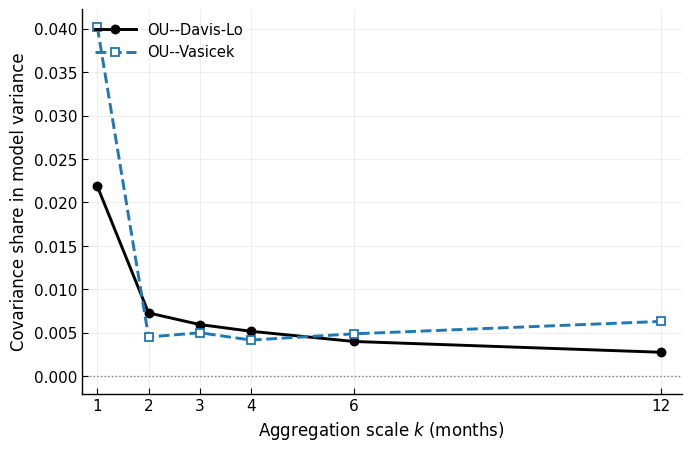

Saved: figures/fig6a_renormalized_fitting_covariance_share_k_month_davislo_vasicek.png
Saved: figures/fig6a_renormalized_fitting_covariance_share_k_month_davislo_vasicek.pdf


In [20]:
# ============================================================
# Fig. 6a:
# Renormalized-fitting covariance share
# model-specific renormalized paths
# OU--Davis-Lo and 　OU--Vasicek
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Save table for model-specific renormalized fitting results
# ------------------------------------------------------------

df_compare_renorm = df_renorm_modelpath_vardecomp.copy()
df_compare_renorm["scale"] = "renormalized k-month"
df_compare_renorm["source"] = TARGET_SECTOR

# Keep only residual-dependence models
df_compare_renorm = df_compare_renorm[
    df_compare_renorm["model"].isin([
        "renorm_modelpath_davis_lo",
        "renorm_modelpath_vasicek",
    ])
].copy()

common_cols_renorm = [
    "scale",
    "source",
    "k_month",
    "model",
    "model_display",
    "source_model",
    "observed_var",
    "macro_var_median",
    "binomial_sampling_var_median",
    "extra_corr_var_median",
    "total_model_var_median",
    "model_over_observed_median",
    "macro_over_observed_median",
    "binomial_over_observed_median",
    "extra_over_observed_median",
    "extra_share_of_model_median",
]

df_variance_decomp_renorm_comparison = df_compare_renorm[common_cols_renorm].copy()

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

# ------------------------------------------------------------
# Plot setting
# ------------------------------------------------------------

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

model_styles_renorm = {
    "renorm_modelpath_davis_lo": {
        "label": "OU--Davis-Lo",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
    },
    "renorm_modelpath_vasicek": {
        "label": "OU--Vasicek",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(6.8, 4.4),
    constrained_layout=True,
)

for model_name in ["renorm_modelpath_davis_lo", "renorm_modelpath_vasicek"]:

    st = model_styles_renorm[model_name]

    gk = (
        df_compare_renorm[df_compare_renorm["model"] == model_name]
        .sort_values("k_month")
        .copy()
    )

    if len(gk) == 0:
        continue

    ax.plot(
        gk["k_month"],
        gk["extra_share_of_model_median"],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        label=st["label"],
        zorder=3,
    )

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------

ax.set_xlabel("Aggregation scale $k$ (months)")
ax.set_ylabel("Covariance share in model variance")

ax.set_xticks([1, 2, 3, 4, 6, 12])
ax.set_xlim(0.7, 12.4)

ax.axhline(
    0.0,
    linestyle=":",
    linewidth=1.0,
    color="0.45",
    zorder=0,
)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="upper left",
    fontsize=10.5,
    handlelength=2.8,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

fig_path_png = FIG_DIR / "fig6a_renormalized_fitting_covariance_share_k_month_davislo_vasicek.png"
fig_path_pdf = FIG_DIR / "fig6a_renormalized_fitting_covariance_share_k_month_davislo_vasicek.pdf"

fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)

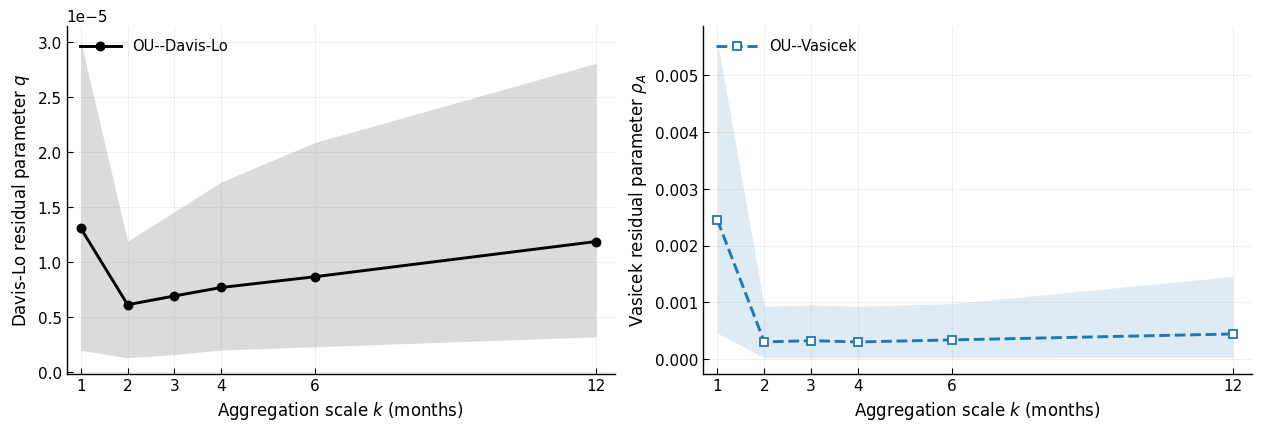

Saved: figures/figS_renormalized_modelpath_residual_parameters_by_k.png
Saved: figures/figS_renormalized_modelpath_residual_parameters_by_k.pdf
Output directory: pdata
Figure directory: figures


In [21]:
# ============================================================
# 18. Model-specific renormalized fitting: WAIC and variance-decomposition figures
#
# Publication plots use the same black-blue style as Direct Fitting and 03.ipynb.
# ============================================================

FIG_DIR = Path("./figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def plot_model_line(ax, g, model_key, y_col, label=None, zorder=3):
    st = PLOT_STYLE_RENORM[model_key]
    ax.plot(
        g["k_month"],
        g[y_col],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        label=label if label is not None else st["label"],
        zorder=zorder,
    )


# ------------------------------------------------------------
# WAIC table and plot
# ------------------------------------------------------------

cols_waic = [
    "k_month", "model_display", "model", "source_model",
    "waic", "waic_se", "p_waic", "lppd", "elpd_waic",
    "delta_waic_vs_modelpath_binomial",
    "delta_elpd_waic_vs_modelpath_binomial",
    "estimated_extra_parameter", "p_path_treatment",
]

pass  # Display suppressed in public minimal version.
# ------------------------------------------------------------
# Variance-decomposition table
# ------------------------------------------------------------

cols_vd = [
    "k_month", "model_display", "model", "observed_var",
    "macro_var_median",
    "binomial_sampling_var_median",
    "extra_corr_var_median",
    "total_model_var_median",
    "model_over_observed_median",
    "macro_over_observed_median",
    "binomial_over_observed_median",
    "extra_over_observed_median",
    "extra_share_of_model_median",
    "p_path_treatment",
]

df_renorm_modelpath_vardecomp_table = (
    df_renorm_modelpath_vardecomp[cols_vd]
    .sort_values(["k_month", "model"])
    .copy()
)

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ------------------------------------------------------------
# Figure: residual parameter scale dependence
# Separate axes are safer because q and rho_A have different scales.
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), constrained_layout=True)

for ax, model_key, param_contains, ylabel in [
    (axes[0], "renorm_modelpath_davis_lo", "q", r"Davis-Lo residual parameter $q$"),
    (axes[1], "renorm_modelpath_vasicek", "rho_A", r"Vasicek residual parameter $\rho_A$"),
]:
    g = df_param_renorm_modelpath[
        (df_param_renorm_modelpath["model"] == model_key)
        & (df_param_renorm_modelpath["parameter"].astype(str).str.contains(param_contains, regex=False))
    ].sort_values("k_month")

    st = PLOT_STYLE_RENORM[model_key]
    ax.plot(
        g["k_month"],
        g["mean"],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        label=st["label"],
        zorder=3,
    )
    if {"hdi_2.5%", "hdi_97.5%"}.issubset(g.columns):
        ax.fill_between(
            g["k_month"].to_numpy(),
            g["hdi_2.5%"].to_numpy(),
            g["hdi_97.5%"].to_numpy(),
            color=st["color"],
            alpha=0.14,
            linewidth=0,
        )
    ax.set_xlabel("Aggregation scale $k$ (months)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(K_LIST_RENORM)
    ax.set_xlim(0.7, 12.4)
    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(frameon=False, loc="upper left", handlelength=2.8)

fig_path_png = FIG_DIR / "figS_renormalized_modelpath_residual_parameters_by_k.png"
fig_path_pdf = FIG_DIR / "figS_renormalized_modelpath_residual_parameters_by_k.pdf"
fig.savefig(fig_path_png, dpi=300, bbox_inches="tight")
fig.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()
print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)

print("Output directory:", OUT_DIR)
print("Figure directory:", FIG_DIR)


In [22]:
# ============================================================
# Renormalized Fitting: final summary tables
#
# Summarizes:
#   1. residual-parameter estimates
#   2. variance decomposition
#   3. WAIC / elpd comparison against renormalized OU-Binomial
#   4. integrated paper-facing table
#
# Required objects:
#   df_renorm_modelpath_vardecomp
#   df_waic_renorm_modelpath
#   df_param_renorm_modelpath
#   OUT_DIR
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display

# ------------------------------------------------------------
# Labels and order
# ------------------------------------------------------------
RENORM_MODEL_LABELS = {
    "renorm_modelpath_binomial": "OU--Binomial",
    "renorm_modelpath_davis_lo": "OU--Davis-Lo",
    "renorm_modelpath_vasicek": "OU--Vasicek",
}

RENORM_MODEL_ORDER = [
    "renorm_modelpath_binomial",
    "renorm_modelpath_davis_lo",
    "renorm_modelpath_vasicek",
]

RENORM_PAPER_MODELS = [
    "renorm_modelpath_davis_lo",
    "renorm_modelpath_vasicek",
]


def _first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def dataframe_to_markdown_no_tabulate(df, float_digits=6):
    """
    pandas.to_markdown() を使わずに Markdown table を生成する。
    tabulate 未インストール環境用。
    """
    def fmt(x):
        if pd.isna(x):
            return ""
        if isinstance(x, float):
            return f"{x:.{float_digits}g}"
        return str(x)

    cols = list(df.columns)
    header = "| " + " | ".join(cols) + " |"
    sep = "| " + " | ".join(["---"] * len(cols)) + " |"

    rows = []
    for _, r in df.iterrows():
        rows.append("| " + " | ".join(fmt(r[c]) for c in cols) + " |")

    return "\n".join([header, sep] + rows)


# ============================================================
# 1. Residual-parameter summary
# ============================================================

df_renorm_param_summary = df_param_renorm_modelpath.copy()

# Normalize column names
if "model_display" not in df_renorm_param_summary.columns:
    df_renorm_param_summary["model_display"] = df_renorm_param_summary["model"].map(
        RENORM_MODEL_LABELS
    )

if "model" not in df_renorm_param_summary.columns:
    reverse_label = {v: k for k, v in RENORM_MODEL_LABELS.items()}
    df_renorm_param_summary["model"] = df_renorm_param_summary["model_display"].map(
        reverse_label
    )

# Standardize interval columns
low_col = _first_existing_col(
    df_renorm_param_summary,
    ["hdi_2.5%", "hdi_3%", "q025", "lower", "hdi_low"]
)
high_col = _first_existing_col(
    df_renorm_param_summary,
    ["hdi_97.5%", "hdi_97%", "q975", "upper", "hdi_high"]
)

if low_col is not None and low_col != "hdi_low":
    df_renorm_param_summary["hdi_low"] = df_renorm_param_summary[low_col]
elif "hdi_low" not in df_renorm_param_summary.columns:
    df_renorm_param_summary["hdi_low"] = np.nan

if high_col is not None and high_col != "hdi_high":
    df_renorm_param_summary["hdi_high"] = df_renorm_param_summary[high_col]
elif "hdi_high" not in df_renorm_param_summary.columns:
    df_renorm_param_summary["hdi_high"] = np.nan

param_cols = [
    "k_month",
    "model",
    "model_display",
    "parameter",
    "mean",
    "sd",
    "median",
    "hdi_low",
    "hdi_high",
    "ess_bulk",
    "ess_tail",
    "r_hat",
    "source",
]

param_cols = [c for c in param_cols if c in df_renorm_param_summary.columns]

df_renorm_param_summary = df_renorm_param_summary[param_cols].copy()

df_renorm_param_summary["model_order"] = df_renorm_param_summary["model"].map(
    {m: i for i, m in enumerate(RENORM_MODEL_ORDER)}
)

df_renorm_param_summary = (
    df_renorm_param_summary
    .sort_values(["k_month", "model_order", "parameter"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_renorm_param_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 2. Compact residual-parameter table
# ============================================================

def _fmt_estimate(mean, low, high, digits=4):
    if pd.isna(mean):
        return ""
    if pd.isna(low) or pd.isna(high):
        return f"{mean:.{digits}g}"
    return f"{mean:.{digits}g} [{low:.{digits}g}, {high:.{digits}g}]"


df_param_fmt = df_renorm_param_summary.copy()

df_param_fmt["estimate"] = df_param_fmt.apply(
    lambda r: _fmt_estimate(
        r.get("median", r.get("mean", np.nan)),
        r.get("hdi_low", np.nan),
        r.get("hdi_high", np.nan),
        digits=4,
    ),
    axis=1,
)

df_renorm_param_compact = (
    df_param_fmt
    .pivot_table(
        index=["k_month", "model", "model_display"],
        columns="parameter",
        values="estimate",
        aggfunc="first",
    )
    .reset_index()
)

preferred_param_cols = [
    "q",
    "rho_A",
    "ld_k1_q",
    "vas_k1_rho_A",
]

existing_param_cols = [
    c for c in preferred_param_cols
    if c in df_renorm_param_compact.columns
]

other_param_cols = [
    c for c in df_renorm_param_compact.columns
    if c not in ["k_month", "model", "model_display"] + existing_param_cols
]

df_renorm_param_compact = df_renorm_param_compact[
    ["k_month", "model", "model_display"] + existing_param_cols + other_param_cols
]

df_renorm_param_compact["model_order"] = df_renorm_param_compact["model"].map(
    {m: i for i, m in enumerate(RENORM_MODEL_ORDER)}
)

df_renorm_param_compact = (
    df_renorm_param_compact
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_renorm_param_compact)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 3. Variance-decomposition summary
# ============================================================

df_renorm_vardecomp_summary = df_renorm_modelpath_vardecomp.copy()

if "model_display" not in df_renorm_vardecomp_summary.columns:
    df_renorm_vardecomp_summary["model_display"] = df_renorm_vardecomp_summary["model"].map(
        RENORM_MODEL_LABELS
    )

cols_vd = [
    "k_month",
    "model",
    "model_display",
    "source_model",
    "observed_var",
    "macro_var_median",
    "binomial_sampling_var_median",
    "extra_corr_var_median",
    "total_model_var_median",
    "model_over_observed_median",
    "macro_over_observed_median",
    "binomial_over_observed_median",
    "extra_over_observed_median",
    "extra_share_of_model_median",
    "p_path_treatment",
]

cols_vd = [c for c in cols_vd if c in df_renorm_vardecomp_summary.columns]

df_renorm_vardecomp_summary = df_renorm_vardecomp_summary[cols_vd].copy()

df_renorm_vardecomp_summary["model_order"] = df_renorm_vardecomp_summary["model"].map(
    {m: i for i, m in enumerate(RENORM_MODEL_ORDER)}
)

df_renorm_vardecomp_summary = (
    df_renorm_vardecomp_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_renorm_vardecomp_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 4. WAIC / elpd summary
# ============================================================

df_renorm_waic_summary = df_waic_renorm_modelpath.copy()

if "model_display" not in df_renorm_waic_summary.columns:
    df_renorm_waic_summary["model_display"] = df_renorm_waic_summary["model"].map(
        RENORM_MODEL_LABELS
    )

# Make block count T if not present
if "T" not in df_renorm_waic_summary.columns:
    if "block_obs_by_k" in globals():
        block_count_by_k = {
            int(k): len(block_obs_by_k[int(k)][2])
            for k in sorted(block_obs_by_k.keys())
        }
        df_renorm_waic_summary["T"] = df_renorm_waic_summary["k_month"].map(
            block_count_by_k
        )
    else:
        df_renorm_waic_summary["T"] = np.nan

# Delta WAIC relative to renormalized OU-Binomial
if "delta_waic_vs_modelpath_binomial" not in df_renorm_waic_summary.columns:
    baseline = (
        df_renorm_waic_summary[
            df_renorm_waic_summary["model"] == "renorm_modelpath_binomial"
        ][["k_month", "waic"]]
        .rename(columns={"waic": "waic_renorm_modelpath_binomial"})
    )

    df_renorm_waic_summary = df_renorm_waic_summary.merge(
        baseline,
        on="k_month",
        how="left",
    )

    df_renorm_waic_summary["delta_waic_vs_modelpath_binomial"] = (
        df_renorm_waic_summary["waic"]
        - df_renorm_waic_summary["waic_renorm_modelpath_binomial"]
    )

# Delta elpd
if "delta_elpd_waic_vs_modelpath_binomial" not in df_renorm_waic_summary.columns:
    if "elpd_waic" in df_renorm_waic_summary.columns:
        baseline = (
            df_renorm_waic_summary[
                df_renorm_waic_summary["model"] == "renorm_modelpath_binomial"
            ][["k_month", "elpd_waic"]]
            .rename(columns={"elpd_waic": "elpd_waic_renorm_modelpath_binomial"})
        )

        if "elpd_waic_renorm_modelpath_binomial" not in df_renorm_waic_summary.columns:
            df_renorm_waic_summary = df_renorm_waic_summary.merge(
                baseline,
                on="k_month",
                how="left",
            )

        df_renorm_waic_summary["delta_elpd_waic_vs_modelpath_binomial"] = (
            df_renorm_waic_summary["elpd_waic"]
            - df_renorm_waic_summary["elpd_waic_renorm_modelpath_binomial"]
        )
    else:
        df_renorm_waic_summary["delta_elpd_waic_vs_modelpath_binomial"] = (
            -0.5 * df_renorm_waic_summary["delta_waic_vs_modelpath_binomial"]
        )

df_renorm_waic_summary["delta_elpd_per_block_vs_modelpath_binomial"] = (
    df_renorm_waic_summary["delta_elpd_waic_vs_modelpath_binomial"]
    / df_renorm_waic_summary["T"]
)

df_renorm_waic_summary["delta_waic_per_block_vs_modelpath_binomial"] = (
    df_renorm_waic_summary["delta_waic_vs_modelpath_binomial"]
    / df_renorm_waic_summary["T"]
)

cols_waic = [
    "k_month",
    "T",
    "model",
    "model_display",
    "source_model",
    "waic",
    "waic_se",
    "p_waic",
    "lppd",
    "elpd_waic",
    "delta_waic_vs_modelpath_binomial",
    "delta_elpd_waic_vs_modelpath_binomial",
    "delta_elpd_per_block_vs_modelpath_binomial",
    "delta_waic_per_block_vs_modelpath_binomial",
    "estimated_extra_parameter",
    "residual_parameter_inference",
    "p_path_treatment",
]

cols_waic = [c for c in cols_waic if c in df_renorm_waic_summary.columns]

df_renorm_waic_summary = df_renorm_waic_summary[cols_waic].copy()

df_renorm_waic_summary["model_order"] = df_renorm_waic_summary["model"].map(
    {m: i for i, m in enumerate(RENORM_MODEL_ORDER)}
)

df_renorm_waic_summary = (
    df_renorm_waic_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_renorm_waic_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.



# ============================================================
# 5. Numerical residual-parameter table for merging
# ============================================================

df_param_numeric = df_renorm_param_summary.copy()

value_col = "median" if "median" in df_param_numeric.columns else "mean"

# ------------------------------------------------------------
# Normalize residual-parameter names before pivoting
# ------------------------------------------------------------

def normalize_renorm_parameter_name(row):
    model = row.get("model", "")
    param = str(row.get("parameter", ""))

    # k=1 monthly joint-fit names
    if param in ["ld_k1_q", "q_k1", "q"]:
        if model == "renorm_modelpath_davis_lo":
            return "q"

    if param in ["vas_k1_rho_A", "rho_A_k1", "rho_A", "rho"]:
        if model == "renorm_modelpath_vasicek":
            return "rho_A"

    # k >= 2 path-marginalized residual parameter names
    # These names depend on the construction of df_param_renorm_modelpath.
    # Treat generic theta/residual names as q for Davis-Lo and rho_A for Vasicek.
    if param in [
        "theta",
        "theta_k",
        "residual_param",
        "residual_parameter",
        "extra_param",
        "param",
        "value",
    ]:
        if model == "renorm_modelpath_davis_lo":
            return "q"
        if model == "renorm_modelpath_vasicek":
            return "rho_A"

    # Model-specific fallbacks
    if "q" in param and model == "renorm_modelpath_davis_lo":
        return "q"

    if ("rho" in param or "rho_A" in param) and model == "renorm_modelpath_vasicek":
        return "rho_A"

    return param


df_param_numeric["parameter_norm"] = df_param_numeric.apply(
    normalize_renorm_parameter_name,
    axis=1,
)

# Optional diagnostic: check whether q/rho_A are present after normalization
print("Renormalized parameter names after normalization:")
display(
    df_param_numeric[
        ["k_month", "model", "parameter", "parameter_norm", value_col]
    ].sort_values(["k_month", "model", "parameter_norm"])
)

df_param_numeric_wide = (
    df_param_numeric
    .pivot_table(
        index=["k_month", "model"],
        columns="parameter_norm",
        values=value_col,
        aggfunc="first",
    )
    .reset_index()
)

# Ensure required columns exist even if absent for some models
if "q" not in df_param_numeric_wide.columns:
    df_param_numeric_wide["q"] = np.nan

if "rho_A" not in df_param_numeric_wide.columns:
    df_param_numeric_wide["rho_A"] = np.nan

display(df_param_numeric_wide)


# ============================================================
# 6. Integrated Renormalized Fitting summary
# ============================================================

df_renorm_integrated_summary = df_renorm_vardecomp_summary.copy()

waic_cols_for_merge = [
    "k_month",
    "model",
    "waic",
    "waic_se",
    "p_waic",
    "lppd",
    "elpd_waic",
    "delta_waic_vs_modelpath_binomial",
    "delta_elpd_waic_vs_modelpath_binomial",
    "delta_elpd_per_block_vs_modelpath_binomial",
]

waic_cols_for_merge = [
    c for c in waic_cols_for_merge
    if c in df_renorm_waic_summary.columns
]

df_renorm_integrated_summary = df_renorm_integrated_summary.merge(
    df_renorm_waic_summary[waic_cols_for_merge],
    on=["k_month", "model"],
    how="left",
)

param_cols_for_merge = [
    c for c in ["k_month", "model", "q", "rho_A"]
    if c in df_param_numeric_wide.columns
]

df_renorm_integrated_summary = df_renorm_integrated_summary.merge(
    df_param_numeric_wide[param_cols_for_merge],
    on=["k_month", "model"],
    how="left",
)

front_cols = [
    "k_month",
    "model",
    "model_display",
    "source_model",
    "q",
    "rho_A",
    "waic",
    "delta_waic_vs_modelpath_binomial",
    "delta_elpd_per_block_vs_modelpath_binomial",
    "observed_var",
    "macro_var_median",
    "binomial_sampling_var_median",
    "extra_corr_var_median",
    "total_model_var_median",
    "model_over_observed_median",
    "macro_over_observed_median",
    "binomial_over_observed_median",
    "extra_over_observed_median",
    "extra_share_of_model_median",
    "p_path_treatment",
]

front_cols = [
    c for c in front_cols
    if c in df_renorm_integrated_summary.columns
]

remaining_cols = [
    c for c in df_renorm_integrated_summary.columns
    if c not in front_cols
]

df_renorm_integrated_summary = df_renorm_integrated_summary[
    front_cols + remaining_cols
]

df_renorm_integrated_summary["model_order"] = df_renorm_integrated_summary["model"].map(
    {m: i for i, m in enumerate(RENORM_MODEL_ORDER)}
)

df_renorm_integrated_summary = (
    df_renorm_integrated_summary
    .sort_values(["k_month", "model_order"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)

display(df_renorm_integrated_summary)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.


# ============================================================
# 7. Paper-facing compact table
# ============================================================

paper_cols = [
    "k_month",
    "model_display",
    "source_model",
    "q",
    "rho_A",
    "extra_share_of_model_median",
    "extra_over_observed_median",
    "macro_over_observed_median",
    "binomial_over_observed_median",
    "model_over_observed_median",
    "delta_waic_vs_modelpath_binomial",
    "delta_elpd_per_block_vs_modelpath_binomial",
]

paper_cols = [
    c for c in paper_cols
    if c in df_renorm_integrated_summary.columns
]

df_renorm_paper_table = (
    df_renorm_integrated_summary[
        df_renorm_integrated_summary["model"].isin(RENORM_PAPER_MODELS)
    ][paper_cols]
    .copy()
)

df_renorm_paper_table = df_renorm_paper_table.rename(columns={
    "k_month": "k",
    "model_display": "model",
    "source_model": "p_path_source",
    "extra_share_of_model_median": "intrinsic_covariance_share",
    "extra_over_observed_median": "intrinsic_covariance_over_observed",
    "macro_over_observed_median": "macro_path_over_observed",
    "binomial_over_observed_median": "binomial_noise_over_observed",
    "model_over_observed_median": "model_variance_over_observed",
    "delta_waic_vs_modelpath_binomial": "Delta_WAIC_vs_renorm_OU_Binomial",
    "delta_elpd_per_block_vs_modelpath_binomial": "Delta_elpd_per_block",
})

display(df_renorm_paper_table)

# Save raw numerical paper table
df_renorm_paper_table.to_csv(
    OUT_DIR / "renormalized_fitting_paper_table.csv",
    index=False,
)



# ------------------------------------------------------------
# Paper-facing formatted table
#   Direct fitting table と同じ情報に絞る
#   q and rho_A are both reported in scientific notation
#   Models are grouped as OU--V first, then OU--DL
# ------------------------------------------------------------

# Keep only the columns corresponding to the Direct Fitting paper table
paper_display_cols = [
    "k",
    "model",
    "q",
    "rho_A",
    "intrinsic_covariance_share",
    "Delta_WAIC_vs_renorm_OU_Binomial",
    "Delta_elpd_per_block",
    "model_variance_over_observed",
]

paper_display_cols = [
    c for c in paper_display_cols
    if c in df_renorm_paper_table.columns
]

df_renorm_paper_table_for_display = df_renorm_paper_table[paper_display_cols].copy()

# Short model names for paper table
model_short_map = {
    "OU--Vasicek": "OU--V",
    "OU--Davis-Lo": "OU--DL",
    "OU--Davis--Lo": "OU--DL",
}

df_renorm_paper_table_for_display["model"] = (
    df_renorm_paper_table_for_display["model"]
    .replace(model_short_map)
)

# Sort by model first, then k
model_order_short = {
    "OU--V": 0,
    "OU--DL": 1,
}

df_renorm_paper_table_for_display["model_order"] = (
    df_renorm_paper_table_for_display["model"].map(model_order_short)
)

df_renorm_paper_table_for_display = (
    df_renorm_paper_table_for_display
    .sort_values(["model_order", "k"])
    .drop(columns=["model_order"])
    .reset_index(drop=True)
)


def fmt_sci_or_dash(x, digits=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{digits}e}"


def fmt_fixed_or_dash(x, digits=3):
    if pd.isna(x):
        return "--"
    return f"{x:.{digits}f}"


def fmt_fixed2_or_dash(x, digits=2):
    if pd.isna(x):
        return "--"
    return f"{x:.{digits}f}"


df_renorm_paper_table_fmt = df_renorm_paper_table_for_display.copy()

# q and rho_A are tiny, so use scientific notation for both
if "q" in df_renorm_paper_table_fmt.columns:
    df_renorm_paper_table_fmt["q"] = df_renorm_paper_table_fmt["q"].apply(
        lambda x: fmt_sci_or_dash(x, digits=3)
    )

if "rho_A" in df_renorm_paper_table_fmt.columns:
    df_renorm_paper_table_fmt["rho_A"] = df_renorm_paper_table_fmt["rho_A"].apply(
        lambda x: fmt_sci_or_dash(x, digits=3)
    )

for c in [
    "intrinsic_covariance_share",
    "Delta_elpd_per_block",
    "model_variance_over_observed",
]:
    if c in df_renorm_paper_table_fmt.columns:
        df_renorm_paper_table_fmt[c] = df_renorm_paper_table_fmt[c].apply(
            lambda x: fmt_fixed_or_dash(x, digits=3)
        )

if "Delta_WAIC_vs_renorm_OU_Binomial" in df_renorm_paper_table_fmt.columns:
    df_renorm_paper_table_fmt["Delta_WAIC_vs_renorm_OU_Binomial"] = (
        df_renorm_paper_table_fmt["Delta_WAIC_vs_renorm_OU_Binomial"].apply(
            lambda x: fmt_fixed2_or_dash(x, digits=2)
        )
    )

# Rename columns for paper readability
df_renorm_paper_table_fmt = df_renorm_paper_table_fmt.rename(columns={
    "k": "$k$",
    "model": "Model",
    "q": "$q_k$",
    "rho_A": "$\\rho_{A,k}$",
    "intrinsic_covariance_share": "Intrinsic cov. share",
    "Delta_WAIC_vs_renorm_OU_Binomial": "$\\Delta{\\rm WAIC}$",
    "Delta_elpd_per_block": "$\\Delta{\\rm elpd}/B_k$",
    "model_variance_over_observed": "Model/data var.",
})

display(df_renorm_paper_table_fmt)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

pass  # Markdown/TeX output suppressed for public minimal version.
pass  # Markdown/TeX output suppressed for public minimal version.
# ============================================================
# 8. Wide table for Fig. 6 and comparison with Direct Fitting
# ============================================================

df_renorm_intrinsic_share_wide = (
    df_renorm_integrated_summary[
        df_renorm_integrated_summary["model"].isin(RENORM_PAPER_MODELS)
    ]
    .pivot_table(
        index="k_month",
        columns="model_display",
        values="extra_share_of_model_median",
        aggfunc="first",
    )
    .reset_index()
)

display(df_renorm_intrinsic_share_wide)

pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

pass  # Suppressed verbose file-output message.
print("Main table:")
print(" - renormalized_fitting_integrated_summary.csv")
print(" - renormalized_fitting_paper_table.csv")
print(" - renormalized_fitting_paper_table_formatted.csv")
print(" - renormalized_fitting_paper_table.md")
print(" - renormalized_fitting_paper_table.tex")

,k_month,model,model_display,parameter,mean,sd,median,hdi_low,hdi_high,ess_bulk,ess_tail,r_hat,source
0,1,renorm_modelpath_davis_lo,OU-Davis-Lo,ld_k1_q,0.000013,0.000008,0.000012,0.000002,0.000030,NaN,NaN,NaN,joint k=1 Bayesian fit
1,1,renorm_modelpath_vasicek,OU-Vasicek,vas_k1_rho_A,0.002450,0.001330,0.002196,0.000454,0.005602,NaN,NaN,NaN,joint k=1 Bayesian fit
2,2,renorm_modelpath_davis_lo,OU-Davis-Lo,renorm_modelpath_davis_lo_k2_q,0.000006,0.000003,0.000006,0.000001,0.000012,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
3,2,renorm_modelpath_vasicek,OU-Vasicek,renorm_modelpath_vasicek_k2_rho_A,0.000302,0.000274,0.000222,0.000023,0.000933,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
4,3,renorm_modelpath_davis_lo,OU-Davis-Lo,renorm_modelpath_davis_lo_k3_q,0.000007,0.000003,0.000007,0.000002,0.000015,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
5,3,renorm_modelpath_vasicek,OU-Vasicek,renorm_modelpath_vasicek_k3_rho_A,0.000325,0.000290,0.000245,0.000024,0.000955,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
6,4,renorm_modelpath_davis_lo,OU-Davis-Lo,renorm_modelpath_davis_lo_k4_q,0.000008,0.000004,0.000008,0.000002,0.000017,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
7,4,renorm_modelpath_vasicek,OU-Vasicek,renorm_modelpath_vasicek_k4_rho_A,0.000301,0.000278,0.000215,0.000023,0.000933,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
8,6,renorm_modelpath_davis_lo,OU-Davis-Lo,renorm_modelpath_davis_lo_k6_q,0.000009,0.000004,0.000008,0.000002,0.000021,NaN,NaN,NaN,grid posterior over marginal p-path likelihood
9,6,renorm_modelpath_vasicek,OU-Vasicek,renorm_modelpath_vasicek_k6_rho_A,0.000338,0.000306,0.000260,0.000024,0.000978,NaN,NaN,NaN,grid posterior over marginal p-path likelihood


parameter,k_month,model,model_display,ld_k1_q,vas_k1_rho_A,renorm_modelpath_davis_lo_k12_q,renorm_modelpath_davis_lo_k2_q,renorm_modelpath_davis_lo_k3_q,renorm_modelpath_davis_lo_k4_q,renorm_modelpath_davis_lo_k6_q,renorm_modelpath_vasicek_k12_rho_A,renorm_modelpath_vasicek_k2_rho_A,renorm_modelpath_vasicek_k3_rho_A,renorm_modelpath_vasicek_k4_rho_A,renorm_modelpath_vasicek_k6_rho_A
0,1,renorm_modelpath_davis_lo,OU-Davis-Lo,"1.187e-05 [1.973e-06, 3.008e-05]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,renorm_modelpath_vasicek,OU-Vasicek,NaN,"0.002196 [0.0004545, 0.005602]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,renorm_modelpath_davis_lo,OU-Davis-Lo,NaN,NaN,NaN,"6.1e-06 [1.3e-06, 1.19e-05]",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,renorm_modelpath_vasicek,OU-Vasicek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0.0002222 [2.3e-05, 0.0009327]",NaN,NaN,NaN
4,3,renorm_modelpath_davis_lo,OU-Davis-Lo,NaN,NaN,NaN,NaN,"6.9e-06 [1.6e-06, 1.46e-05]",NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3,renorm_modelpath_vasicek,OU-Vasicek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0.0002446 [2.4e-05, 0.0009551]",NaN,NaN
6,4,renorm_modelpath_davis_lo,OU-Davis-Lo,NaN,NaN,NaN,NaN,NaN,"7.5e-06 [2e-06, 1.729e-05]",NaN,NaN,NaN,NaN,NaN,NaN
7,4,renorm_modelpath_vasicek,OU-Vasicek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0.0002147 [2.3e-05, 0.0009327]",NaN
8,6,renorm_modelpath_davis_lo,OU-Davis-Lo,NaN,NaN,NaN,NaN,NaN,NaN,"8.1e-06 [2.3e-06, 2.089e-05]",NaN,NaN,NaN,NaN,NaN
9,6,renorm_modelpath_vasicek,OU-Vasicek,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"0.0002596 [2.4e-05, 0.0009776]"


,k_month,model,model_display,source_model,observed_var,macro_var_median,binomial_sampling_var_median,extra_corr_var_median,total_model_var_median,model_over_observed_median,macro_over_observed_median,binomial_over_observed_median,extra_over_observed_median,extra_share_of_model_median,p_path_treatment
0,1,renorm_modelpath_binomial,OU-Binomial,binomial,0.000001,8.972761e-07,3.749500e-07,0.000000e+00,0.000001,0.946473,0.666470,0.278502,0.000000,0.000000,posterior sample paths
1,1,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000001,8.793286e-07,3.732636e-07,2.824842e-08,0.000001,0.953976,0.653139,0.277249,0.020982,0.021871,posterior sample paths
2,1,renorm_modelpath_vasicek,OU-Vasicek,vasicek,0.000001,8.615414e-07,3.741322e-07,5.157620e-08,0.000001,0.958085,0.639927,0.277894,0.038309,0.040234,posterior sample paths
3,2,renorm_modelpath_binomial,OU-Binomial,binomial,0.000004,3.432796e-06,7.501680e-07,0.000000e+00,0.000004,0.996050,0.817119,0.178565,0.000000,0.000000,posterior sample paths
4,2,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000004,3.201657e-06,7.299730e-07,2.877577e-08,0.000004,0.944610,0.762100,0.173758,0.006850,0.007279,posterior sample paths
5,2,renorm_modelpath_vasicek,OU-Vasicek,vasicek,0.000004,3.315580e-06,7.473450e-07,1.813203e-08,0.000004,0.972655,0.789218,0.177893,0.004316,0.004506,posterior sample paths
6,3,renorm_modelpath_binomial,OU-Binomial,binomial,0.000009,7.489930e-06,1.121184e-06,0.000000e+00,0.000009,0.993373,0.863963,0.129328,0.000000,0.000000,posterior sample paths
7,3,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000009,7.043398e-06,1.095021e-06,4.917450e-08,0.000008,0.944633,0.812455,0.126311,0.005672,0.005939,posterior sample paths
8,3,renorm_modelpath_vasicek,OU-Vasicek,vasicek,0.000009,7.236860e-06,1.119038e-06,4.245999e-08,0.000008,0.970057,0.834771,0.129081,0.004898,0.004994,posterior sample paths
9,4,renorm_modelpath_binomial,OU-Binomial,binomial,0.000014,1.268830e-05,1.496155e-06,0.000000e+00,0.000014,1.008201,0.901798,0.106337,0.000000,0.000000,posterior sample paths


,k_month,T,model,model_display,source_model,waic,waic_se,p_waic,lppd,elpd_waic,delta_waic_vs_modelpath_binomial,delta_elpd_waic_vs_modelpath_binomial,delta_elpd_per_block_vs_modelpath_binomial,delta_waic_per_block_vs_modelpath_binomial,estimated_extra_parameter,residual_parameter_inference,p_path_treatment
0,1,489,renorm_modelpath_binomial,OU-Binomial,binomial,2056.512044,42.968097,103.780907,-924.475115,-1028.256022,0.000000,0.000000,0.000000,0.000000,none,none,posterior sample paths
1,1,489,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,2061.159996,42.192830,90.664614,-939.915384,-1030.579998,4.647952,-2.323976,-0.004753,0.009505,ld_k1_q,joint k=1 posterior,posterior sample paths
2,1,489,renorm_modelpath_vasicek,OU-Vasicek,vasicek,2063.711023,42.079316,85.864723,-945.990789,-1031.855512,7.198979,-3.599490,-0.007361,0.014722,vas_k1_rho_A,joint k=1 posterior,posterior sample paths
3,2,244,renorm_modelpath_binomial,OU-Binomial,binomial,1223.446150,24.754623,69.346641,-542.376434,-611.723075,0.000000,0.000000,0.000000,0.000000,none,none,posterior sample paths
4,2,244,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,1100.981082,18.732432,0.099358,-550.391183,-550.490541,-122.465067,61.232534,0.250953,-0.501906,renorm_modelpath_davis_lo_k2_q,grid posterior over marginal p-path likelihood,posterior sample paths
5,2,244,renorm_modelpath_vasicek,OU-Vasicek,vasicek,1101.130074,18.510164,0.013577,-550.551460,-550.565037,-122.316076,61.158038,0.250648,-0.501295,renorm_modelpath_vasicek_k2_rho_A,grid posterior over marginal p-path likelihood,posterior sample paths
6,3,163,renorm_modelpath_binomial,OU-Binomial,binomial,904.426631,19.968641,56.457401,-395.755914,-452.213315,0.000000,0.000000,0.000000,0.000000,none,none,posterior sample paths
7,3,163,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,803.938351,14.477135,0.099568,-401.869607,-401.969176,-100.488280,50.244140,0.308246,-0.616493,renorm_modelpath_davis_lo_k3_q,grid posterior over marginal p-path likelihood,posterior sample paths
8,3,163,renorm_modelpath_vasicek,OU-Vasicek,vasicek,804.382455,14.441512,0.018828,-402.172400,-402.191228,-100.044176,50.022088,0.306884,-0.613768,renorm_modelpath_vasicek_k3_rho_A,grid posterior over marginal p-path likelihood,posterior sample paths
9,4,122,renorm_modelpath_binomial,OU-Binomial,binomial,713.036121,15.018387,43.603270,-312.914791,-356.518060,0.000000,0.000000,0.000000,0.000000,none,none,posterior sample paths


Renormalized parameter names after normalization:


...

,k_month,model,model_display,source_model,q,rho_A,waic,delta_waic_vs_modelpath_binomial,delta_elpd_per_block_vs_modelpath_binomial,observed_var,macro_var_median,binomial_sampling_var_median,extra_corr_var_median,total_model_var_median,model_over_observed_median,macro_over_observed_median,binomial_over_observed_median,extra_over_observed_median,extra_share_of_model_median,p_path_treatment,waic_se,p_waic,lppd,elpd_waic,delta_elpd_waic_vs_modelpath_binomial
0,1,renorm_modelpath_binomial,OU-Binomial,binomial,NaN,NaN,2056.512044,0.000000,0.000000,0.000001,8.972761e-07,3.749500e-07,0.000000e+00,0.000001,0.946473,0.666470,0.278502,0.000000,0.000000,posterior sample paths,42.968097,103.780907,-924.475115,-1028.256022,0.000000
1,1,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000012,NaN,2061.159996,4.647952,-0.004753,0.000001,8.793286e-07,3.732636e-07,2.824842e-08,0.000001,0.953976,0.653139,0.277249,0.020982,0.021871,posterior sample paths,42.192830,90.664614,-939.915384,-1030.579998,-2.323976
2,1,renorm_modelpath_vasicek,OU-Vasicek,vasicek,NaN,0.002196,2063.711023,7.198979,-0.007361,0.000001,8.615414e-07,3.741322e-07,5.157620e-08,0.000001,0.958085,0.639927,0.277894,0.038309,0.040234,posterior sample paths,42.079316,85.864723,-945.990789,-1031.855512,-3.599490
3,2,renorm_modelpath_binomial,OU-Binomial,binomial,NaN,NaN,1223.446150,0.000000,0.000000,0.000004,3.432796e-06,7.501680e-07,0.000000e+00,0.000004,0.996050,0.817119,0.178565,0.000000,0.000000,posterior sample paths,24.754623,69.346641,-542.376434,-611.723075,0.000000
4,2,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000006,NaN,1100.981082,-122.465067,0.250953,0.000004,3.201657e-06,7.299730e-07,2.877577e-08,0.000004,0.944610,0.762100,0.173758,0.006850,0.007279,posterior sample paths,18.732432,0.099358,-550.391183,-550.490541,61.232534
5,2,renorm_modelpath_vasicek,OU-Vasicek,vasicek,NaN,0.000222,1101.130074,-122.316076,0.250648,0.000004,3.315580e-06,7.473450e-07,1.813203e-08,0.000004,0.972655,0.789218,0.177893,0.004316,0.004506,posterior sample paths,18.510164,0.013577,-550.551460,-550.565037,61.158038
6,3,renorm_modelpath_binomial,OU-Binomial,binomial,NaN,NaN,904.426631,0.000000,0.000000,0.000009,7.489930e-06,1.121184e-06,0.000000e+00,0.000009,0.993373,0.863963,0.129328,0.000000,0.000000,posterior sample paths,19.968641,56.457401,-395.755914,-452.213315,0.000000
7,3,renorm_modelpath_davis_lo,OU-Davis-Lo,ld,0.000007,NaN,803.938351,-100.488280,0.308246,0.000009,7.043398e-06,1.095021e-06,4.917450e-08,0.000008,0.944633,0.812455,0.126311,0.005672,0.005939,posterior sample paths,14.477135,0.099568,-401.869607,-401.969176,50.244140
8,3,renorm_modelpath_vasicek,OU-Vasicek,vasicek,NaN,0.000245,804.382455,-100.044176,0.306884,0.000009,7.236860e-06,1.119038e-06,4.245999e-08,0.000008,0.970057,0.834771,0.129081,0.004898,0.004994,posterior sample paths,14.441512,0.018828,-402.172400,-402.191228,50.022088
9,4,renorm_modelpath_binomial,OU-Binomial,binomial,NaN,NaN,713.036121,0.000000,0.000000,0.000014,1.268830e-05,1.496155e-06,0.000000e+00,0.000014,1.008201,0.901798,0.106337,0.000000,0.000000,posterior sample paths,15.018387,43.603270,-312.914791,-356.518060,0.000000


,k,model,p_path_source,q,rho_A,intrinsic_covariance_share,intrinsic_covariance_over_observed,macro_path_over_observed,binomial_noise_over_observed,model_variance_over_observed,Delta_WAIC_vs_renorm_OU_Binomial,Delta_elpd_per_block
1,1,OU-Davis-Lo,ld,0.000012,NaN,0.021871,0.020982,0.653139,0.277249,0.953976,4.647952,-0.004753
2,1,OU-Vasicek,vasicek,NaN,0.002196,0.040234,0.038309,0.639927,0.277894,0.958085,7.198979,-0.007361
4,2,OU-Davis-Lo,ld,0.000006,NaN,0.007279,0.006850,0.762100,0.173758,0.944610,-122.465067,0.250953
5,2,OU-Vasicek,vasicek,NaN,0.000222,0.004506,0.004316,0.789218,0.177893,0.972655,-122.316076,0.250648
7,3,OU-Davis-Lo,ld,0.000007,NaN,0.005939,0.005672,0.812455,0.126311,0.944633,-100.488280,0.308246
8,3,OU-Vasicek,vasicek,NaN,0.000245,0.004994,0.004898,0.834771,0.129081,0.970057,-100.044176,0.306884
10,4,OU-Davis-Lo,ld,0.000008,NaN,0.005162,0.004996,0.856396,0.104212,0.965799,-77.252137,0.316607
11,4,OU-Vasicek,vasicek,NaN,0.000215,0.004153,0.004088,0.883364,0.106303,0.994960,-78.417880,0.321385
13,6,OU-Davis-Lo,ld,0.000008,NaN,0.003992,0.003876,0.892084,0.075619,0.971922,-54.796203,0.338248
14,6,OU-Vasicek,vasicek,NaN,0.000260,0.004869,0.004833,0.910234,0.076827,0.992046,-55.490679,0.342535


,$k$,Model,$q_k$,"$\rho_{A,k}$",Intrinsic cov. share,$\Delta{\rm WAIC}$,$\Delta{\rm elpd}/B_k$,Model/data var.
0,1,OU-Davis-Lo,1.187e-05,--,0.022,4.65,-0.005,0.954
1,1,OU-Vasicek,--,2.196e-03,0.040,7.20,-0.007,0.958
2,2,OU-Davis-Lo,6.100e-06,--,0.007,-122.47,0.251,0.945
3,2,OU-Vasicek,--,2.222e-04,0.005,-122.32,0.251,0.973
4,3,OU-Davis-Lo,6.900e-06,--,0.006,-100.49,0.308,0.945
5,3,OU-Vasicek,--,2.446e-04,0.005,-100.04,0.307,0.970
6,4,OU-Davis-Lo,7.500e-06,--,0.005,-77.25,0.317,0.966
7,4,OU-Vasicek,--,2.147e-04,0.004,-78.42,0.321,0.995
8,6,OU-Davis-Lo,8.100e-06,--,0.004,-54.80,0.338,0.972
9,6,OU-Vasicek,--,2.596e-04,0.005,-55.49,0.343,0.992


model_display,k_month,OU-Davis-Lo,OU-Vasicek
0,1,0.021871,0.040234
1,2,0.007279,0.004506
2,3,0.005939,0.004994
3,4,0.005162,0.004153
4,6,0.003992,0.004869
5,12,0.002747,0.006301


Main table:
 - renormalized_fitting_integrated_summary.csv
 - renormalized_fitting_paper_table.csv
 - renormalized_fitting_paper_table_formatted.csv
 - renormalized_fitting_paper_table.md
 - renormalized_fitting_paper_table.tex


In [23]:
# ============================================================
# Renormalized fitting:
# Approximate standard errors for per-block ELPD differences
# relative to Direct OU--Binomial
#
# This cell must be run after:
#   1. df_waic_k has been created
#   2. df_waic_renorm_modelpath has been created
#
# Baseline:
#   Direct OU-Binomial at the same aggregation scale k.
#
# Uses:
#   elpd_waic = - waic / 2
#   elpd_waic_se = waic_se / 2
#
# Approximation:
#   se(delta elpd) = sqrt(se_model^2 + se_baseline^2)
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Renormalized model WAIC table
# ------------------------------------------------------------
df_renorm = df_waic_renorm_modelpath.copy()

if "elpd_waic" not in df_renorm.columns:
    df_renorm["elpd_waic"] = -0.5 * df_renorm["waic"]

if "elpd_waic_se" not in df_renorm.columns:
    df_renorm["elpd_waic_se"] = 0.5 * df_renorm["waic_se"]

if "T" not in df_renorm.columns:
    block_count_by_k = {
        int(k): len(block_data_by_k[int(k)])
        for k in K_LIST_COARSE
    }
    block_count_by_k[1] = len(df_m1)
    df_renorm["T"] = df_renorm["k_month"].map(block_count_by_k)


# ------------------------------------------------------------
# Direct OU--Binomial baseline
# ------------------------------------------------------------
df_direct = df_waic_k.copy()

if "elpd_waic" not in df_direct.columns:
    df_direct["elpd_waic"] = -0.5 * df_direct["waic"]

if "elpd_waic_se" not in df_direct.columns:
    df_direct["elpd_waic_se"] = 0.5 * df_direct["waic_se"]

df_direct_binomial_base = (
    df_direct[df_direct["model"] == "binomial"]
    [["k_month", "elpd_waic", "elpd_waic_se"]]
    .rename(columns={
        "elpd_waic": "elpd_waic_direct_binomial",
        "elpd_waic_se": "elpd_waic_se_direct_binomial",
    })
)


# ------------------------------------------------------------
# Merge and compute delta ELPD
# ------------------------------------------------------------
df_renorm_vs_direct_binomial_with_se = df_renorm.merge(
    df_direct_binomial_base,
    on="k_month",
    how="left",
)

df_renorm_vs_direct_binomial_with_se["delta_elpd_vs_direct_binomial"] = (
    df_renorm_vs_direct_binomial_with_se["elpd_waic"]
    - df_renorm_vs_direct_binomial_with_se["elpd_waic_direct_binomial"]
)

df_renorm_vs_direct_binomial_with_se["delta_elpd_vs_direct_binomial_se"] = np.sqrt(
    df_renorm_vs_direct_binomial_with_se["elpd_waic_se"]**2
    + df_renorm_vs_direct_binomial_with_se["elpd_waic_se_direct_binomial"]**2
)

df_renorm_vs_direct_binomial_with_se["delta_elpd_per_block_vs_direct_binomial"] = (
    df_renorm_vs_direct_binomial_with_se["delta_elpd_vs_direct_binomial"]
    / df_renorm_vs_direct_binomial_with_se["T"]
)

df_renorm_vs_direct_binomial_with_se["delta_elpd_per_block_vs_direct_binomial_se"] = (
    df_renorm_vs_direct_binomial_with_se["delta_elpd_vs_direct_binomial_se"]
    / df_renorm_vs_direct_binomial_with_se["T"]
)

pass  # Display suppressed in public minimal version.
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

print("Saved:")
pass  # Suppressed verbose file-output message.


Saved:


,k_month,T,model,model_label,elpd_waic,elpd_waic_direct_binomial,delta_elpd_vs_direct_ou_binomial,delta_elpd_vs_direct_ou_binomial_se,delta_elpd_per_block_vs_direct_ou_binomial,delta_elpd_per_block_vs_direct_ou_binomial_se
0,1,489,renorm_modelpath_binomial,Renormalized OU--Binomial,-1028.256022,-1027.477247,-0.778775,30.435631,-0.001593,0.062241
3,2,244,renorm_modelpath_binomial,Renormalized OU--Binomial,-611.723075,-611.619940,-0.103134,17.539887,-0.000423,0.071885
6,3,163,renorm_modelpath_binomial,Renormalized OU--Binomial,-452.213315,-449.722706,-2.490609,13.604803,-0.015280,0.083465
9,4,122,renorm_modelpath_binomial,Renormalized OU--Binomial,-356.518060,-356.734229,0.216169,10.654811,0.001772,0.087335
12,6,81,renorm_modelpath_binomial,Renormalized OU--Binomial,-254.740806,-256.502386,1.761580,7.386692,0.021748,0.091194
15,12,40,renorm_modelpath_binomial,Renormalized OU--Binomial,-145.698974,-144.314908,-1.384065,4.638000,-0.034602,0.115950
1,1,489,renorm_modelpath_davis_lo,Renormalized OU--Davis-Lo,-1030.579998,-1027.477247,-3.102751,30.163257,-0.006345,0.061684
4,2,244,renorm_modelpath_davis_lo,Renormalized OU--Davis-Lo,-550.490541,-611.619940,61.129399,15.561998,0.250530,0.063779
7,3,163,renorm_modelpath_davis_lo,Renormalized OU--Davis-Lo,-401.969176,-449.722706,47.753531,11.738862,0.292966,0.072018
10,4,122,renorm_modelpath_davis_lo,Renormalized OU--Davis-Lo,-317.891992,-356.734229,38.842237,9.528567,0.318379,0.078103


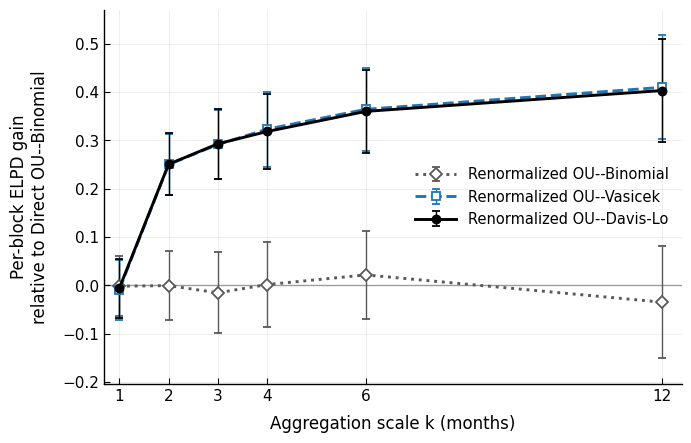

Saved: figures/fig6b_renorm_models_per_block_elpd_vs_direct_ou_binomial.png
Saved: figures/fig6b_renorm_models_per_block_elpd_vs_direct_ou_binomial.pdf
Saved: pdata/renorm_models_per_block_elpd_vs_direct_ou_binomial.csv


In [24]:
# ============================================================
# Direct OU--Binomial baseline = 0
# Plot per-block ELPD gain of Renormalized models
#
# Error bars:
#   approximate standard errors of WAIC-based per-block ELPD
#   differences.
#
# Output image file names are unchanged.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = PDATA_DIR
FIG_DIR = Path("./figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
# Prefer the SE-augmented table if it has already been created.
# Otherwise, construct the required SE columns here.
if "df_renorm_vs_direct_binomial_with_se" in globals():
    df_plot = df_renorm_vs_direct_binomial_with_se.copy()
else:
    # --------------------------------------------------------
    # Fallback construction from already-computed WAIC tables
    # --------------------------------------------------------

    def _ensure_elpd_and_se_columns(df):
        d = df.copy()

        if "elpd_waic" not in d.columns:
            if "waic" not in d.columns:
                raise ValueError("Neither elpd_waic nor waic is found.")
            d["elpd_waic"] = -0.5 * d["waic"]

        if "elpd_waic_se" not in d.columns:
            if "waic_se" in d.columns:
                d["elpd_waic_se"] = 0.5 * d["waic_se"]
            else:
                d["elpd_waic_se"] = np.nan

        if "T" not in d.columns:
            block_count_by_k = {1: len(df_m1)}
            block_count_by_k.update({
                int(k): len(block_data_by_k[int(k)])
                for k in K_LIST_COARSE
            })
            d["T"] = d["k_month"].map(block_count_by_k)

        return d

    df_renorm = _ensure_elpd_and_se_columns(df_waic_renorm_modelpath)
    df_direct = _ensure_elpd_and_se_columns(df_waic_k)

    df_direct_binomial_base = (
        df_direct[df_direct["model"] == "binomial"]
        [["k_month", "elpd_waic", "elpd_waic_se"]]
        .rename(columns={
            "elpd_waic": "elpd_waic_direct_binomial",
            "elpd_waic_se": "elpd_waic_se_direct_binomial",
        })
    )

    df_plot = df_renorm.merge(
        df_direct_binomial_base,
        on="k_month",
        how="left",
    )

    df_plot["delta_elpd_vs_direct_binomial"] = (
        df_plot["elpd_waic"]
        - df_plot["elpd_waic_direct_binomial"]
    )

    df_plot["delta_elpd_vs_direct_binomial_se"] = np.sqrt(
        df_plot["elpd_waic_se"]**2
        + df_plot["elpd_waic_se_direct_binomial"]**2
    )

    df_plot["delta_elpd_per_block_vs_direct_binomial"] = (
        df_plot["delta_elpd_vs_direct_binomial"] / df_plot["T"]
    )

    df_plot["delta_elpd_per_block_vs_direct_binomial_se"] = (
        df_plot["delta_elpd_vs_direct_binomial_se"] / df_plot["T"]
    )

# ------------------------------------------------------------
# Model labels
# ------------------------------------------------------------
renorm_model_map = {
    "renorm_modelpath_binomial": "Renormalized OU--Binomial",
    "renorm_modelpath_vasicek": "Renormalized OU--Vasicek",
    "renorm_modelpath_davis_lo": "Renormalized OU--Davis-Lo",
}

df_plot["model_label"] = df_plot["model"].map(renorm_model_map)

df_plot = df_plot[
    df_plot["model_label"].notna()
].copy()

# ------------------------------------------------------------
# Backward-compatible aliases
# ------------------------------------------------------------
# The original cell used the name:
#   delta_elpd_per_block_vs_direct_ou_binomial
# We keep it for display / CSV compatibility.
df_plot["delta_elpd_vs_direct_ou_binomial"] = (
    df_plot["delta_elpd_vs_direct_binomial"]
)

df_plot["delta_elpd_vs_direct_ou_binomial_se"] = (
    df_plot["delta_elpd_vs_direct_binomial_se"]
)

df_plot["delta_elpd_per_block_vs_direct_ou_binomial"] = (
    df_plot["delta_elpd_per_block_vs_direct_binomial"]
)

df_plot["delta_elpd_per_block_vs_direct_ou_binomial_se"] = (
    df_plot["delta_elpd_per_block_vs_direct_binomial_se"]
)

# ------------------------------------------------------------
# Display and save table
# ------------------------------------------------------------
display_cols = [
    "k_month",
    "T",
    "model",
    "model_label",
    "elpd_waic",
    "elpd_waic_direct_binomial",
    "delta_elpd_vs_direct_ou_binomial",
    "delta_elpd_vs_direct_ou_binomial_se",
    "delta_elpd_per_block_vs_direct_ou_binomial",
    "delta_elpd_per_block_vs_direct_ou_binomial_se",
]

display_cols = [c for c in display_cols if c in df_plot.columns]

display(
    df_plot[display_cols]
    .sort_values(["model", "k_month"])
)

# Output CSV file name unchanged
pass  # Intermediate CSV/LaTeX output suppressed for public minimal version.

# ------------------------------------------------------------
# Plot settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2.5,
    "ytick.minor.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

MODEL_LIST_PLOT = [
    "renorm_modelpath_binomial",
    "renorm_modelpath_vasicek",
    "renorm_modelpath_davis_lo",
]

model_styles = {
    "renorm_modelpath_binomial": {
        "label": "Renormalized OU--Binomial",
        "color": "0.35",
        "linestyle": ":",
        "marker": "D",
        "markerfacecolor": "white",
    },
    "renorm_modelpath_vasicek": {
        "label": "Renormalized OU--Vasicek",
        "color": "#1f77b4",
        "linestyle": "--",
        "marker": "s",
        "markerfacecolor": "white",
    },
    "renorm_modelpath_davis_lo": {
        "label": "Renormalized OU--Davis-Lo",
        "color": "black",
        "linestyle": "-",
        "marker": "o",
        "markerfacecolor": "black",
    },
}

# ------------------------------------------------------------
# Figure
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7.4, 4.8))

for model_name in MODEL_LIST_PLOT:

    g = (
        df_plot[df_plot["model"] == model_name]
        .sort_values("k_month")
        .copy()
    )

    if len(g) == 0:
        continue

    st = model_styles[model_name]

    ax.errorbar(
        g["k_month"],
        g["delta_elpd_per_block_vs_direct_ou_binomial"],
        yerr=g["delta_elpd_per_block_vs_direct_ou_binomial_se"],
        marker=st["marker"],
        markersize=5.8,
        markerfacecolor=st["markerfacecolor"],
        markeredgecolor=st["color"],
        markeredgewidth=1.3,
        linestyle=st["linestyle"],
        linewidth=2.1,
        color=st["color"],
        ecolor=st["color"],
        elinewidth=1.0,
        capsize=3.0,
        capthick=1.0,
        label=st["label"],
        zorder=3,
    )

# ------------------------------------------------------------
# Baseline line
# ------------------------------------------------------------
ax.axhline(
    0.0,
    linestyle="-",
    linewidth=1.0,
    color="0.6",
    zorder=0,
)

# ------------------------------------------------------------
# Axes
# ------------------------------------------------------------
ax.set_xlabel("Aggregation scale k (months)", labelpad=8)
ax.set_ylabel(
    "Per-block ELPD gain\nrelative to Direct OU--Binomial",
    labelpad=10,
)

xticks_use = sorted(df_plot["k_month"].unique())
ax.set_xticks(xticks_use)
ax.set_xlim(min(xticks_use) - 0.3, max(xticks_use) + 0.4)

# Include error bars in y-range
y_center = df_plot["delta_elpd_per_block_vs_direct_ou_binomial"]
y_err = df_plot["delta_elpd_per_block_vs_direct_ou_binomial_se"]

y_low = (y_center - y_err).dropna()
y_high = (y_center + y_err).dropna()

if len(y_low) > 0 and len(y_high) > 0:
    y_min = min(0.0, float(y_low.min()))
    y_max = max(0.0, float(y_high.max()))
else:
    y_vals = y_center.dropna()
    y_min = min(0.0, float(y_vals.min()))
    y_max = max(0.0, float(y_vals.max()))

pad = 0.08 * (y_max - y_min) if y_max > y_min else 0.05
ax.set_ylim(y_min - pad, y_max + pad)

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.grid(True, which="minor", linewidth=0.4, alpha=0.12)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    loc="best",
    handlelength=2.8,
)

fig.subplots_adjust(
    left=0.20,
    right=0.98,
    bottom=0.18,
    top=0.96,
)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------
# Output image file names unchanged
fig_path_png = FIG_DIR / "fig6b_renorm_models_per_block_elpd_vs_direct_ou_binomial.png"
fig_path_pdf = FIG_DIR / "fig6b_renorm_models_per_block_elpd_vs_direct_ou_binomial.pdf"

fig.savefig(fig_path_png, dpi=300)
fig.savefig(fig_path_pdf)

plt.show()

print("Saved:", fig_path_png)
print("Saved:", fig_path_pdf)
print("Saved:", OUT_DIR / "renorm_models_per_block_elpd_vs_direct_ou_binomial.csv")